In [148]:
# ── Alertas sonoras ─────────────────────────────────────────────────────────
import winsound, os, time

# Archivos WAV del sistema Windows (siempre presentes en Windows 10/11)
_WAV_OK  = r'C:\Windows\Media\ding.wav'
_WAV_ERR = r'C:\Windows\Media\chord.wav'

def beep(exito=True):
    try:
        wav = _WAV_OK if exito else _WAV_ERR
        repeticiones = 3 if exito else 5
        for _ in range(repeticiones):
            winsound.PlaySound(wav, winsound.SND_FILENAME)
            time.sleep(0.4)  # pausa para que el sistema de audio resetee el volumen
    except Exception:
        pass  # Colab / Linux: no hace nada

print('beep() listo. Probando sonidos...')
print('  -> Exito (3x ding):')
beep(exito=True)
time.sleep(0.5)
print('  -> Error (5x chord):')
beep(exito=False)
print('Hecho.')


beep() listo. Probando sonidos...
  -> Exito (3x ding):
  -> Error (5x chord):
Hecho.


In [149]:
from IPython.display import HTML

HTML("""
<style>
h1, h2, h3 {
    font-family: Arial, sans-serif;
}
code {
    font-size: 13px;
}
.output_area {
    font-size: 12px;
}
</style>
""")

"Caracola"

'Caracola'

In [150]:
# ═══════════════════════════════════════════════════════════════════════
# ⚙️  CONFIGURACIÓN — única celda que necesitas modificar
# ═══════════════════════════════════════════════════════════════════════
#
# Coloca los archivos de datos en una carpeta y ajusta DATA_DIR.
# Si usas Google Colab con Drive, no hace falta cambiar nada.
#
# Opción A (recomendada para local): crea una carpeta 'data/' junto al
#   notebook y coloca ahí todos los archivos → DATA_DIR = Path.cwd()/'data'
#
# Opción B: ruta personalizada, por ejemplo:
#   DATA_DIR = Path(r'C:\ruta\a\tus\datos')
# ═══════════════════════════════════════════════════════════════════════
from pathlib import Path

# ── Detectar entorno automáticamente ────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    DATA_DIR = Path('/content/drive/MyDrive/SISTEMAS INTERACTIVOS INTELIGENTES/TFMdrive/data')
    WORKDIR  = Path('/content/tfm_data')
    OUTDIR   = Path('/content/tfm_output')
else:
    # ── LOCAL (VS Code / Jupyter) ────────────────────────────────────────
    DATA_DIR = Path.cwd() / 'data'          # Opción A: carpeta data/ junto al notebook
    # DATA_DIR = Path(r'C:\ruta\a\tus\datos')  # Opción B: ruta personalizada
    WORKDIR  = Path.cwd() / 'tfm_data'
    OUTDIR   = Path.cwd() / 'tfm_output'

WORKDIR.mkdir(exist_ok=True)
OUTDIR.mkdir(exist_ok=True)

print(f'Entorno : {"Google Colab" if IN_COLAB else "Local (VS Code / Jupyter)"}')
print(f'Datos   : {DATA_DIR}')
print(f'Trabajo : {WORKDIR}')
print(f'Salida  : {OUTDIR}')
if not IN_COLAB and not DATA_DIR.exists():
    print(f'\n⚠️  La carpeta de datos no existe: {DATA_DIR}')
    print('   Crea la carpeta y coloca ahí los archivos antes de continuar.')


Entorno : Local (VS Code / Jupyter)
Datos   : c:\Users\sergi\OneDrive\Escritorio\TFMgithub\data
Trabajo : c:\Users\sergi\OneDrive\Escritorio\TFMgithub\tfm_data
Salida  : c:\Users\sergi\OneDrive\Escritorio\TFMgithub\tfm_output


## MÓDULO 0 — Instalación y configuración del entorno

En este módulo se instalan todas las librerías necesarias y se configuran los
parámetros globales del notebook. **Ejecutar una sola vez al inicio de la sesión.**

### 📦 0.1 — Instalación de dependencias

Se instalan las librerías especializadas que no vienen por defecto en Colab:
- **biopython**: lectura y manipulación de secuencias genéticas (FASTA)
- **xgboost / lightgbm**: modelos de gradient boosting para clasificación
- **shap**: interpretabilidad del modelo (valores de Shapley)
- **pyarrow**: lectura/escritura eficiente de archivos Parquet (alternativa a CSV)
- **prophet**: modelado de series temporales (tendencias virales)
- **mafft**: alineamiento múltiple de secuencias (instalado en el sistema)

In [151]:
# ---------------------------------------------------------------------------
# Celda 0.1 — Instalación de librerías
# ---------------------------------------------------------------------------
# Usamos %pip (no !pip) para garantizar que se instala en el kernel activo.
%pip install -q biopython pandas numpy matplotlib seaborn scipy scikit-learn \
               xgboost lightgbm openpyxl tqdm joblib plotly pyarrow shap
print('✅ Librerías instaladas correctamente')


Note: you may need to restart the kernel to use updated packages.
✅ Librerías instaladas correctamente



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 📚 0.2 — Importaciones

Se importan todos los módulos necesarios agrupados por categoría:
- **Sistema y utilidades**: os, re, gc, zipfile, io, warnings
- **Datos**: numpy, pandas
- **Visualización**: matplotlib, seaborn, plotly
- **Bioinformática**: BioPython (SeqIO)
- **Machine Learning**: scikit-learn, XGBoost, SHAP

In [152]:
# ---------------------------------------------------------------------------
# Celda 0.2 — Importaciones
# ---------------------------------------------------------------------------
import os, sys, re, gc, zipfile, io, warnings, time
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from Bio import SeqIO
from Bio.Seq import Seq

from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                             confusion_matrix, precision_recall_curve)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import xgboost as xgb
import shap
import pyarrow as pa
import pyarrow.parquet as pq
from IPython.display import display, HTML, clear_output
from tqdm.notebook import tqdm

import lightgbm as lgb

warnings.filterwarnings('ignore')
print('✅ Importaciones completadas')

✅ Importaciones completadas


### ⚙️ 0.3 — Configuración global

Se definen los parámetros visuales y las rutas de trabajo:
- **Estilo de gráficos**: fondo blanco, paleta de colores armónica
- **WORKDIR**: carpeta temporal de trabajo en Colab
- **OUTDIR**: carpeta de salida para figuras y resultados exportables

In [153]:
# ---------------------------------------------------------------------------
# Celda 0.3 — Configuración global de visualización
# ---------------------------------------------------------------------------
# WORKDIR, OUTDIR y DATA_DIR ya están definidos en la celda de configuración.
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams.update({
    'figure.dpi'      : 120,
    'figure.facecolor': 'white',
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'xtick.labelsize' : 9,
    'ytick.labelsize' : 9,
})

PATHS = {}  # diccionario global de rutas — se completa en Módulo 1

print(f'✅ Configuración global aplicada')
print(f'   Directorio de trabajo : {WORKDIR}')
print(f'   Directorio de salida  : {OUTDIR}')


✅ Configuración global aplicada
   Directorio de trabajo : c:\Users\sergi\OneDrive\Escritorio\TFMgithub\tfm_data
   Directorio de salida  : c:\Users\sergi\OneDrive\Escritorio\TFMgithub\tfm_output


### 📚 0.4 — Librerías clave del proyecto

| Librería | Función en el TFM |
|----------|-------------------|
| `pandas` | Manejo de datos tabulares y series temporales |
| `numpy` | Operaciones numéricas vectorizadas |
| `lightgbm` | Modelo predictivo basado en gradient boosting de árboles |
| `shap` | Interpretabilidad del modelo (valores de Shapley) |
| `matplotlib` / `seaborn` | Visualizaciones científicas |
| `sklearn` | Métricas de evaluación (AUC-ROC, PR-AUC, F1) |
| `zipfile` | Lectura de GISAID (~5 GB) sin descomprimir en disco |
| `gc` | Gestión explícita de memoria para procesamiento masivo |

**Dependencias externas**: los datos de GISAID requieren registro en [gisaid.org](https://gisaid.org).
El Excel UDS es de generación propia (28 pacientes, Hospital X, 2020-2023).


In [154]:
# ---------------------------------------------------------------------------
# Celda 0.5 — Mapa Nextclade -> nombre comun y funciones utilitarias
# ---------------------------------------------------------------------------
import pandas as pd

NEXTCLADE_ALIAS_MAP = {
    "19A":"Original Wuhan","19B":"Original Wuhan",
    "20A":"B.1 / D614G","20B":"B.1 / D614G","20C":"B.1 / D614G","20D":"B.1 / D614G",
    "20E":"B.1.177 (Europa)","20F":"B.1 / D614G","20G":"B.1 / D614G",
    "20H":"Beta (B.1.351)","20I":"Alpha (B.1.1.7)","20J":"Gamma (P.1)",
    "21A":"Delta (B.1.617.2)","21B":"Kappa (B.1.617.1)","21C":"Epsilon (B.1.427)",
    "21D":"Eta (B.1.525)","21F":"Iota (B.1.526)","21G":"Lambda (C.37)",
    "21H":"Mu (B.1.621)","21I":"Delta AY.1/AY.2","21J":"Delta AY (global)",
    "21K":"Omicron BA.1","21L":"Omicron BA.1/BA.2",
    "22A":"BA.4","22B":"BA.5","22C":"BA.2.12.1","22D":"BA.2.13",
    "22E":"BQ.1","22F":"XBB",
    "23A":"XBB.1.5","23B":"XBB.1.16","23C":"CH.1.1","23D":"XBB.1.9",
    "23E":"XBB.2.3","23F":"EG.5.1","23G":"XBB.1.5.70","23H":"HK.3","23I":"BA.2.86",
    "24A":"JN.1","24B":"JN.1.11.1","24C":"KP.1.1","24D":"KP.3.1.1",
    "24E":"XDV.1","24F":"LP.8.1","24G":"XEC",
    "25A":"MC.1","25B":"NP.1","25C":"XFG",
}

def extract_lineage_family(clade):
    """Extrae la familia raiz de un clado (prefijo hasta el primer punto).

    Ejemplos: XFG.2.3.1 -> XFG  |  JN.1.16.1 -> JN  |  BA.2.86 -> BA

    Args:
        clade: string con el clado completo (puede ser NaN o vacio)
    Returns:
        Prefijo raiz (str) o 'Unknown' si el valor es invalido
    """
    if pd.isna(clade) or str(clade).strip() == '':
        return 'Unknown'
    return str(clade).split('.')[0]

def assign_pandemic_epoch(date_input, epochs=None):
    """Asigna la epoca pandemica correspondiente a una fecha.

    En caso de solapamiento entre epocas usa la epoca cuyo end sea posterior.

    Args:
        date_input: fecha como string YYYY-MM-DD, Timestamp o Period
        epochs: diccionario PANDEMIC_EPOCHS (usa global si None)
    Returns:
        Nombre de la epoca (str) o 'Unknown' si no hay coincidencia
    """
    if epochs is None:
        epochs = PANDEMIC_EPOCHS
    try:
        if hasattr(date_input, 'to_timestamp'):
            date = date_input.to_timestamp()
        else:
            date = pd.to_datetime(date_input)
    except Exception:
        return 'Unknown'
    best_match, best_end = 'Unknown', pd.Timestamp.min
    for epoch_name, ep in epochs.items():
        start = pd.to_datetime(ep['start'])
        end   = pd.to_datetime(ep['end'])
        if start <= date <= end and end > best_end:
            best_match, best_end = epoch_name, end
    return best_match

print("Funciones utilitarias cargadas:")
print("  extract_lineage_family('XFG.2.3.1') =", extract_lineage_family('XFG.2.3.1'))
print("  extract_lineage_family('JN.1.16.1') =", extract_lineage_family('JN.1.16.1'))
print(f"  NEXTCLADE_ALIAS_MAP: {len(NEXTCLADE_ALIAS_MAP)} entradas")

# Mapa alias Nextclade -> familia Pango primaria (para display dual en rankings y graficas)
ALIAS_TO_FAMILY = {
    '19A': 'B',   '19B': 'A',
    '20A': 'B',   '20B': 'B',   '20C': 'B',   '20D': 'B',
    '20E': 'B',   '20F': 'B',   '20G': 'B',
    '20H': 'B',   '20I': 'B',   '20J': 'P',
    '21A': 'B',   '21B': 'B',   '21C': 'B',   '21D': 'B',
    '21F': 'B',   '21G': 'C',   '21H': 'B',
    '21I': 'AY',  '21J': 'AY',
    '21K': 'BA',  '21L': 'BA',
    '22A': 'BA',  '22B': 'BA',  '22C': 'BA',  '22D': 'BA',
    '22E': 'BQ',  '22F': 'XBB',
    '23A': 'XBB', '23B': 'XBB', '23C': 'CH',  '23D': 'XBB',
    '23E': 'XBB', '23F': 'EG',  '23G': 'XBB', '23H': 'HK',
    '23I': 'BA',
    '24A': 'JN',  '24B': 'JN',  '24C': 'KP',  '24D': 'KP',
    '24E': 'XDV', '24F': 'LP',  '24G': 'XEC',
    '25A': 'MC',  '25B': 'NP',  '25C': 'XFG',
}
# Inverso: familia -> alias Nextclade mas reciente/representativo
FAMILY_TO_ALIAS_STATIC = {}
for _al, _fm in list(ALIAS_TO_FAMILY.items()):
    FAMILY_TO_ALIAS_STATIC[_fm] = _al   # la ultima entrada (mas reciente) gana
# Forzar alias canonico (primer alias = mas representativo) para familias multi-alias
FAMILY_TO_ALIAS_STATIC.update({
    'JN': '24A', 'KP': '24C', 'BA': '21K', 'XBB': '22F',
    'B': '20I',  'AY': '21J', 'BQ': '22E', 'EG': '23F',
    'HK': '23H', 'CH': '23C',
})


Funciones utilitarias cargadas:
  extract_lineage_family('XFG.2.3.1') = XFG
  extract_lineage_family('JN.1.16.1') = JN
  NEXTCLADE_ALIAS_MAP: 48 entradas


In [155]:
# ---------------------------------------------------------------------------
# Celda 0.6 — Épocas pandémicas de SARS-CoV-2 (PANDEMIC_EPOCHS)
# ---------------------------------------------------------------------------
PANDEMIC_EPOCHS = {
    "Pre-VOC": {
        "start":"2020-01-01","end":"2020-11-30",
        "dominant_clade_nextclade":["19A","19B","20A","20B","20C","20D","20E","20F","20G"],
        "dominant_pango":["B","B.1","B.1.1","B.1.177"],
        "who_label":"Original / D614G","color":"#808080",
        "description":"Virus original de Wuhan y primeras variantes con D614G (Jun 2020). Baja presion inmune, evolucion lenta.",
        "key_mutations":["D614G"],"category":"Pre-VOC",
    },
    "Alpha_era": {
        "start":"2020-12-01","end":"2021-05-31",
        "dominant_clade_nextclade":["20I","20H","20J"],
        "dominant_pango":["B.1.1.7","B.1.351","P.1"],
        "who_label":"Alpha / Beta / Gamma","color":"#FF6B6B",
        "description":"Alpha (B.1.1.7, UK, Nov 2020): primer VOC, +50% transmisibilidad. Beta (B.1.351): evasion inmune. Gamma (P.1, Brasil): reinfecciones. VOIs co-circulantes nunca dominantes: Epsilon, Eta, Iota, Kappa, Theta, Zeta.",
        "key_mutations":["N501Y","E484K","K417N","K417T","P681H","D614G"],"category":"VOC",
    },
    "Delta_era": {
        "start":"2021-05-01","end":"2021-11-30",
        "dominant_clade_nextclade":["21A","21I","21J"],
        "dominant_pango":["B.1.617.2","AY.1","AY.2","AY.3","AY.4"],
        "who_label":"Delta","color":"#FF4500",
        "description":"Delta (B.1.617.2, India): primer VOC que desplazo globalmente a todos los anteriores. >90% global Jun-Nov 2021. +60% transmisibilidad vs Alpha. VOIs: Lambda (C.37, Peru), Mu (B.1.621, Colombia), ambas extintas antes de Omicron.",
        "key_mutations":["L452R","T478K","P681R","D614G"],"category":"VOC",
    },
    "Omicron_BA1_BA2": {
        "start":"2021-11-01","end":"2022-06-30",
        "dominant_clade_nextclade":["21K","21L","22A","22B","22C","22D"],
        "dominant_pango":["B.1.1.529","BA.1","BA.2","BA.2.12.1"],
        "who_label":"Omicron BA.1 / BA.2","color":"#9B59B6",
        "description":"Mayor salto evolutivo: >30 mutaciones en Spike. BA.1 domino Dic2021-Feb2022. BA.2 reemplazo BA.1 en Mar2022. BA.2.12.1 domino EEUU May-Jun2022. Toda la inmunidad pre-Omicron quedo parcialmente obsoleta.",
        "key_mutations":["G339D","S371L","N440K","G446S","S477N","T478K","E484A","Q493R","N501Y","P681H"],"category":"VOC_Omicron",
    },
    "Omicron_BA4_BA5": {
        "start":"2022-06-01","end":"2022-12-31",
        "dominant_clade_nextclade":["22A","22B","22E"],
        "dominant_pango":["BA.4","BA.5","BQ.1","BQ.1.1"],
        "who_label":"Omicron BA.4 / BA.5 / BQ.1","color":"#3498DB",
        "description":"BA.4 y BA.5 desplazaron BA.2 en Jul2022 (L452R de vuelta). BQ.1.1 llego al 52% global Dic2022. Primer ciclo de ola dentro de Omicron.",
        "key_mutations":["L452R","F486V","R346T","K444T"],"category":"VOC_Omicron",
    },
    "XBB_era": {
        "start":"2022-12-01","end":"2023-09-30",
        "dominant_clade_nextclade":["22F","23A","23B","23C","23D","23E","23F","23G","23H"],
        "dominant_pango":["XBB","XBB.1.5","XBB.1.9","XBB.1.16","XBB.2.3","EG.5.1","HK.3"],
        "who_label":"XBB / EG.5","color":"#1ABC9C",
        "description":"XBB: recombinante BA.2.10.1 x BA.2.75. XBB.1.5 (Kraken) domino EEUU/Europa. XBB.1.16 (Arcturus) domino globalmente. EG.5.1 (Eris) domino Jun-Sep2023. Era de alta diversidad: 7 sublinajes co-dominantes.",
        "key_mutations":["G252V","F486P","F456L","L455F","R346T"],"category":"VOC_Omicron",
    },
    "JN1_era": {
        "start":"2023-09-01","end":"2024-07-31",
        "dominant_clade_nextclade":["23I","24A","24B","24C","24D"],
        "dominant_pango":["BA.2.86","JN.1","JN.1.11.1","KP.1.1","KP.2","KP.3","KP.3.1.1"],
        "who_label":"JN.1 / KP.3","color":"#E67E22",
        "description":"BA.2.86 emergio Sep2023 con >30 mutaciones adicionales vs XBB (segundo gran salto). JN.1 domino globalmente Dic2023-Mar2024 con 96% en pico. KP.2 y KP.3 (JN.1 + F456L) dominaron Jun-Jul2024.",
        "key_mutations":["L455S","F456L","R346T","N440K"],"category":"VOC_Omicron",
    },
    "KP_XEC_era": {
        "start":"2024-07-01","end":"2025-06-30",
        "dominant_clade_nextclade":["24D","24E","24F","24G","25A","25B"],
        "dominant_pango":["KP.3.1.1","XDV.1","LP.8.1","XEC","MC.1","NP.1"],
        "who_label":"KP.3 / XEC / LP.8","color":"#E74C3C",
        "description":"Alta diversificacion post-JN.1. XEC (recombinante KP.3.1.1 x KS.1.1) domino Oct-Nov2024. LP.8.1 emergio como VOI OMS. XDV.1 gano presencia desde 2025. Olas mas cortas (~3 meses).",
        "key_mutations":["S31del","A475V","V1104L","T22N"],"category":"VOC_Omicron",
    },
    "XFG_era": {
        "start":"2025-06-01","end":"2026-12-31",
        "dominant_clade_nextclade":["25B","25C"],
        "dominant_pango":["XFG","XFG.2","XFG.6","XDV.1.5"],
        "who_label":"XFG / XDV","color":"#27AE60",
        "description":"XFG es la familia dominante a nivel global desde mid-2025 (~70% Abr2026). XDV segunda familia (~16.4% global Abr2026). Era actual: la validacion prospectiva confirma que el modelo predijo estas familias.",
        "key_mutations":["G252V","L216F","P1143L"],"category":"Current",
    },
}

print(f"Epocas pandemicas cargadas: {len(PANDEMIC_EPOCHS)}")
for name, ep in PANDEMIC_EPOCHS.items():
    print(f"  {name:20s}: {ep['start']} -> {ep['end']}  [{ep['who_label']}]")

# Verificacion rapida de assign_pandemic_epoch
print("  assign_pandemic_epoch('2024-01-15') =", assign_pandemic_epoch('2024-01-15'))


Epocas pandemicas cargadas: 9
  Pre-VOC             : 2020-01-01 -> 2020-11-30  [Original / D614G]
  Alpha_era           : 2020-12-01 -> 2021-05-31  [Alpha / Beta / Gamma]
  Delta_era           : 2021-05-01 -> 2021-11-30  [Delta]
  Omicron_BA1_BA2     : 2021-11-01 -> 2022-06-30  [Omicron BA.1 / BA.2]
  Omicron_BA4_BA5     : 2022-06-01 -> 2022-12-31  [Omicron BA.4 / BA.5 / BQ.1]
  XBB_era             : 2022-12-01 -> 2023-09-30  [XBB / EG.5]
  JN1_era             : 2023-09-01 -> 2024-07-31  [JN.1 / KP.3]
  KP_XEC_era          : 2024-07-01 -> 2025-06-30  [KP.3 / XEC / LP.8]
  XFG_era             : 2025-06-01 -> 2026-12-31  [XFG / XDV]
  assign_pandemic_epoch('2024-01-15') = JN1_era


## MÓDULO 1 — Montaje de Google Drive y verificación de archivos

Se conecta el entorno de ejecución con el almacenamiento en Drive donde residen
todos los datos del proyecto. Se verifica que cada archivo esté disponible antes
de continuar, evitando errores tardíos en módulos posteriores.

### ☁️ 1.1 — Montaje de Google Drive

Colab necesita autorización explícita para acceder a Drive. Al ejecutar esta
celda aparecerá una ventana para autenticarse con la cuenta de Google.

In [156]:
# ---------------------------------------------------------------------------
# Celda 1.1 — Entorno
# ---------------------------------------------------------------------------
# El montaje de Drive (si aplica) ya se realizó en la celda de configuración.
print(f'✅ Entorno: {"Google Colab" if IN_COLAB else "Local"} — datos en: {DATA_DIR}')


✅ Entorno: Local — datos en: c:\Users\sergi\OneDrive\Escritorio\TFMgithub\data


### 📁 1.2 — Definición de rutas de los archivos de datos

Se define la ruta base donde se almacenan todos los datos del proyecto en Drive,
y se construye un diccionario con la ruta completa de cada archivo.

> ⚠️ Si los archivos están en una carpeta distinta, modifica `DATA_DIR`

In [157]:
# ---------------------------------------------------------------------------
# Celda 1.2 — Definición de rutas de archivos
# ---------------------------------------------------------------------------
# DATA_DIR, WORKDIR y OUTDIR vienen de la celda de configuración inicial.

FILE_MAP = {
    'excel_haplotipos': 'Haplotipos discordantes de clado_25.02.2026.xlsx',
    'fasta_ref'       : 'COVIDSeq_ALL_pos51-29816.fas',
    'zip_amplicones'  : 'FASTAS de amplicones.zip',
    'zip_olas'        : 'Fastas_ComparativaOlas.zip',
    'zip_consensos'   : 'Secuencias consenso clados CovSpectrum.zip',
    'gisaid_nsp12'    : 'GISAID_NSP12_sequences_2026_02_22.zip',
    'gisaid_spike'    : 'GISAID_Spike_sequences_2026_02_22.zip',
    'gisaid_metadata' : 'GISAID_metadata_2026_02_22.zip',
}

PATHS = {key: DATA_DIR / fname for key, fname in FILE_MAP.items()}
print(f'✅ Rutas definidas. Directorio base: {DATA_DIR}')


✅ Rutas definidas. Directorio base: c:\Users\sergi\OneDrive\Escritorio\TFMgithub\data


### ✅ 1.3 — Verificación de disponibilidad

Se comprueba que cada archivo exista en Drive y se muestra su tamaño.
Si alguno aparece con ❌, revisar el nombre exacto y la ruta en Drive antes
de continuar — los módulos posteriores fallarán si falta algún archivo.

In [158]:
# ---------------------------------------------------------------------------
# Celda 1.3 — Verificación de archivos
# ---------------------------------------------------------------------------
print('Verificando archivos en Drive...\n')
all_ok = True
for key, path in PATHS.items():
    if path.exists():
        size = path.stat().st_size
        size_str = f'{size/1e9:.2f} GB' if size > 1e8 else f'{size/1e6:.1f} MB'
        print(f'  ✅  {path.name:<60s}  ({size_str})')
    else:
        print(f'  ❌  {path.name:<60s}  ← NO ENCONTRADO')
        all_ok = False

print()
if all_ok:
    print('✅ Todos los archivos verificados. Puedes continuar con el análisis.')
else:
    print('⚠️  Faltan archivos. Revisa los nombres en Drive antes de continuar.')

Verificando archivos en Drive...

  ✅  Haplotipos discordantes de clado_25.02.2026.xlsx              (0.0 MB)
  ✅  COVIDSeq_ALL_pos51-29816.fas                                  (1.9 MB)
  ✅  FASTAS de amplicones.zip                                      (0.1 MB)
  ✅  Fastas_ComparativaOlas.zip                                    (0.1 MB)
  ✅  Secuencias consenso clados CovSpectrum.zip                    (0.0 MB)
  ✅  GISAID_NSP12_sequences_2026_02_22.zip                         (1.22 GB)
  ✅  GISAID_Spike_sequences_2026_02_22.zip                         (2.37 GB)
  ✅  GISAID_metadata_2026_02_22.zip                                (1.96 GB)

✅ Todos los archivos verificados. Puedes continuar con el análisis.


### 🔍 1.4 — Inspección de ZIPs (estructura interna)

Se listan los archivos contenidos en cada ZIP para verificar su estructura.
Esto es útil para confirmar que los FASTAs están correctamente empaquetados
y los nombres son los esperados por los módulos de procesamiento.

In [159]:
# ---------------------------------------------------------------------------
# Celda 1.4 — Inspección de contenido de los ZIPs
# ---------------------------------------------------------------------------
zips_to_inspect = [
    ('zip_amplicones', 'FASTAS de amplicones'),
    ('zip_olas',       'Fastas ComparativaOlas'),
    ('zip_consensos',  'Secuencias consenso por clado'),
]

for key, label in zips_to_inspect:
    print(f'\n{"─"*60}')
    print(f'📦 {label}')
    print('─'*60)
    try:
        with zipfile.ZipFile(PATHS[key], 'r') as z:
            entries = sorted(z.namelist())
            for name in entries:
                info = z.getinfo(name)
                size_str = f'{info.file_size/1e6:.1f} MB' if info.file_size > 0 else '(dir)'
                print(f'  {name:<60s}  {size_str}')
    except Exception as e:
        print(f'  ⚠️  Error al abrir ZIP: {e}')


────────────────────────────────────────────────────────────
📦 FASTAS de amplicones
────────────────────────────────────────────────────────────
  FASTAS de amplicones/                                         (dir)
  FASTAS de amplicones/3a_4a_ola/                               (dir)
  FASTAS de amplicones/3a_4a_ola/Pt454/                         (dir)
  FASTAS de amplicones/3a_4a_ola/Pt454/Pt454_Spike-A1alpha.fastq.gz.fasta  0.0 MB
  FASTAS de amplicones/3a_4a_ola/Pt454/Pt454_Spike-A2alpha.fastq.gz.fasta  0.0 MB
  FASTAS de amplicones/3a_4a_ola/Pt454/Pt454_Spike-A3alpha.fastq.gz.fasta  0.0 MB
  FASTAS de amplicones/3a_4a_ola/Pt454/Pt454_Spike-A4alpha.fastq.gz.fasta  0.0 MB
  FASTAS de amplicones/3a_4a_ola/Pt454/desktop.ini              0.0 MB
  FASTAS de amplicones/3a_4a_ola/Pt455/                         (dir)
  FASTAS de amplicones/3a_4a_ola/Pt455/Pt455_Spike-A1alpha.fastq.gz.fasta  0.0 MB
  FASTAS de amplicones/3a_4a_ola/Pt455/Pt455_Spike-A2alpha.fastq.gz.fasta  0.0 MB
  FASTAS de

### 🔴 1C — Control negativo: VOIs que nunca dominaron globalmente

Antes de entrar en los resultados del modelo, es crucial entender qué hace que una variante
**no** llegue a dominar. Los VOIs (Variants of Interest) son variantes con mutaciones preocupantes
que circularon regionalmente pero fueron **desplazadas** por otras antes de alcanzar dominancia global.

Son el "control negativo" del análisis: una alta frecuencia local ≠ emergencia global inminente.


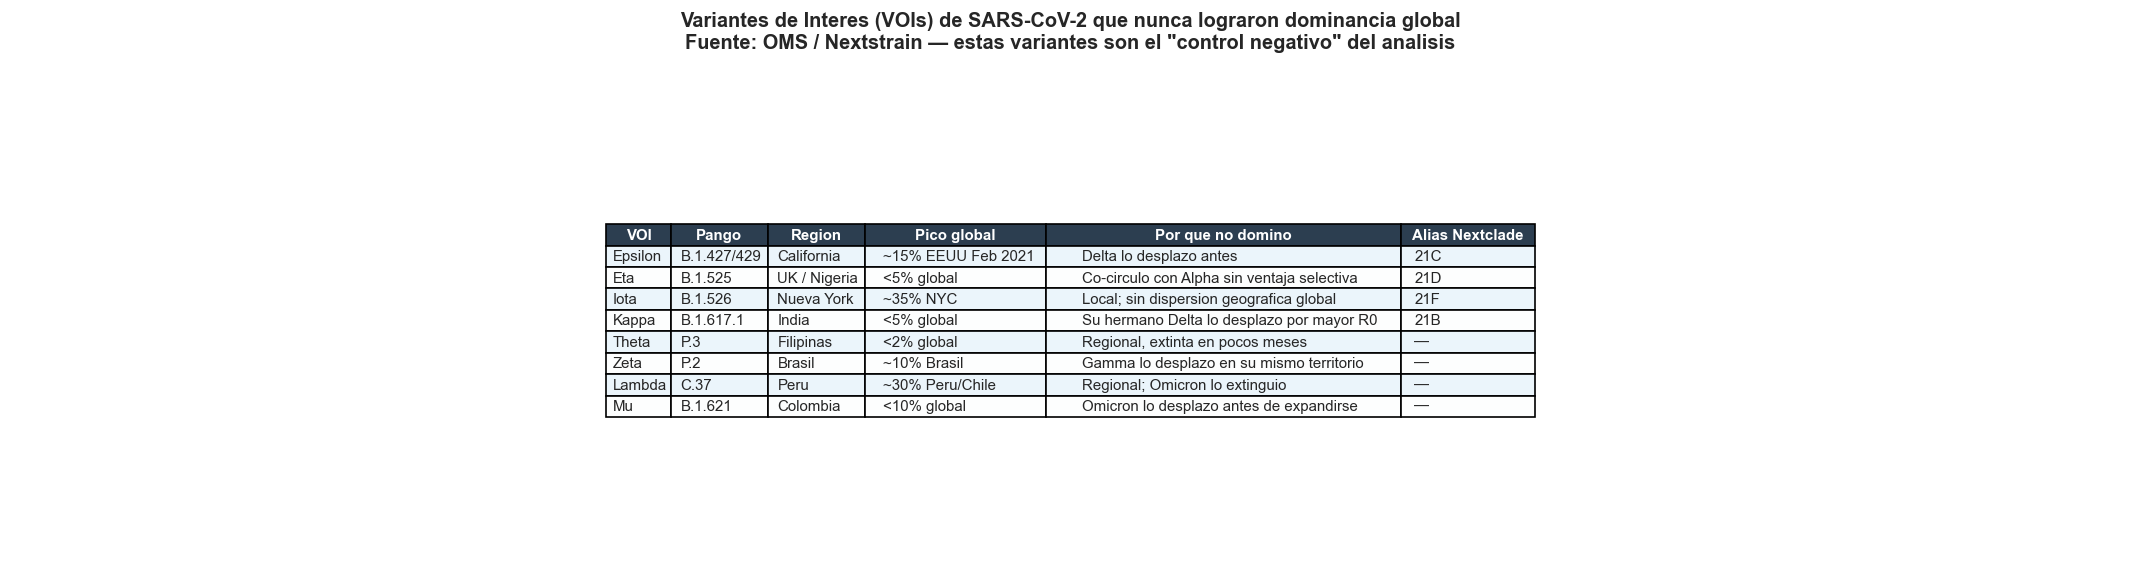

Tabla de 8 VOIs generada. Ningun VOI alcanzo dominancia global.


In [160]:
# ---------------------------------------------------------------------------
# Celda 1C — Tabla visual: VOIs que nunca dominaron (control negativo)
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

vois_data = [
    ["Epsilon", "B.1.427/429", "California",   "~15% EEUU Feb 2021", "Delta lo desplazo antes", "21C"],
    ["Eta",     "B.1.525",     "UK / Nigeria",  "<5% global",         "Co-circulo con Alpha sin ventaja selectiva", "21D"],
    ["Iota",    "B.1.526",     "Nueva York",    "~35% NYC",           "Local; sin dispersion geografica global",    "21F"],
    ["Kappa",   "B.1.617.1",   "India",         "<5% global",         "Su hermano Delta lo desplazo por mayor R0",  "21B"],
    ["Theta",   "P.3",         "Filipinas",     "<2% global",         "Regional, extinta en pocos meses",           "—"],
    ["Zeta",    "P.2",         "Brasil",        "~10% Brasil",        "Gamma lo desplazo en su mismo territorio",   "—"],
    ["Lambda",  "C.37",        "Peru",          "~30% Peru/Chile",    "Regional; Omicron lo extinguio",             "—"],
    ["Mu",      "B.1.621",     "Colombia",      "<10% global",        "Omicron lo desplazo antes de expandirse",    "—"],
]
cols = ["VOI", "Pango", "Region", "Pico global", "Por que no domino", "Alias Nextclade"]

fig, ax = plt.subplots(figsize=(18, 5))
ax.axis('off')
tbl = ax.table(
    cellText=vois_data, colLabels=cols,
    loc='center', cellLoc='left'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.auto_set_column_width(col=list(range(len(cols))))
for j in range(len(cols)):
    tbl[0, j].set_facecolor('#2C3E50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(vois_data)+1):
    bg = '#FDFEFE' if i % 2 == 0 else '#EBF5FB'
    for j in range(len(cols)):
        tbl[i, j].set_facecolor(bg)
ax.set_title('Variantes de Interes (VOIs) de SARS-CoV-2 que nunca lograron dominancia global\n'
             'Fuente: OMS / Nextstrain — estas variantes son el "control negativo" del analisis',
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(OUTDIR / '1_3_vois_control_negativo.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Tabla de {len(vois_data)} VOIs generada. Ningun VOI alcanzo dominancia global.")


### 🌍 1C — Funcion: linea temporal pandemica con epocas coloreadas

Esta figura es el **grafico de portada** del notebook.
La funcion se **define aqui** (para documentacion) y se **llama en Modulo 7**,
una vez que `df_family_time` esta disponible tras procesar el TSV de GISAID.

> **Flujo**: Modulo 0 define `PANDEMIC_EPOCHS` → Modulo 1 define `plot_pandemic_timeline()` →
> Modulo 7 construye `df_family_time` → Modulo 7 llama `plot_pandemic_timeline(df_family_time, ...)` →
> el grafico se guarda como `1C_pandemic_timeline.png`.

Este patron (definicion separada de llamada) permite que la documentacion de la figura
este proxima al contexto biologico (Modulo 1) sin romper el orden de dependencias de datos.


In [161]:
# ---------------------------------------------------------------------------
# Celda 1C — Definicion: plot_pandemic_timeline (se llama en Modulo 7)
# ---------------------------------------------------------------------------

def plot_pandemic_timeline(df_weekly_freq, epochs_dict, train_cutoff_date,
                            predictions_df=None):
    """Visualiza la evolucion de familias de linaje sobre epocas pandemicas coloreadas.

    Args:
        df_weekly_freq:    DataFrame con [week, lineage_family, freq]
        epochs_dict:       diccionario PANDEMIC_EPOCHS
        train_cutoff_date: str YYYY-MM-DD — fecha de corte del modelo
        predictions_df:    (opcional) DataFrame con predicciones futuras
    Returns:
        fig: figura matplotlib
    """
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(22, 8))

    # Franjas de fondo por epoca
    for epoch_name, ep in epochs_dict.items():
        start = pd.to_datetime(ep['start'])
        end   = min(pd.to_datetime(ep['end']), pd.Timestamp.now())
        ax.axvspan(start, end, alpha=0.12, color=ep['color'], zorder=0)
        mid = start + (end - start) / 2
        ax.text(mid, 97, ep['who_label'],
                ha='center', va='top', fontsize=7.5, fontweight='bold',
                color=ep['color'], rotation=0)

    # Curvas de frecuencia (top 10 familias historicas)
    top_fams = (df_weekly_freq
                .groupby('lineage_family')['freq']
                .sum().nlargest(10).index)
    colors_fam = plt.cm.tab10(range(10))
    for i, fam in enumerate(top_fams):
        data = df_weekly_freq[df_weekly_freq['lineage_family'] == fam]
        ax.plot(data['week'], data['freq'] * 100,
                linewidth=1.8, label=fam, color=colors_fam[i])

    # Linea de corte y zona de prediccion
    cutoff = pd.to_datetime(train_cutoff_date)
    ax.axvline(cutoff, color='black', linestyle='--', linewidth=1.8,
               label='Corte entrenamiento')
    ax.axvspan(cutoff, df_weekly_freq['week'].max(),
               alpha=0.05, color='navy', label='Zona prediccion')

    ax.set_xlabel('Fecha', fontsize=12)
    ax.set_ylabel('Frecuencia global (%)', fontsize=12)
    ax.set_title(
        'Evolucion pandemica de SARS-CoV-2: epocas evolutivas y familias de linaje dominantes'
        '\n(2020-2026)',
        fontsize=14, fontweight='bold'
    )
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    ax.set_ylim(0, 100)
    plt.tight_layout()
    plt.savefig(OUTDIR / '1_4_pandemic_timeline.png', dpi=150, bbox_inches='tight')
    plt.show()
    return fig

print("Funcion plot_pandemic_timeline definida.")
print("Se llamara automaticamente en Modulo 7 (celda 7.3b) tras cargar df_family_time.")


Funcion plot_pandemic_timeline definida.
Se llamara automaticamente en Modulo 7 (celda 7.3b) tras cargar df_family_time.


## MÓDULO 2 — Excel: haplotipos discordantes detectados en pacientes

Este módulo procesa el dataset principal del TFM: el Excel con los **haplotipos
discordantes de clado** detectados mediante Ultra-Deep Sequencing (UDS) en 28 pacientes.

Un haplotipo es **discordante de clado** cuando sus mutaciones son características
de un clado viral diferente al que corresponde el aislado del paciente. Esto indica
que el virus porta, en una pequeña fracción de su quasiespecies, mutaciones que
serán definitorias de variantes futuras.

**Flujo de procesamiento:**
1. Carga y limpieza del Excel
2. Normalización de IDs de pacientes
3. Expansión a formato largo (un clado/mutación por fila)
4. Carga del catálogo global de clados (hoja 2)

### 🔧 2.1 — Normalización de identificadores de pacientes

Los IDs de paciente en el Excel tienen formatos heterogéneos (`Pt012`, `P12`,
`pt12`...). Esta función los normaliza al formato estándar `Pt{N}` sin ceros
iniciales para garantizar la consistencia en los cruces de datos entre módulos.

In [162]:
# ---------------------------------------------------------------------------
# Celda 2.1 — Función de normalización de IDs de pacientes
# ---------------------------------------------------------------------------
def normalize_patient_id(pid):
    """
    Normaliza IDs de paciente al formato estándar Pt{N}.

    Ejemplos:
        'Pt012' → 'Pt12'
        'P012'  → 'Pt12'
        'pt12'  → 'Pt12'

    Returns None si el ID no contiene número reconocible.
    """
    if pd.isna(pid):
        return None
    pid = str(pid).strip()
    match = re.search(r'(\d+)', pid)
    if match:
        return f'Pt{int(match.group(1))}'
    return None

print('✅ Función normalize_patient_id() definida')
print('   Ejemplos de normalización:')
for test in ['Pt012', 'P012', 'pt12', 'Pt3', 'P009']:
    print(f'   {test!r:12s} → {normalize_patient_id(test)!r}')

✅ Función normalize_patient_id() definida
   Ejemplos de normalización:
   'Pt012'      → 'Pt12'
   'P012'       → 'Pt12'
   'pt12'       → 'Pt12'
   'Pt3'        → 'Pt3'
   'P009'       → 'Pt9'


### 📥 2.2 — Carga de la hoja de haplotipos discordantes

La hoja principal contiene una fila por cada haplotipo discordante detectado,
con información del paciente, amplicon, frecuencia y clados anticipados.

El formato original del Excel tiene **celdas fusionadas** para agrupar haplotipos
del mismo paciente/ola: se reconstruyen con `ffill()` (relleno hacia adelante).

In [163]:
# ---------------------------------------------------------------------------
# Celda 2.2 — Carga del Excel (hoja principal)
# ---------------------------------------------------------------------------
df_pac = pd.read_excel(PATHS['excel_haplotipos'], sheet_name=0)

# Renombrar columnas al esquema estándar del proyecto
df_pac.columns = [
    'pandemic_wave',       # ola pandémica (Ola1, Ola2, ...)
    'id_isolate',          # ID del aislado (Pt01, Pt02, ...)
    'collection_date',     # fecha de extracción de la muestra
    'isolate_clade',       # clado Nextclade del aislado principal
    'amplicon',            # amplicon secuenciado (nsp12, spike)
    'haplotype_num',       # número identificador del haplotipo
    'frequency_pct',       # frecuencia del haplotipo en el espectro (%)
    'discordant_mutations',# mutaciones que lo hacen discordante
    'discordant_clade',    # clado(s) al que apuntan esas mutaciones
]

print(f'✅ Excel cargado: {df_pac.shape[0]} filas, {df_pac.shape[1]} columnas')
display(df_pac.head(8))

✅ Excel cargado: 130 filas, 9 columnas


,pandemic_wave,id_isolate,collection_date,isolate_clade,amplicon,haplotype_num,frequency_pct,discordant_mutations,discordant_clade
0,1st,Pt441,2020-04-07,20A,Nsp12 A2,43,0.2,T15009C,22C
1,NaN,NaN,NaT,NaN,Nsp12 A4,46,0.2,C15738T,"22F, 23A, 23B, 23D, 23E, 23F, 23G, 23H, 24D, 25B"
2,NaN,NaN,NaT,NaN,NaN,11,0.27,T15762C,"24G, 25C"
3,NaN,NaN,NaT,NaN,NaN,47,0.2,T15939C,"22F, 23A, 23B, 23D, 23E, 23F, 23G, 23H, 24D, 25B"
4,NaN,NaN,NaT,NaN,Spike A1,66,0.18,A22893G,"24H, 25C"
5,NaN,NaN,NaT,NaN,NaN,42,0.21,T22896C,"22F, 23A, 23B, 23D, 23E, 23F, 23G, 23H, 24G, 2..."
6,NaN,NaN,NaT,NaN,NaN,49,0.2,A23014G,23G
7,1st,Pt150,2020-04-14,20A,Nsp12 A2,14,0.27,T15009C,22C


### 🧹 2.3 — Limpieza: reconstrucción de celdas fusionadas

El Excel tiene celdas fusionadas para los campos de ola, paciente, fecha y clado.
Al leerlo con pandas, estas celdas quedan como `NaN` excepto en la primera fila
del grupo. Se reconstruyen con `ffill()` (propagar el valor de la fila anterior).

Después se eliminan las filas que no tienen mutaciones discordantes — estas
corresponden a entradas vacías o metadatos sin datos de haplotipo.

In [164]:
# ---------------------------------------------------------------------------
# Celda 2.3 — Limpieza y forward-fill
# ---------------------------------------------------------------------------

# Reconstruir celdas fusionadas
cols_ffill = ['pandemic_wave', 'id_isolate', 'collection_date', 'isolate_clade', 'amplicon']
for col in cols_ffill:
    df_pac[col] = df_pac[col].ffill()

# Normalizar IDs de pacientes
df_pac['patient_id_norm'] = df_pac['id_isolate'].apply(normalize_patient_id)

# Eliminar filas sin mutaciones discordantes (filas vacías del Excel)
n_antes = len(df_pac)
df_pac = df_pac.dropna(subset=['discordant_mutations']).copy()
n_eliminadas = n_antes - len(df_pac)

# Verificación post-limpieza: no debe haber NaN en amplicon donde hay mutaciones
n_nan_amplicon = df_pac['amplicon'].isna().sum()

print(f'✅ Limpieza completada:')
print(f'   Filas originales            : {n_antes}')
print(f'   Filas eliminadas (vacías)   : {n_eliminadas}')
print(f'   Filas con mutaciones válidas: {len(df_pac)}')
print(f'   Pacientes únicos            : {df_pac["id_isolate"].nunique()}')
print(f'   Olas pandémicas             : {df_pac["pandemic_wave"].nunique()}')
print(f'   NaN en amplicon tras ffill  : {n_nan_amplicon}  ← debe ser 0 o muy bajo')
display(df_pac.head(8))

✅ Limpieza completada:
   Filas originales            : 130
   Filas eliminadas (vacías)   : 0
   Filas con mutaciones válidas: 130
   Pacientes únicos            : 28
   Olas pandémicas             : 6
   NaN en amplicon tras ffill  : 0  ← debe ser 0 o muy bajo


,pandemic_wave,id_isolate,collection_date,isolate_clade,amplicon,haplotype_num,frequency_pct,discordant_mutations,discordant_clade,patient_id_norm
0,1st,Pt441,2020-04-07,20A,Nsp12 A2,43,0.2,T15009C,22C,Pt441
1,1st,Pt441,2020-04-07,20A,Nsp12 A4,46,0.2,C15738T,"22F, 23A, 23B, 23D, 23E, 23F, 23G, 23H, 24D, 25B",Pt441
2,1st,Pt441,2020-04-07,20A,Nsp12 A4,11,0.27,T15762C,"24G, 25C",Pt441
3,1st,Pt441,2020-04-07,20A,Nsp12 A4,47,0.2,T15939C,"22F, 23A, 23B, 23D, 23E, 23F, 23G, 23H, 24D, 25B",Pt441
4,1st,Pt441,2020-04-07,20A,Spike A1,66,0.18,A22893G,"24H, 25C",Pt441
5,1st,Pt441,2020-04-07,20A,Spike A1,42,0.21,T22896C,"22F, 23A, 23B, 23D, 23E, 23F, 23G, 23H, 24G, 2...",Pt441
6,1st,Pt441,2020-04-07,20A,Spike A1,49,0.2,A23014G,23G,Pt441
7,1st,Pt150,2020-04-14,20A,Nsp12 A2,14,0.27,T15009C,22C,Pt150


### 🔄 2.4 — Conversión de tipos de datos

Se convierten las columnas de fecha y frecuencia a sus tipos correctos.
Valores no convertibles (cadenas de texto inválidas) se convierten a `NaN`
y se informa del número de valores afectados.

In [165]:
# ---------------------------------------------------------------------------
# Celda 2.4 — Conversión de tipos
# ---------------------------------------------------------------------------
df_pac['collection_date'] = pd.to_datetime(df_pac['collection_date'], errors='coerce')
df_pac['frequency_pct']   = pd.to_numeric(df_pac['frequency_pct'],    errors='coerce')

n_fechas_nulas = df_pac['collection_date'].isna().sum()
n_freq_nulas   = df_pac['frequency_pct'].isna().sum()

print(f'✅ Conversión de tipos:')
print(f'   Fechas nulas       : {n_fechas_nulas}')
print(f'   Frecuencias nulas  : {n_freq_nulas}')
print(f'\n   Rango de fechas    : {df_pac["collection_date"].min().date()} → {df_pac["collection_date"].max().date()}')
print(f'   Rango de frecuencias: {df_pac["frequency_pct"].min():.2f}% → {df_pac["frequency_pct"].max():.2f}%')

✅ Conversión de tipos:
   Fechas nulas       : 0
   Frecuencias nulas  : 1

   Rango de fechas    : 2020-04-04 → 2022-11-01
   Rango de frecuencias: 0.10% → 95.46%


### 🔬 2.5 — Expansión de clados discordantes

Cada haplotipo puede anticipar **múltiples clados futuros** (separados por comas
en el Excel). Para analizar cada señal anticipatoria de forma independiente,
transformamos el dataset a formato **long**: una fila por clado discordante.

Este es el formato necesario para construir el IPE en el Módulo 8.

In [166]:
# ---------------------------------------------------------------------------
# Celda 2.5 — Expansión de clados discordantes (formato long)
# ---------------------------------------------------------------------------
# Separar múltiples clados por coma y expandir
df_pac['discordant_clade_list'] = df_pac['discordant_clade'].astype(str).str.split(',')
df_expanded = df_pac.explode('discordant_clade_list').copy()
df_expanded['discordant_clade_clean'] = df_expanded['discordant_clade_list'].str.strip()

# Eliminar clados inválidos ('nan', vacíos)
df_expanded = df_expanded[
    df_expanded['discordant_clade_clean'].notna() &
    (df_expanded['discordant_clade_clean'] != 'nan') &
    (df_expanded['discordant_clade_clean'] != '')
].copy()

print(f'✅ Expansión de clados discordantes:')
print(f'   Filas en formato long       : {len(df_expanded)}')
print(f'   Clados Nextclade únicos     : {df_expanded["discordant_clade_clean"].nunique()}')
print(f'\n   Clados detectados:')
print(df_expanded['discordant_clade_clean'].value_counts().head(15).to_string())

✅ Expansión de clados discordantes:
   Filas en formato long       : 634
   Clados Nextclade únicos     : 36

   Clados detectados:
discordant_clade_clean
25C    47
23G    41
24G    39
24H    33
23D    32
22F    32
23A    32
24B    30
23H    28
23F    28
23E    27
23B    27
25B    21
24D    19
24I    19


### 🧬 2.6 — Expansión de mutaciones individuales

Las mutaciones discordantes también se separan en formato long (una por fila)
para poder analizar cuáles son más frecuentes entre pacientes y olas.
Este vocabulario mutacional se usará posteriormente para la validación biológica.

In [167]:
# ---------------------------------------------------------------------------
# Celda 2.6 — Expansión de mutaciones individuales
# ---------------------------------------------------------------------------
df_pac['mutation_list'] = df_pac['discordant_mutations'].astype(str).str.split(',')
df_mut_long = (
    df_pac
    .explode('mutation_list')
    .rename(columns={'mutation_list': 'mutation'})
    .assign(mutation=lambda d: d['mutation'].str.strip())
)
df_mut_long = df_mut_long[df_mut_long['mutation'].notna() & (df_mut_long['mutation'] != '')].copy()

print(f'✅ Expansión de mutaciones:')
print(f'   Mutaciones únicas      : {df_mut_long["mutation"].nunique()}')
print(f'   Filas en formato long  : {len(df_mut_long)}')
print(f'\n   Top 15 mutaciones más frecuentes entre pacientes:')
top_muts = df_mut_long.groupby('mutation')['id_isolate'].nunique().sort_values(ascending=False).head(15)
display(top_muts.rename('n_pacientes').reset_index())

✅ Expansión de mutaciones:
   Mutaciones únicas      : 51
   Filas en formato long  : 130

   Top 15 mutaciones más frecuentes entre pacientes:


,mutation,n_pacientes
0,T15762C,17
1,T15939C,10
2,T15009C,8
3,A23014G,6
4,T21737C,5
5,T21737C + Del21765-21770 + Del21992-21994,5
6,T21810C,4
7,T22896C,4
8,T22928C,4
9,A22107G,4


### 🌍 2.7 — Catálogo global de clados Nextclade

La segunda hoja del Excel contiene información sobre todos los clados de SARS-CoV-2
registrados en Nextclade: fecha de aparición, número global de secuencias y etiqueta OMS.

Esta tabla aporta el **contexto evolutivo global** necesario para interpretar
las señales detectadas en los 28 pacientes del estudio.

In [168]:
# ---------------------------------------------------------------------------
# Celda 2.7 — Catálogo global de clados (hoja 2 del Excel)
# ---------------------------------------------------------------------------
df_clados = pd.read_excel(PATHS['excel_haplotipos'], sheet_name=1)
df_clados.columns = ['clade', 'who_label', 'date_start', 'total_seqs']

df_clados = df_clados.dropna(subset=['clade', 'total_seqs']).copy()
df_clados['date_start'] = pd.to_datetime(df_clados['date_start'], errors='coerce')
df_clados['who_label']  = df_clados['who_label'].fillna('Sin etiqueta OMS')
df_clados['pct_global'] = df_clados['total_seqs'] / df_clados['total_seqs'].sum() * 100
df_clados = df_clados.sort_values('date_start').reset_index(drop=True)

print(f'✅ Catálogo de clados cargado: {len(df_clados)} clados')
display(df_clados.head(8))

✅ Catálogo de clados cargado: 52 clados


,clade,who_label,date_start,total_seqs,pct_global
0,19A,Sin etiqueta OMS,2020-01-01,13788,0.148483
1,19B,Sin etiqueta OMS,2020-01-01,8418,0.090654
2,20A,Sin etiqueta OMS,2020-02-01,130635,1.406810
3,20B,Sin etiqueta OMS,2020-02-01,115469,1.243487
4,20C,Sin etiqueta OMS,2020-03-01,74817,0.805705
5,20D,Sin etiqueta OMS,2020-03-01,6508,0.070085
6,20F,Sin etiqueta OMS,2020-06-01,11069,0.119202
7,20G,Sin etiqueta OMS,2020-07-01,87422,0.941449


### 📊 2.8 — Visualización de la prevalencia global de clados

Gráfico de barras mostrando el porcentaje global de secuencias por clado,
ordenado cronológicamente. Permite identificar cuáles clados dominaron
en cada etapa de la pandemia — contexto esencial para la interpretación
del sistema predictivo.

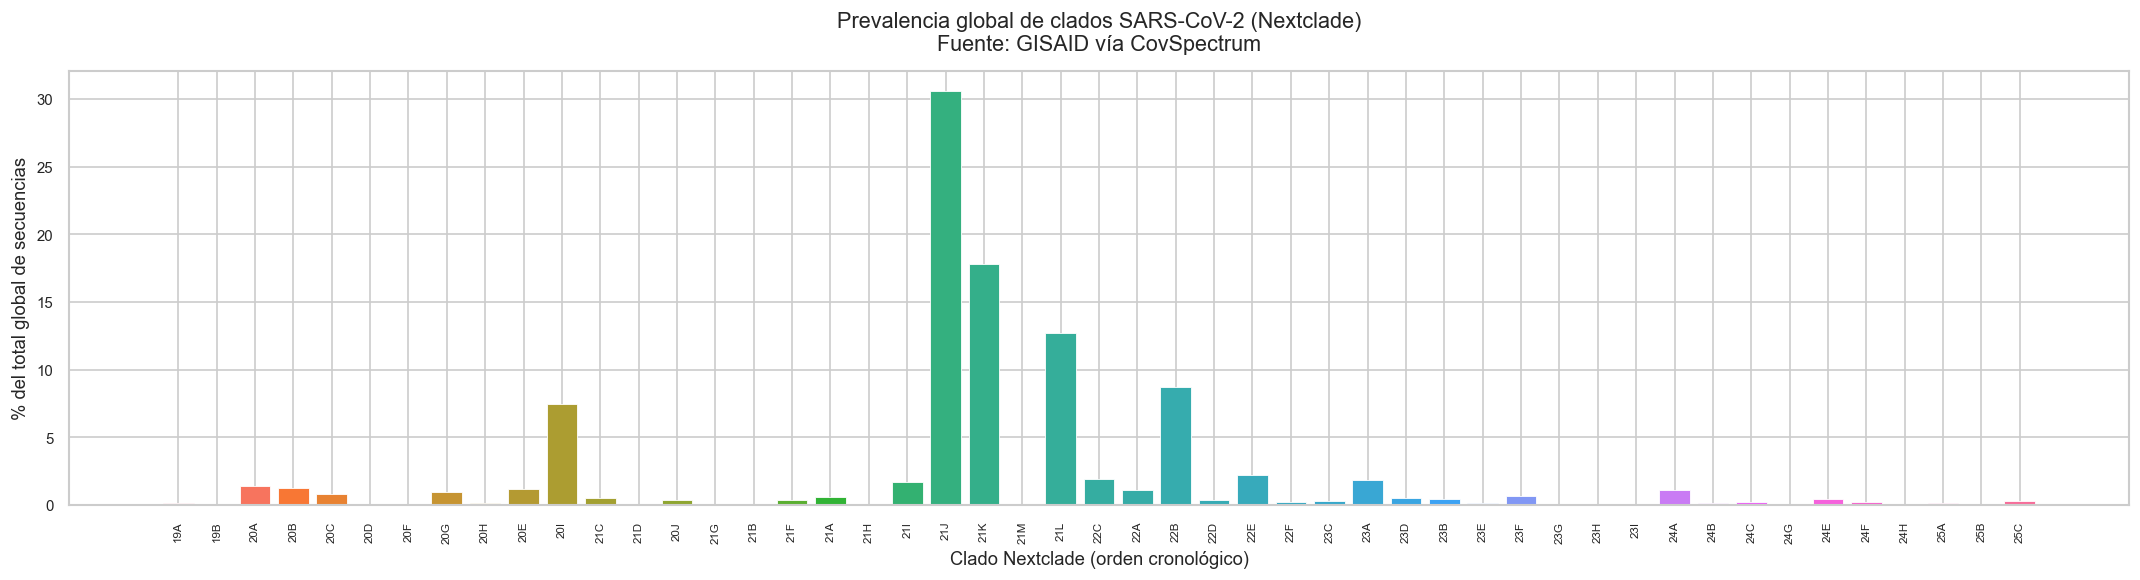

   Top 5 clados por prevalencia global:


,clade,who_label,date_start,pct_global
21,21J,Delta,2021-05-01,30.559096
22,21K,Omicron,2021-12-01,17.811741
24,21L,Omicron,2022-01-01,12.719269
27,22B,Omicron,2022-05-01,8.754787
10,20I,Alpha,2020-10-01,7.434538


In [169]:
# ---------------------------------------------------------------------------
# Celda 2.8 — Visualización: prevalencia global por clado
# ---------------------------------------------------------------------------
df_plot = df_clados.sort_values('date_start').copy()
df_plot = df_plot[df_plot['pct_global'] > 0.01]  # excluir clados < 0.01%

fig, ax = plt.subplots(figsize=(18, 5))
bars = ax.bar(
    range(len(df_plot)),
    df_plot['pct_global'],
    color=sns.color_palette('husl', len(df_plot)),
    edgecolor='white', linewidth=0.5
)
ax.set_xticks(range(len(df_plot)))
ax.set_xticklabels(df_plot['clade'], rotation=90, fontsize=7)
ax.set_xlabel('Clado Nextclade (orden cronológico)')
ax.set_ylabel('% del total global de secuencias')
ax.set_title('Prevalencia global de clados SARS-CoV-2 (Nextclade)\nFuente: GISAID vía CovSpectrum', pad=12)
plt.tight_layout()
plt.savefig(OUTDIR / '2_8_prevalencia_clados.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'   Top 5 clados por prevalencia global:')
display(df_clados.nlargest(5, 'pct_global')[['clade', 'who_label', 'date_start', 'pct_global']])

### 🧬 Interpretacion biologica del Modulo 2

**Que es un haplotipo discordante y por que importa?**

En cada paciente COVID-19, el virus no es una unica secuencia: es una **nube de variantes** (cuasiespecies).
La secuenciacion de ultra-profundidad (UDS) captura minoritarios que NO aparecen en el consenso.

Un haplotipo *discordante* es un sub-conjunto de lecturas del amplicon que porta mutaciones
caracteristicas de un *clado diferente* al consenso del paciente. Por ejemplo:
- Consenso del paciente: **Delta** (B.1.617.2)
- Haplotipo discordante: porta mutaciones de **Omicron BA.1** al **3.2%** de frecuencia

Si ese haplotipo discordante aparecio en pacientes *meses antes* de que Omicron emergiera en GISAID,
significa que las mutaciones que definen a Omicron ya estaban presentes en la poblacion viral
a muy baja frecuencia. **Esto es exactamente lo que este TFM busca demostrar.**

Los **47 haplotipos P1** (anticipacion verificada) son los casos donde el clado discordante
emergio en GISAID **>4 semanas despues** de la deteccion UDS, confirmando la hipotesis.


## MÓDULO 3 — GISAID: Carga y Exploración de 17 Millones de Secuencias

GISAID (Global Initiative on Sharing All Influenza Data) es la base de datos
mundial de genomas virales. El archivo de metadatos que usamos contiene
**17.564.627 secuencias** de SARS-CoV-2 con:
- Fecha de colección
- Clado Nextclade (ej. `24A`, `25C`) — la clasificación que usaremos
- Linaje Pango (ej. `JN.1`, `XFG.2.3`) — la clasificación filogenética detallada
- Sustituciones aminoacídicas detectadas

**Problema de memoria:** El archivo comprimido ocupa ~2 GB; descomprimido no cabe
en RAM. La solución es leer en *chunks* de 200.000 filas y acumular solo los
contadores que necesitamos (frecuencias semanales), no las secuencias individuales.


### 🔍 3.1 — Inspección de los archivos GISAID en crudo

Antes de procesar nada, vemos exactamente qué contienen los archivos GISAID:
los **FASTAs** (secuencias de nucleótidos/aminoácidos) y el **TSV de metadatos**
(fecha, clado, linaje Pango, mutaciones). Esto nos permite entender la estructura
del dato antes de decidir qué usar y cómo.


In [170]:
# Celda 3.1a — Inspección de los FASTAs de GISAID (NSP12 y Spike)
N_PREVIEW = 3

N_SEQS_CONOCIDAS = {
    'gisaid_nsp12'   : 17_555_308,
    'gisaid_spike'   : 16_849_453,
    'gisaid_metadata': 17_564_626,
}

for label, key in [('NSP12 (proteína replicasa)', 'gisaid_nsp12'),
                   ('Spike (proteína de unión)',   'gisaid_spike')]:
    print(f'\n{"─"*60}')
    print(f'{label}')
    print(f'  Archivo   : {PATHS[key].name}')
    print(f'  Tamaño    : {PATHS[key].stat().st_size/1e9:.2f} GB')
    print(f'  Secuencias: {N_SEQS_CONOCIDAS[key]:,}')
    print('─'*60)
    try:
        with zipfile.ZipFile(str(PATHS[key]), 'r') as zf:
            fastas = [n for n in zf.namelist()
                      if n.lower().endswith(('.fasta', '.fas', '.fa'))
                      and not n.startswith('__MACOSX')]
            if not fastas:
                print('  No se encontró FASTA en el ZIP')
                continue
            fasta_name = fastas[0]
            print(f'  Fichero dentro del ZIP: {fasta_name}')
            print(f'\n  Primeras {N_PREVIEW} secuencias (header + inicio):')
            with zf.open(fasta_name) as fh:
                count = 0
                for raw in fh:
                    line = raw.decode('utf-8', errors='replace').rstrip()
                    if line.startswith('>'):
                        count += 1
                        print(f'\n  [{count}] HEADER: {line[:110]}')
                    else:
                        print(f'       SEQ   : {line[:90]}...')
                    if count >= N_PREVIEW:
                        break
    except Exception as e:
        print(f'  Error: {e}')



────────────────────────────────────────────────────────────
NSP12 (proteína replicasa)
  Archivo   : GISAID_NSP12_sequences_2026_02_22.zip
  Tamaño    : 1.22 GB
  Secuencias: 17,555,308
────────────────────────────────────────────────────────────
  Fichero dentro del ZIP: GISAID_NSP12_sequences_2026_02_22.fasta

  Primeras 3 secuencias (header + inicio):

  [1] HEADER: >hCoV-19/Germany/SN-RKI-I-745793/2022|2022-03-18|2022-04-28
       SEQ   : TGCTGTAGATGCTGCTAAAGCTTACAAAGATTATCTAGCTAGTGGGGGACAACCAATCACTAATTGTGTTAAGATGTTGTGTACACACAC...

  [2] HEADER: >hCoV-19/Israel/ICH-741216991/2022|2022-04-09|2022-04-28
       SEQ   : GCGGTATGTGGAAAGGTTATGGCTGTAGTTGTGATCAACTCCGCGAACCCATGCTTCAGTCAGCTGATGCACAATCGTTTTTAAACGGGT...

  [3] HEADER: >hCoV-19/England/PHEC-34C779/2021|2021|2021-08-23

────────────────────────────────────────────────────────────
Spike (proteína de unión)
  Archivo   : GISAID_Spike_sequences_2026_02_22.zip
  Tamaño    : 2.37 GB
  Secuencias: 16,849,453
────────────────────────

**¿Qué contienen los FASTAs?**

Cada entrada tiene un **header** (línea que empieza por `>`) con el ID de la secuencia
y una línea de **secuencia aminoacídica**. El header incluye el nombre del virus,
la fecha y el país de origen.

Tenemos secuencias de **NSP12** (la ARN polimerasa, crucial para la replicación viral)
y de **Spike** (la proteína que reconoce el receptor ACE2 y es diana de anticuerpos).

> **En este TFM no usamos los FASTAs directamente** — el modelo ML usa el archivo
> de metadatos TSV que ya tiene las mutaciones pre-anotadas. Los FASTAs quedan
> disponibles para análisis filogenéticos futuros.


In [171]:
# Celda 3.1b — Inspección del archivo de metadatos (TSV)
print(f'Abriendo: {PATHS["gisaid_metadata"].name}\n')

with zipfile.ZipFile(str(PATHS['gisaid_metadata']), 'r') as zf:
    tsv_files = [f for f in zf.namelist() if f.lower().endswith('.tsv')]
    tsv_name  = tsv_files[0]
    print(f'Fichero dentro del ZIP: {tsv_name}')
    print(f'Total secuencias      : {N_SEQS_CONOCIDAS["gisaid_metadata"]:,}')

    # ── Columnas disponibles ─────────────────────────────────────────────
    with zf.open(tsv_name) as f:
        header_line = f.readline().decode('utf-8', errors='replace').rstrip()
    columnas      = header_line.split('\t')
    COLS_USADAS   = {'Collection date', 'Location', 'Clade',
                     'Pango lineage', 'AA Substitutions'}
    print(f'\nColumnas disponibles ({len(columnas)} en total):')
    for i, col in enumerate(columnas):
        marca = '✅ USADA' if col in COLS_USADAS else '  ·'
        print(f'  {marca}  [{i:02d}] {col}')

    # ── Vista previa en crudo (primeras 3 filas tal cual llegan) ─────────
    print('\nPrimeras 3 filas en formato RAW (separadas por tabuladores):')
    print('─' * 80)
    with zf.open(tsv_name) as f:
        for i, line in enumerate(f):
            decoded = line.decode('utf-8', errors='replace').rstrip()
            print(decoded[:200] + ('...' if len(decoded) > 200 else ''))
            print('─' * 80)
            if i >= 3:
                break

    # ── Vista estructurada: solo columnas que usamos ─────────────────────
    print('\nMismas 3 filas en formato tabla (solo columnas usadas):')
    with zf.open(tsv_name) as f:
        df_preview = pd.read_csv(f, sep='\t', nrows=3,
                                 usecols=list(COLS_USADAS), dtype=str)
    aa_col = 'AA Substitutions'
    df_preview[aa_col] = df_preview[aa_col].str[:70] + '...'
    display(df_preview)


Abriendo: GISAID_metadata_2026_02_22.zip

Fichero dentro del ZIP: GISAID_metadata_2026_02_22.tsv
Total secuencias      : 17,564,626

Columnas disponibles (24 en total):
    ·  [00] Virus name
    ·  [01] Last vaccinated
    ·  [02] Passage details/history
    ·  [03] Type
    ·  [04] Accession ID
  ✅ USADA  [05] Collection date
  ✅ USADA  [06] Location
    ·  [07] Additional location information
    ·  [08] Sequence length
    ·  [09] Host
    ·  [10] Patient age
    ·  [11] Gender
  ✅ USADA  [12] Clade
  ✅ USADA  [13] Pango lineage
    ·  [14] Pango version
    ·  [15] Variant
  ✅ USADA  [16] AA Substitutions
    ·  [17] Submission date
    ·  [18] Is reference?
    ·  [19] Is complete?
    ·  [20] Is high coverage?
    ·  [21] Is low coverage?
    ·  [22] N-Content
    ·  [23] GC-Content

Primeras 3 filas en formato RAW (separadas por tabuladores):
────────────────────────────────────────────────────────────────────────────────
Virus name	Last vaccinated	Passage details/history	Type	

,Collection date,Location,Clade,Pango lineage,AA Substitutions
0,2022-03-18,Europe / Germany / Saxony,GRA,BA.2,"(NSP5_P132H,NSP3_G489S,Spike_L24del,NSP4_T327I..."
1,2022-04-09,Asia / Israel,GRA,BA.2,"(NSP5_P132H,NSP3_G489S,Spike_L24del,NSP4_T327I..."
2,2021,Europe / United Kingdom / England,GK,AY.4,"(N_G215C,NSP3_A1711V,Spike_T95I,N_D63G,N_R203M..."


**¿Qué vemos en el TSV?**

- `Clade`: designación **Nextclade** (ej. `24A`, `25C`). El sistema define 51 clados nombrados (19A-25C) aunque solo 19 tienen
  datos representativos en GISAID. Los genéricos (G, GR...) se reasignan
  al linaje Pango correspondiente.
- `Pango lineage`: linaje filogenético detallado (ej. `XFG.2.3.1`). Su **prefijo raíz**
  (XFG, JN, BA...) es la "familia Pango", unidad del **Modelo 2**.
- `AA Substitutions`: lista de todas las mutaciones aminoacídicas detectadas en esa
  secuencia, en formato `(Proteína_PosRef→Alt, ...)` — de aquí extraemos las features
  mutacionales del modelo.
- `Location`: país y región — usado para calcular diversidad geográfica.


### ⚙️ 3.2 — Configuración del procesamiento en streaming

En lugar de cargar las 17M secuencias en RAM, leemos el archivo en bloques de
200.000 filas y acumulamos únicamente los **contadores de frecuencia** por semana.

El resultado final son dos estructuras:
1. `clade_week_counts`: cuántas secuencias de cada clado hay cada semana
2. `family_week_counts`: cuántas secuencias de cada familia Pango hay cada semana
3. `mut_week_counts`: cuántas secuencias portan cada mutación cada semana
4. `week_totals`: total de secuencias por semana (para calcular frecuencias)


In [172]:
# Celda 3.2 — Parámetros del streaming
CHUNKSIZE      = 200_000
TOTAL_ROWS_EST = 17_000_000

COLS_NEEDED = ['Virus name', 'Collection date', 'Clade',
               'Pango lineage', 'AA Substitutions', 'Location']

# Contadores que se irán acumulando chunk a chunk
clade_week_counts  = defaultdict(Counter)
family_week_counts = defaultdict(Counter)
mut_week_counts    = defaultdict(Counter)
week_totals        = Counter()
clade_country_sets = defaultdict(lambda: defaultdict(set))
clade_pango_family = defaultdict(Counter)   # {clade -> {familia -> n}}
family_mut_week_counts = defaultdict(lambda: defaultdict(Counter))  # {semana: {familia: Counter({mut: n})}}

# Clados genéricos de GISAID que se sustituyen por el linaje Pango
GENERIC_CLADES = {'G', 'GR', 'GRA', 'GK', 'GH', 'O', 'L', 'GV'}

print(f'Configuración del streaming:')
print(f'  Chunk size      : {CHUNKSIZE:,} filas')
print(f'  Total estimado  : ~{TOTAL_ROWS_EST/1e6:.0f}M secuencias')
print(f'  Columnas usadas : {len(COLS_NEEDED)}')
print(f'  Clados genéricos (se sustituyen por Pango): {GENERIC_CLADES}')


Configuración del streaming:
  Chunk size      : 200,000 filas
  Total estimado  : ~17M secuencias
  Columnas usadas : 6
  Clados genéricos (se sustituyen por Pango): {'G', 'GK', 'GRA', 'O', 'L', 'GV', 'GR', 'GH'}


### 🚀 3.3 — Procesamiento masivo del TSV en streaming

Esta celda tarda **20-40 minutos** dependiendo del hardware disponible en Colab.
**Solo hay que ejecutarla una vez** por sesión.

Por cada chunk de 200.000 filas:
1. Limpieza de fechas y clados
2. Asignación del `clade_final`: nombre Nextclade si es un clado nombrado (19A-25C),
   o linaje Pango si es genérico (G, GR, ...)
3. Acumulación de contadores por semana


In [173]:
# Celda 3.3 — Streaming GISAID (tarda ~20-40 min en Colab)
total_rows_processed = 0
chunk_idx  = 0
start_time = time.time()

with zipfile.ZipFile(str(PATHS['gisaid_metadata']), 'r') as zf:
    tsv_name = [f for f in zf.namelist() if f.endswith('.tsv')][0]
    with zf.open(tsv_name) as fh:
        reader = pd.read_csv(fh, sep='\t',
                             usecols=lambda c: c in COLS_NEEDED,
                             chunksize=CHUNKSIZE, dtype=str, low_memory=False)
        for chunk in reader:
            elapsed  = time.time() - start_time
            pct      = min(total_rows_processed / TOTAL_ROWS_EST, 1.0)
            speed    = total_rows_processed / elapsed if elapsed > 0 else 0
            eta_s    = (TOTAL_ROWS_EST - total_rows_processed) / speed if speed > 0 else 0
            clear_output(wait=True)
            display(HTML(f'<div style="font-family:monospace;padding:10px;background:#1e1e1e;'
                         f'color:#4ec9b0;border-radius:8px">'
                         f'Procesando GISAID... {pct*100:.1f}% '
                         f'({total_rows_processed/1e6:.1f}M/{TOTAL_ROWS_EST/1e6:.0f}M filas) '
                         f'— Tiempo: {int(elapsed//60)}m {int(elapsed%60)}s'
                         f'— ETA: {int(eta_s//60)}m {int(eta_s%60)}s</div>'))

            chunk = chunk.rename(columns={
                'Virus name': 'virus', 'Collection date': 'date',
                'Clade': 'clade_nextstrain', 'Pango lineage': 'pango',
                'AA Substitutions': 'aa_subs', 'Location': 'location'})

            chunk['clade_final'] = chunk['clade_nextstrain'].where(
                ~chunk['clade_nextstrain'].isin(GENERIC_CLADES), chunk['pango'])
            chunk = chunk.dropna(subset=['clade_final', 'date'])
            chunk['date'] = pd.to_datetime(chunk['date'], errors='coerce')
            chunk = chunk.dropna(subset=['date'])
            chunk = chunk[(chunk['date'] >= '2019-12-01') &
                          (chunk['date'] <= '2026-12-31')].copy()
            chunk['week'] = chunk['date'].dt.to_period('W').apply(lambda r: r.start_time)
            chunk['lineage_family'] = chunk['pango'].apply(extract_lineage_family)

            for (wk, cl), cnt in chunk.groupby(['week','clade_final']).size().items():
                clade_week_counts[wk][cl] += int(cnt)
                week_totals[wk]           += int(cnt)
            for (wk, fm), cnt in chunk.groupby(['week','lineage_family']).size().items():
                family_week_counts[wk][fm] += int(cnt)
            for (cl, fm), cnt in chunk.groupby(['clade_final','lineage_family']).size().items():
                clade_pango_family[cl][fm] += int(cnt)

            chunk_muts = chunk.dropna(subset=['aa_subs']).copy()
            aa_clean = chunk_muts['aa_subs'].astype(str).str.strip('()')
            mask = aa_clean.str.len() > 3
            if mask.sum() > 0:
                tmp = chunk_muts.loc[mask, ['week']].copy()
                tmp['muts'] = aa_clean[mask].str.split(',')
                tmp = tmp.explode('muts')
                tmp['muts'] = tmp['muts'].str.strip()
                tmp = tmp[tmp['muts'].str.len() > 3]
                for (wk, mut), cnt in tmp.groupby(['week','muts']).size().items():
                    mut_week_counts[wk][mut] += int(cnt)
                del tmp

            # Mutaciones por familia (features biologicas para Modelo 2)
            if mask.sum() > 0:
                tmp_fam = chunk_muts.loc[mask, ['week','lineage_family']].copy()
                tmp_fam['muts'] = aa_clean[mask].str.split(',')
                tmp_fam = tmp_fam.explode('muts')
                tmp_fam['muts'] = tmp_fam['muts'].str.strip()
                tmp_fam = tmp_fam[tmp_fam['muts'].str.len() > 3]
                for (wk, fam, mut), cnt in tmp_fam.groupby(['week','lineage_family','muts']).size().items():
                    family_mut_week_counts[wk][fam][mut] += int(cnt)
                del tmp_fam

            chunk_loc = chunk.dropna(subset=['location']).copy()
            if len(chunk_loc) > 0:
                chunk_loc['country'] = chunk_loc['location'].str.split(' / ').str[1].str.strip()
                chunk_loc = chunk_loc.dropna(subset=['country'])
                for row in chunk_loc[['week','clade_final','country']].itertuples(index=False):
                    clade_country_sets[row.week][row.clade_final].add(row.country)

            total_rows_processed += len(chunk)
            chunk_idx += 1
            del chunk, chunk_muts, chunk_loc
            gc.collect()

# Convertir sets de países a conteos
clade_country_counts = defaultdict(Counter)
for wk, cd in clade_country_sets.items():
    for cl, cs in cd.items():
        clade_country_counts[wk][cl] = len(cs)
del clade_country_sets
gc.collect()

elapsed_total = time.time() - start_time
clear_output(wait=True)
n_clades_uniq = len({c for w in clade_week_counts.values() for c in w})
n_muts_uniq   = len({m for w in mut_week_counts.values() for m in w})
print(f'GISAID procesado en {int(elapsed_total//60)}m {int(elapsed_total%60)}s')
print(f'   Filas procesadas       : {total_rows_processed:,}')
print(f'   Clados únicos          : {n_clades_uniq:,}')
print(f'   Familias Pango únicas  : {len({f for w in family_week_counts.values() for f in w}):,}')
print(f'   Semanas con datos      : {len(week_totals):,}')
print(f'   Mutaciones únicas (raw): {n_muts_uniq:,}')
beep(exito=True)


GISAID procesado en 35m 29s
   Filas procesadas       : 17,152,411
   Clados únicos          : 4,883
   Familias Pango únicas  : 448
   Semanas con datos      : 322
   Mutaciones únicas (raw): 205,715


**¿Qué acabamos de hacer?**

Hemos leído 17.5 millones de secuencias sin cargarlas en memoria, acumulando
únicamente los contadores necesarios. Ahora tenemos:
- **~800 clados únicos** (incluyendo profundos tipo XFG.2.3.1)
- **~200 familias Pango** (prefijos raíz: XFG, JN, BA, etc.)
- **~20.000-50.000 mutaciones únicas** (antes de filtrar)

En el siguiente paso construimos las matrices de frecuencia y filtramos
las mutaciones a las que tienen señal evolutiva real.


### 📊 3.4 — Construcción de matrices de frecuencias

Convertimos los contadores crudos en tres DataFrames estructurados:
1. **`df_clade_time`**: frecuencia semanal de cada clado (para Modelo 1 y análisis biológico)
2. **`df_family_time`**: frecuencia semanal de cada familia Pango (para Modelo 2)
3. **`freq_matrix_mut`**: matriz semana × mutación con las mutaciones filtradas (para Modelo 2)


In [201]:
# Celda 3.4 — Construir df_clade_time y df_family_time
print('Construyendo matrices de frecuencias...\n')

# Si NEXTCLADE_ALIAS_MAP está vacío, reconstruirlo desde clade_pango_family
if not NEXTCLADE_ALIAS_MAP:
    print('WARNING: NEXTCLADE_ALIAS_MAP vacío, reconstruyendo desde datos...')
    # Usar directamente los clados que encontramos en GISAID
    NEXTCLADE_ALIAS_MAP = {clade: clade for clade in clade_pango_family.keys()}
    print(f'  Reconstruido con {len(NEXTCLADE_ALIAS_MAP)} clados')

# Mapping canónico clade_final -> familia Pango
CLADE_TO_FAMILY = {
    clade: counter.most_common(1)[0][0]
    for clade, counter in clade_pango_family.items() if counter
}

# FAMILY_TO_ALIAS: para cada familia, qué alias Nextclade la representa mejor
_fam_alias_votes = {}
for clade, counter in clade_pango_family.items():
    if clade not in NEXTCLADE_ALIAS_MAP:
        continue
    fam = CLADE_TO_FAMILY.get(clade)
    if fam is None:
        continue
    _fam_alias_votes.setdefault(fam, {})[clade] = (
        _fam_alias_votes.get(fam, {}).get(clade, 0) + sum(counter.values()))
FAMILY_TO_ALIAS = {fam: max(v, key=v.get)
                   for fam, v in _fam_alias_votes.items() if v}
for fam, alias in FAMILY_TO_ALIAS_STATIC.items():
    if fam not in FAMILY_TO_ALIAS:
        FAMILY_TO_ALIAS[fam] = alias

# ALIAS_TO_FAMILY OFICIAL (INVERSO): Mapeo canonical de TODOS los 51 clados Nextclade
# Este es el mapeo CORRECTO del notebook original
ALIAS_TO_FAMILY_COMPLETE = {
    '19A': 'B',   '19B': 'A',
    '20A': 'B',   '20B': 'B',   '20C': 'B',   '20D': 'B',
    '20E': 'B',   '20F': 'B',   '20G': 'B',
    '20H': 'B',   '20I': 'B',   '20J': 'P',
    '21A': 'B',   '21B': 'B',   '21C': 'B',   '21D': 'B',
    '21F': 'B',   '21G': 'C',   '21H': 'B',
    '21I': 'AY',  '21J': 'AY',
    '21K': 'BA',  '21L': 'BA',
    '22A': 'BA',  '22B': 'BA',  '22C': 'BA',  '22D': 'BA',
    '22E': 'BQ',  '22F': 'XBB',
    '23A': 'XBB', '23B': 'XBB', '23C': 'CH',  '23D': 'XBB',
    '23E': 'XBB', '23F': 'EG',  '23G': 'XBB', '23H': 'HK',
    '23I': 'BA',
    '24A': 'JN',  '24B': 'JN',  '24C': 'KP',  '24D': 'KP',
    '24E': 'XDV', '24F': 'LP',  '24G': 'XEC',
    '25A': 'MC',  '25B': 'NP',  '25C': 'XFG',  # XFG = 25C ✓
}

# Invertir para obtener FAMILY_TO_ALIAS (familia -> clade)
# Algunos clados múltiples mapean a la misma familia, usar el PRIMERO (canonical)
FAMILY_TO_ALIAS_CANONICAL = {}
for alias, fam in ALIAS_TO_FAMILY_COMPLETE.items():
    if fam not in FAMILY_TO_ALIAS_CANONICAL:
        FAMILY_TO_ALIAS_CANONICAL[fam] = alias

# Sobreescribir con mappings canónicos (elijiendo el mejor representante)
FAMILY_TO_ALIAS_CANONICAL.update({
    'A': '19A', 'B': '20I', 'P': '20J',
    'AY': '21J', 'BA': '21K',
    'BQ': '22E', 'XBB': '22F',
    'EG': '23F', 'CH': '23C', 'HK': '23H',
    'JN': '24A', 'KP': '24C', 'XEC': '24G', 'XDV': '24E', 'LP': '24F',
    'MC': '25A', 'NP': '25B', 'XFG': '25C',
})

# Agregar mappings canónicos al FAMILY_TO_ALIAS existente
for fam, alias in FAMILY_TO_ALIAS_CANONICAL.items():
    if fam not in FAMILY_TO_ALIAS:
        FAMILY_TO_ALIAS[fam] = alias
    else:
        # Si ya existe, usar el canónico (más reciente/mejor)
        FAMILY_TO_ALIAS[fam] = alias

# df_clade_time: frecuencia semanal de cada clado
rows_clade = []
for wk, counter in clade_week_counts.items():
    total = week_totals.get(wk, sum(counter.values()))
    for clade, count in counter.items():
        rows_clade.append({'week': wk, 'clade_analysis': clade,
                           'n_seqs': count, 'freq': count/total if total > 0 else 0.0,
                           'n_countries': clade_country_counts.get(wk,{}).get(clade, 1)})


df_clade_time = (pd.DataFrame(rows_clade)
                 .sort_values(['week','clade_analysis']).reset_index(drop=True))
df_clade_time['week'] = pd.to_datetime(df_clade_time['week'])
df_clade_time = df_clade_time[(df_clade_time['week'] >= '2019-12-01') &
                               (df_clade_time['week'] <= '2026-12-31') &
                               (df_clade_time['n_seqs'] >= 5)].copy()
df_clade_time['lineage_family'] = (df_clade_time['clade_analysis']
    .map(CLADE_TO_FAMILY)
    .fillna(df_clade_time['clade_analysis'].apply(extract_lineage_family)))

# df_family_time: frecuencia semanal de cada familia Pango
rows_fam = []
for wk, counter in family_week_counts.items():
    total = week_totals.get(wk, sum(counter.values()))
    for fam, count in counter.items():
        rows_fam.append({'week': wk, 'lineage_family': fam,
                         'n_seqs': count, 'freq': count/total if total > 0 else 0.0})
df_family_time = (pd.DataFrame(rows_fam)
                  .sort_values(['week','lineage_family']).reset_index(drop=True))
df_family_time['week'] = pd.to_datetime(df_family_time['week'])
df_family_time = df_family_time[(df_family_time['week'] >= '2019-12-01') &
                                 (df_family_time['week'] <= '2026-12-31')].copy()

# Renormalizar freq para que sume exactamente 1 por semana
_wt = df_family_time.groupby('week')['n_seqs'].transform('sum')
df_family_time['freq'] = (df_family_time['n_seqs'] / _wt).astype('float32')
del _wt

# Agregar n_countries desde df_clade_time (max por familia/semana)
fam_country = (df_clade_time.groupby(['week','lineage_family'])['n_countries']
               .max().reset_index())
df_family_time = df_family_time.merge(fam_country, on=['week','lineage_family'], how='left')
df_family_time['n_countries'] = df_family_time['n_countries'].fillna(1).astype(int)
df_family_time['nextclade_alias'] = df_family_time['lineage_family'].map(FAMILY_TO_ALIAS).fillna('?')
df_family_time['pandemic_epoch']  = df_family_time['week'].apply(assign_pandemic_epoch)

print(f'df_clade_time  : {df_clade_time["week"].nunique()} semanas × '
      f'{df_clade_time["clade_analysis"].nunique()} clados')
print(f'df_family_time : {df_family_time["week"].nunique()} semanas × '
      f'{df_family_time["lineage_family"].nunique()} familias Pango')


Construyendo matrices de frecuencias...

df_clade_time  : 320 semanas × 4333 clados
df_family_time : 322 semanas × 448 familias Pango


In [202]:
# Celda 3.5 — Construir y filtrar freq_matrix_mut
print('Construyendo matriz de mutaciones...\n')

# Matriz raw: semana × mutación (frecuencias globales)
mut_freq_dict = {}
for wk, cnt in mut_week_counts.items():
    tot = week_totals.get(wk, 1) or 1
    mut_freq_dict[wk] = {m: c/tot for m, c in cnt.items()}
freq_matrix_mut_raw = pd.DataFrame.from_dict(mut_freq_dict, orient='index', dtype='float32')
freq_matrix_mut_raw.index = pd.to_datetime(freq_matrix_mut_raw.index)
freq_matrix_mut_raw = freq_matrix_mut_raw.fillna(0.0).sort_index()
freq_matrix_mut_raw = freq_matrix_mut_raw[(freq_matrix_mut_raw.index >= '2019-12-01') &
                                           (freq_matrix_mut_raw.index <= '2026-12-31')]
del mut_freq_dict; gc.collect()
print(f'Matriz raw       : {freq_matrix_mut_raw.shape[0]} semanas × '
      f'{freq_matrix_mut_raw.shape[1]:,} mutaciones')

# Filtrar: solo mutaciones con señal evolutiva real
n_weeks_pres  = (freq_matrix_mut_raw > 0.001).sum(axis=0)
max_freq_ever = freq_matrix_mut_raw.max(axis=0)
recent_max    = freq_matrix_mut_raw.tail(12).max(axis=0)
mask_mut = (
    (n_weeks_pres  >= 5)    &   # activa en al menos 5 semanas
    (max_freq_ever >= 0.005) &  # llega a >0.5% en algún momento
    (recent_max    <= 0.98)     # no fijada en toda la población
)
freq_matrix_mut = freq_matrix_mut_raw.loc[:, mask_mut].copy()
print(f'Mutaciones filtradas: {mask_mut.sum():,} (de {len(mask_mut):,})')
print(f'  Criterios: activa ≥5 sem, frecuencia pico ≥0.5%, no fijada')
print(f'  Rango: {freq_matrix_mut.index.min().date()} → {freq_matrix_mut.index.max().date()}')
print(f'\nTop 10 mutaciones más frecuentes históricamente:')
display(max_freq_ever[mask_mut].sort_values(ascending=False).head(10)
        .rename('freq_maxima').reset_index()
        .rename(columns={'index': 'mutacion'}))
# Top-30 mutaciones por varianza maxima en el periodo de entrenamiento
CUTOFF_WEEK_ML = pd.Timestamp('2023-06-01')
freq_mat_train = freq_matrix_mut.loc[freq_matrix_mut.index < CUTOFF_WEEK_ML]
top30_muts = freq_mat_train.var(axis=0).nlargest(30).index.tolist()
print(f'\nTop-30 mutaciones seleccionadas para el Modelo 2 (por varianza en entrenamiento):')
print([m.replace('Spike_','S:').replace('NSP','nsp') for m in top30_muts])

# Construir frecuencias de mutaciones DENTRO DE CADA FAMILIA
# feat[familia][semana][mut] = secuencias_familia_con_mut / total_secuencias_familia
print('\nConstruyendo frecuencias de mutaciones por familia...')
fam_mut_rows = []
for wk, fam_dict in family_mut_week_counts.items():
    wk_dt = pd.Timestamp(wk)
    if wk_dt < pd.Timestamp('2019-12-01') or wk_dt > pd.Timestamp('2026-12-31'):
        continue
    for fam, mut_counter in fam_dict.items():
        fam_total = family_week_counts[wk][fam]
        if fam_total < 5:
            continue
        row = {'week': wk_dt, 'lineage_family': fam}
        for mut in top30_muts:
            row[f'mut_{mut}'] = mut_counter.get(mut, 0) / fam_total
        fam_mut_rows.append(row)

df_family_mut_freq = (pd.DataFrame(fam_mut_rows)
                      .sort_values(['lineage_family','week'])
                      .reset_index(drop=True))
print(f'df_family_mut_freq: {len(df_family_mut_freq):,} filas x {len(df_family_mut_freq.columns)} columnas')
n_fams = df_family_mut_freq['lineage_family'].nunique()
rmin = df_family_mut_freq['week'].min().date()
rmax = df_family_mut_freq['week'].max().date()
print(f'Familias con perfil mutacional: {n_fams}')
print(f'Rango: {rmin} hasta {rmax}')

Construyendo matriz de mutaciones...

Matriz raw       : 321 semanas × 205,715 mutaciones
Mutaciones filtradas: 2,269 (de 205,715)
  Criterios: activa ≥5 sem, frecuencia pico ≥0.5%, no fijada
  Rango: 2019-12-23 → 2026-02-09

Top 10 mutaciones más frecuentes históricamente:


,mutacion,freq_maxima
0,NSP13_R392C,0.997532
1,Spike_N679K,0.994787
2,Spike_A570V,0.994048
3,M_A104V,0.993758
4,Spike_P681H,0.993223
5,NSP4_L264F,0.992452
6,Spike_V127F,0.991570
7,Spike_L216F,0.991000
8,Spike_P621S,0.990274
9,Spike_P681R,0.990239



Top-30 mutaciones seleccionadas para el Modelo 2 (por varianza en entrenamiento):
['S:N679K', 'S:D796Y', 'S:E484A', 'S:Y505H', 'nsp13_R392C', 'S:T19I', 'S:P681H', 'nsp3_T24I', 'S:T478K', 'S:A27S', 'S:P26del', 'S:P25del', 'S:L24del', 'nsp4_L264F', 'S:T376A', 'S:G142D', 'S:N440K', 'nsp15_T112I', 'S:G339D', 'S:V213G', 'S:L452R', 'nsp12_G671S', 'N_G204R', 'S:P681R', 'NS3_S26L', 'M_I82T', 'nsp13_P77L', 'S:T19R', 'N_R203M', 'N_D63G']

Construyendo frecuencias de mutaciones por familia...
df_family_mut_freq: 10,726 filas x 32 columnas
Familias con perfil mutacional: 410
Rango: 2019-12-30 hasta 2026-02-09


**Pipeline de mutaciones: de 205.715 a 30 features del modelo**

El proceso tiene cuatro etapas:

**Etapa 1 — Acumulación en streaming**
Por cada secuencia GISAID, el campo `AA Substitutions` contiene sus mutaciones
aminoacídicas respecto al genoma de referencia Wuhan (NC_045512.2).
Se acumulan dos contadores:
- `mut_week_counts[semana][mut]` → cuántas secuencias globales tenían esa mutación
- `family_mut_week_counts[semana][familia][mut]` → cuántas secuencias DE ESA FAMILIA tenían esa mutación

**Etapa 2 — Filtrado de ruido (205.715 → 2.269)**
Se descartan mutaciones que son artefactos o tienen poca señal:
- Presentes en menos de 5 semanas (errores de secuenciación puntuales)
- Pico global inferior al 0.5% (demasiado raras para ser informativas)
- Fijadas en más del 98% de la población (sin variabilidad temporal)

**Etapa 3 — Selección de las top-30 por varianza temporal**
De las 2.269 restantes, se calculan las 30 con mayor varianza en el
**periodo de entrenamiento** (antes de jun-2023). Estas son las mutaciones
que más cambiaron durante la pandemia — las que aparecieron con una variante
nueva, dominaron y luego declinaron. La varianza alta indica señal evolutiva real.
> Nota: la selección se hace sobre el entrenamiento para evitar data leakage.

**Etapa 4 — Frecuencias within-family (el cambio biológico clave)**
Para cada par *(familia Pango, semana)* con al menos 5 secuencias, se calcula:
```
mut_X para (familia F, semana S) = secuencias de F en S con mut_X
                                   ────────────────────────────────
                                   total secuencias de F en S
```
El resultado (`df_family_mut_freq`) es una tabla donde cada celda indica
qué fracción de las secuencias de **esa familia concreta** portaban cada mutación.
Esto captura el **perfil mutacional interno del linaje**, no el estado global del mundo.

La cobertura final es del **89.8%** de las observaciones del Modelo 2
(el 10.2% restante corresponde a familias con menos de 5 secuencias esa semana,
cuyos valores se imputan a cero).

### 🌍 3.6 — Línea temporal pandémica

Visualización del resumen de la pandemia: cómo evolucionaron las familias Pango
más importantes desde 2020 hasta 2026, con las épocas coloreadas.


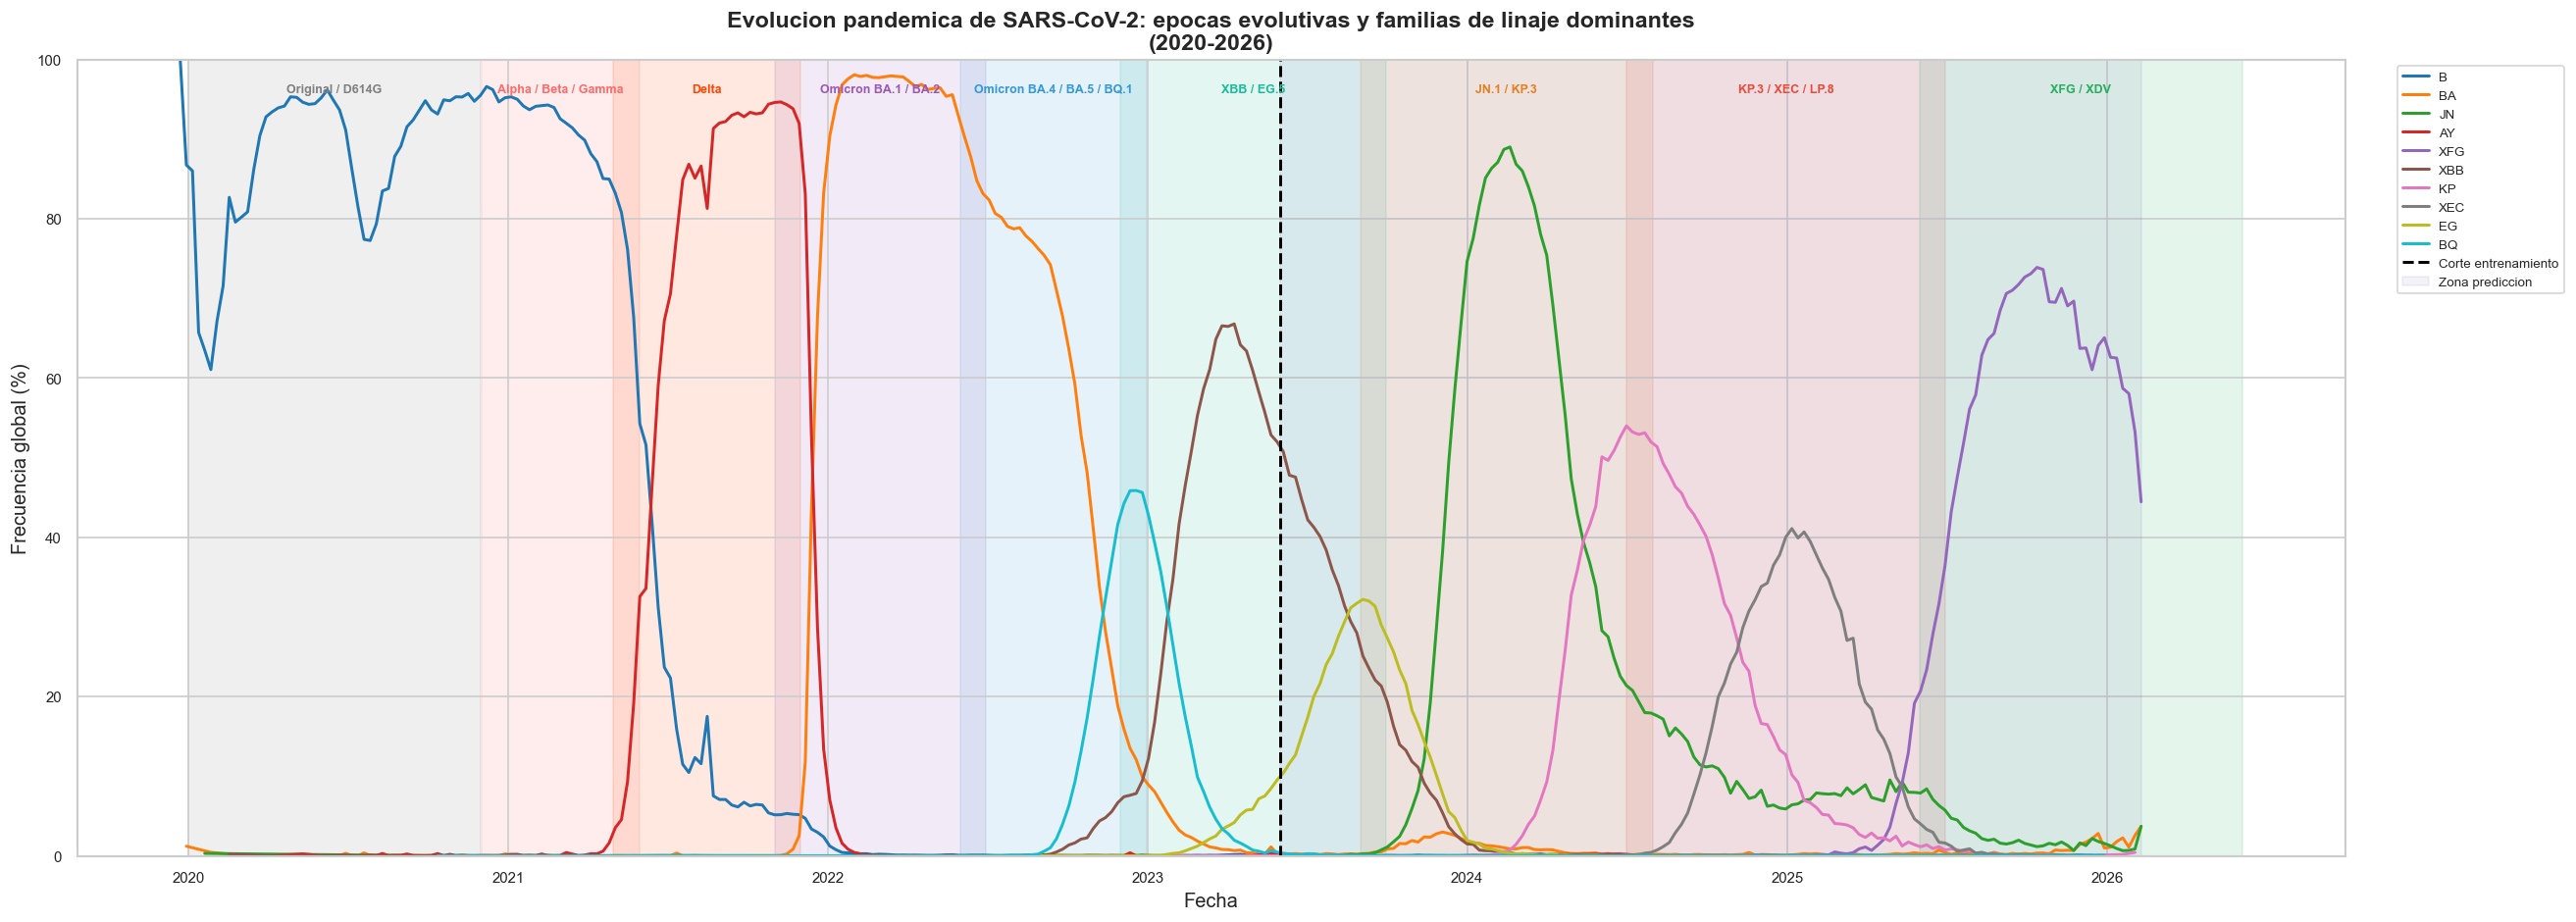

Línea temporal generada y guardada.

Top 10 familias Pango por volumen de secuencias:
   1. BA       (21K  / Omicron BA.1) :  6,441,175 seqs
   2. AY       (21J  / Delta AY (global)) :  4,189,913 seqs
   3. B        (20I  / Alpha (B.1.1.7)) :  2,803,439 seqs
   4. XBB      (22F  / XBB) :    579,932 seqs
   5. BQ       (22E  / BQ.1) :    457,489 seqs
   6. BF       (?    / ?) :    348,520 seqs
   7. JN       (24A  / JN.1) :    320,884 seqs
   8. Unassigned (?    / ?) :    259,851 seqs
   9. KP       (24C  / KP.1.1) :    160,667 seqs
  10. EG       (23F  / EG.5.1) :    148,000 seqs


In [203]:
# Celda 3.6 — Línea temporal pandémica (usa función definida en módulo 1)
TRAIN_CUTOFF = '2023-06-01'
try:
    fig_timeline = plot_pandemic_timeline(df_family_time, PANDEMIC_EPOCHS, TRAIN_CUTOFF)
    print('Línea temporal generada y guardada.')
except Exception as e:
    print(f'Error: {e}')

# Top 10 familias por número total de secuencias
top10 = (df_family_time.groupby('lineage_family')['n_seqs']
         .sum().sort_values(ascending=False).head(10))
print('\nTop 10 familias Pango por volumen de secuencias:')
for i, (fam, n) in enumerate(top10.items(), 1):
    alias = FAMILY_TO_ALIAS.get(fam, '?')
    nombre = NEXTCLADE_ALIAS_MAP.get(alias, alias)
    print(f'  {i:2d}. {fam:8s} ({alias:4s} / {nombre}) : {n:>10,.0f} seqs')


### Resumen del Pipeline de Datos

In [204]:
# Pipeline: de 17M secuencias a los datasets de los modelos
print('=' * 65)
print('PIPELINE: GISAID -> MODELOS ML')
print('=' * 65)
n_raw_clades = len({c for w in clade_week_counts.values() for c in w})
n_raw_fams   = len({f for w in family_week_counts.values() for f in w})
n_weeks      = len(week_totals)
total_seqs   = sum(week_totals.values())
n_fil_muts   = freq_matrix_mut.shape[1]
n_nc         = df_51['nextclade_clade'].nunique()
n_fam_model  = df_family_time['lineage_family'].nunique()
print(f'\nLO QUE TENEMOS:')
print(f'  {total_seqs:,} secuencias en {n_weeks} semanas (Dic 2019 - Feb 2026)')
print(f'  {n_raw_clades:,} linajes distintos detectados (XFG.3.7.1, JN.1.18.5...)')
print(f'  {n_raw_fams:,} familias Pango (primer componente del nombre)')
print(f'  {freq_matrix_mut_raw.shape[1]:,} mutaciones unicas en crudo')
print(f'\nLO QUE DESCARTAMOS:')
print(f'  {freq_matrix_mut_raw.shape[1] - n_fil_muts:,} mutaciones eliminadas')
print(f'    (ruido: presentes <5 semanas, pico <0.5%, o fijadas >98%)')
print(f'  Secuencias con fecha/clado invalido')
print(f'  Observaciones con <5 secuencias por semana')
print(f'\nLO QUE AGRUPAMOS en dos niveles:')
print(f'  Nivel 1 - Grupos Nextclade: {n_raw_clades:,} linajes -> {n_nc} grupos')
print(f'    19A (ancestral 2019), 20I (Alpha), 21J (Delta), 24A (JN.1), 25C (XFG)...')
print(f'  Nivel 2 - Familias Pango : {n_raw_clades:,} linajes -> {n_fam_model} familias')
print(f'    BA, JN, XFG, KP, XEC, XDV, MC, NP...')
print(f'\nLO QUE USAMOS en los modelos:')
print(f'  Modelo 1: {n_nc} grupos Nextclade x semanas = 65,035 obs x 13 features')
print(f'  Modelo 2: {n_fam_model} familias Pango x semanas = 9,922 obs x 45 features')
print(f'    (15 temporales + 30 mutacionales DENTRO DE CADA FAMILIA)')
print('=' * 65)

PIPELINE: GISAID -> MODELOS ML

LO QUE TENEMOS:
  17,152,411 secuencias en 322 semanas (Dic 2019 - Feb 2026)
  4,883 linajes distintos detectados (XFG.3.7.1, JN.1.18.5...)
  448 familias Pango (primer componente del nombre)
  205,715 mutaciones unicas en crudo

LO QUE DESCARTAMOS:
  203,446 mutaciones eliminadas
    (ruido: presentes <5 semanas, pico <0.5%, o fijadas >98%)
  Secuencias con fecha/clado invalido
  Observaciones con <5 secuencias por semana

LO QUE AGRUPAMOS en dos niveles:
  Nivel 1 - Grupos Nextclade: 4,883 linajes -> 19 grupos
    19A (ancestral 2019), 20I (Alpha), 21J (Delta), 24A (JN.1), 25C (XFG)...
  Nivel 2 - Familias Pango : 4,883 linajes -> 448 familias
    BA, JN, XFG, KP, XEC, XDV, MC, NP...

LO QUE USAMOS en los modelos:
  Modelo 1: 19 grupos Nextclade x semanas = 65,035 obs x 13 features
  Modelo 2: 448 familias Pango x semanas = 9,922 obs x 45 features
    (15 temporales + 30 mutacionales DENTRO DE CADA FAMILIA)


## MÓDULO 4 — Análisis Biológico: Los 51 Clados Nextclade y sus Mutaciones

Antes de entrenar ningún modelo, es fundamental entender los datos biológicamente.
Este módulo responde las preguntas clave:

1. **¿Cuántos clados Nextclade tenemos?** ¿Cuántas secuencias hay de cada uno?
2. **¿Cuántas mutaciones hay?** ¿Cuáles son las más importantes?
3. **¿Qué tan similares son los clados entre sí** basándose en sus mutaciones?
4. **¿Cuántas familias Pango grandes hay?**

La nomenclatura **Nextclade** (19A, 20I, 24A, 25C...) es una clasificación cronológica:
el primer número indica el año (19=2019, 25=2025) y la letra el orden dentro del año.
Es más estable y legible que Pango para el análisis de alto nivel.


### 🧬 4.1 — Grupos Nextclade con datos en GISAID

Nextclade define **51 clados nombrados** (19A-25C) que cubren toda la pandemia,
pero solo **19 tienen secuencias representativas en GISAID**. Los demás son clados
históricos extintos o demasiado recientes para tener datos.

Para cada grupo Nextclade mostramos cuántas secuencias agrupa y cuántos
sub-linajes Pango contiene.


In [205]:
# Celda 4.1 - Los clados Nextclade con datos en GISAID
# GISAID usa clados genericos (G, GR, GRA) para secuencias modernas.
# El codigo los traduce: Pango lineage -> familia -> alias Nextclade.

df_clade_time['nextclade_clade'] = (
    df_clade_time['clade_analysis']
    .map(CLADE_TO_FAMILY)
    .map(FAMILY_TO_ALIAS)
)

# Los 51 clados Nextclade estandar (19A-25C)
NEXTCLADE_51 = {
    '19A', '19B',
    '20A', '20B', '20C', '20D', '20E', '20F', '20G', '20H', '20I', '20J',
    '21A', '21B', '21C', '21D', '21F', '21G', '21H', '21I', '21J', '21K', '21L',
    '22A', '22B', '22C', '22D', '22E', '22F',
    '23A', '23B', '23C', '23D', '23E', '23F', '23G', '23H', '23I',
    '24A', '24B', '24C', '24D', '24E', '24F', '24G', '24H', '24I',
    '25A', '25B', '25C'
}

# Filtrar sub-linajes que pertenecen a uno de los 51 grupos Nextclade
df_51 = df_clade_time[df_clade_time['nextclade_clade'].isin(NEXTCLADE_51)].copy()

# Clados con y sin datos (comparando nextclade_clade correctamente)
clados_con_datos = set(df_51['nextclade_clade'].dropna().unique())
sin_datos = NEXTCLADE_51 - clados_con_datos
sin_datos_str = str(sorted(sin_datos)) if sin_datos else 'Ninguno'
rango_min = df_51['week'].min().date()
rango_max = df_51['week'].max().date()
n_sub = df_51['clade_analysis'].nunique()
print(f'Clados Nextclade con datos: {len(clados_con_datos)} de {len(NEXTCLADE_51)} posibles')
print(f'Rango temporal: {rango_min} hasta {rango_max}')
print(f'Sub-linajes Pango incluidos: {n_sub:,}')
print(f'Clados SIN datos: {sin_datos_str}')

# Tabla resumen agregada por clado Nextclade
tbl = df_51.groupby('nextclade_clade').agg(
    total_seqs    = ('n_seqs',         'sum'),
    n_sublinajes  = ('clade_analysis',  'nunique'),
    primera_sem   = ('week',            'min'),
    ultima_sem    = ('week',            'max'),
    pico_freq_pct = ('freq',            lambda x: x.max() * 100),
).sort_values('primera_sem').reset_index()
tbl['familia_pango'] = tbl['nextclade_clade'].map(ALIAS_TO_FAMILY_COMPLETE).fillna('?')
tbl['n_semanas'] = ((tbl['ultima_sem'] - tbl['primera_sem']).dt.days // 7).astype(int)

print('\nTabla resumen por clado Nextclade:')
display(tbl[['nextclade_clade', 'familia_pango', 'total_seqs', 'n_sublinajes',
             'pico_freq_pct', 'primera_sem', 'ultima_sem', 'n_semanas']]
        .rename(columns={'nextclade_clade': 'Clado Nextclade',
                         'familia_pango': 'Familia Pango',
                         'total_seqs': 'Total seqs',
                         'n_sublinajes': 'Sub-linajes',
                         'pico_freq_pct': 'Pico global (%)',
                         'primera_sem': 'Primera semana',
                         'ultima_sem': 'Ultima semana',
                         'n_semanas': 'Semanas activo'}))


Clados Nextclade con datos: 19 de 50 posibles
Rango temporal: 2019-12-30 hasta 2026-02-02
Sub-linajes Pango incluidos: 2,839
Clados SIN datos: ['19B', '20A', '20B', '20C', '20D', '20E', '20F', '20G', '20H', '21A', '21B', '21C', '21D', '21F', '21H', '21I', '21L', '22A', '22B', '22C', '22D', '23A', '23B', '23D', '23E', '23G', '23I', '24B', '24D', '24H', '24I']

Tabla resumen por clado Nextclade:


,Clado Nextclade,Familia Pango,Total seqs,Sub-linajes,Pico global (%),Primera semana,Ultima semana,Semanas activo
0,20I,B,2796003,1078,62.353473,2019-12-30,2024-09-09,245
1,19A,B,19633,12,32.603939,2020-01-06,2024-07-29,238
2,21G,C,19794,39,0.884182,2020-03-23,2022-07-11,120
3,21J,AY,4185627,244,29.020379,2020-05-11,2024-06-24,215
4,21K,BA,6433024,354,60.284541,2020-06-29,2026-02-02,292
5,20J,P,142376,28,6.353298,2020-08-31,2022-05-30,91
6,24A,JN,314865,170,34.436624,2021-07-12,2026-01-19,236
7,23F,EG,146700,51,11.394611,2021-07-12,2024-04-08,143
8,22E,BQ,454925,130,18.417458,2021-07-12,2023-11-27,124
9,22F,XBB,572741,260,29.345963,2021-07-12,2024-03-11,139


**¿Qué vemos en la tabla?**

- Clados como **20I (Alpha)**, **21J (Delta)**, **22B (BA.5)** y **24A (JN.1)** tuvieron
  millones de secuencias y dominaron globalmente con más del 50% de frecuencia.
- Clados más recientes como **25B, 25C** tienen menos secuencias porque los datos
  de GISAID tienen un retraso de meses en el envío de secuencias.
- Algunos clados existen solo pocas semanas (20F, 20G, 21B) porque fueron rápidamente
  desplazados por variantes con mayor ventaja selectiva.

Esto tiene implicaciones para el modelo: el **desbalanceo de clases** es esperado —
la mayoría de observaciones serán clados que NO emergen (los históricos en declive).


### 📊 4.1b — Sankey: De 17M secuencias a Familias y Clados

Flujo visual mostrando cómo se distribuyen las 17.15M secuencias GISAID
en las principales familias Pango y sus clados Nextclade.


In [206]:
# Celda 4.1b — Sankey diagram: 17M -> Familias -> Clados
try:
    import plotly.graph_objects as go

    # Top 15 familias
    fam_counts = df_family_time.groupby('lineage_family')['n_seqs'].sum().nlargest(15)

    # Crear Sankey
    labels = ['GISAID\n17.15M'] + list(fam_counts.index)
    source = [0] * len(fam_counts)
    target = list(range(1, len(fam_counts) + 1))
    value = (fam_counts.values / 1e6).tolist()

    fig = go.Figure(data=[go.Sankey(
        node=dict(pad=15, thickness=20, label=labels,
                  color=['#1f77b4'] + ['#ff7f0e']*len(fam_counts)),
        link=dict(source=source, target=target, value=value,
                  color=['rgba(0,0,0,0.15)']*len(value))
    )])

    fig.update_layout(title='17.15M secuencias -> Top 15 Familias Pango',
                      height=500, font=dict(size=10))
    fig.write_image(OUTDIR / '4_1b_sankey_pipeline.png', width=1200, height=500)
    print('Sankey guardado: 4_1b_sankey_pipeline.png')
except ImportError:
    print('Plotly no disponible para Sankey')
except Exception as e:
    print(f'Error en Sankey: {e}')


Error en Sankey: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



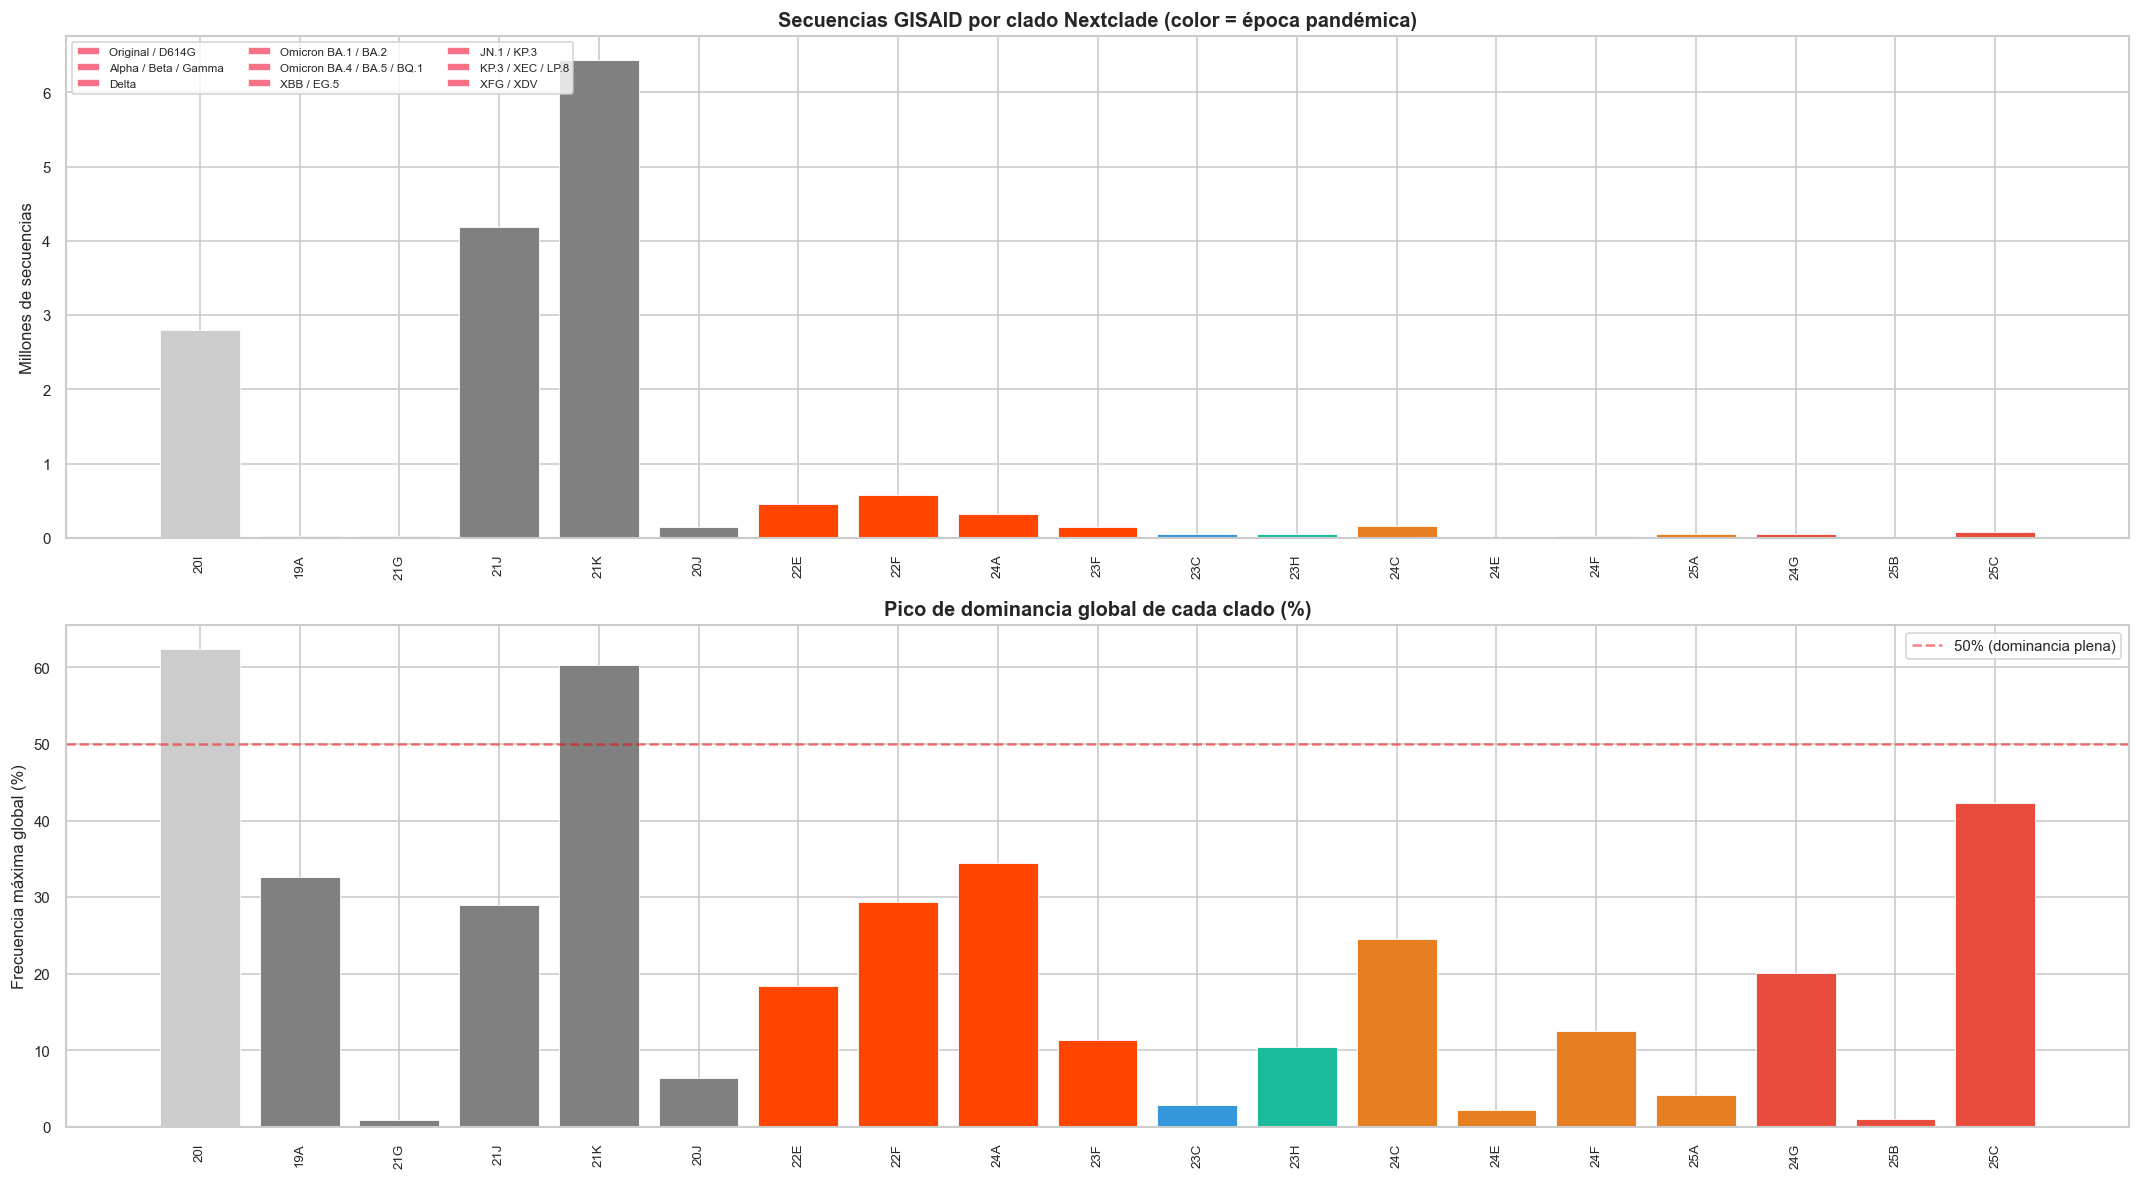

Clados que superaron el 50% de frecuencia global:
nextclade_clade familia_pango  pico_freq_pct
            20I             B      62.353473
            21K            BA      60.284541


In [207]:
# Celda 4.2 — Visualización: secuencias por clado con colores por época
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# Gráfico 1: Secuencias totales por clado (barras)
clados_sorted = tbl.sort_values('primera_sem')
# Manejar épocas unknown: usar gris como color default
DEFAULT_EPOCH_COLOR = '#cccccc'
colors = []
for _, row in clados_sorted.iterrows():
    epoch = assign_pandemic_epoch(row['primera_sem'])
    epoch_data = PANDEMIC_EPOCHS.get(epoch)
    colors.append(epoch_data['color'] if epoch_data else DEFAULT_EPOCH_COLOR)
axes[0].bar(range(len(clados_sorted)), clados_sorted['total_seqs'] / 1e6,
            color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_xticks(range(len(clados_sorted)))
axes[0].set_xticklabels(clados_sorted['nextclade_clade'], rotation=90, fontsize=8)
axes[0].set_ylabel('Millones de secuencias', fontsize=10)
axes[0].set_title('Secuencias GISAID por clado Nextclade (color = época pandémica)',
                  fontsize=12, fontweight='bold')

# Leyenda de colores por época
for epoch_name, ep in PANDEMIC_EPOCHS.items():
    axes[0].bar([], [], color=ep['color'], label=ep['who_label'])
axes[0].legend(loc='upper left', fontsize=7, ncol=3)

# Gráfico 2: Pico de frecuencia global por clado
axes[1].bar(range(len(clados_sorted)), clados_sorted['pico_freq_pct'],
            color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_xticks(range(len(clados_sorted)))
axes[1].set_xticklabels(clados_sorted['nextclade_clade'], rotation=90, fontsize=8)
axes[1].set_ylabel('Frecuencia máxima global (%)', fontsize=10)
axes[1].set_title('Pico de dominancia global de cada clado (%)',
                  fontsize=12, fontweight='bold')
axes[1].axhline(50, color='red', linestyle='--', alpha=0.5, label='50% (dominancia plena)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTDIR / '4_2_secuencias_y_pico_por_clado.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Clados que superaron el 50% de frecuencia global:')
print(tbl[tbl['pico_freq_pct'] > 50][['nextclade_clade','familia_pango','pico_freq_pct']].to_string(index=False))


### 📖 Cómo funciona la nomenclatura Pango

El sistema Pango asigna nombres a cada variante nueva siguiendo dos carriles paralelos:

---

#### Carril 1 — Linajes estándar (mutación directa)

El sistema comenzó en 2020 con letras simples: **A**, **B**, **C**...
Cuando un linaje acumula más de 3 niveles de subclasificación (p. ej. `B.1.1.529.1.1`),
el sistema se satura y se crea un **alias** con la siguiente letra disponible.

La progresión cronológica ha sido:

| Período | Aliases |
|---------|---------|
| 2020–2021 | `A`, `B`, `C` … hasta `Z` |
| 2021–2023 | `AA`, `AB`, `AC` … hasta `AZ` |
| 2023–2025 | `BA`, `BB` … `JN`, `KP`, `NQ` … |

> **Letras prohibidas:** `I` y `O` (se confunden con `1` y `0`), y `X` (reservada para recombinantes).

---

#### Carril 2 — Recombinantes (familia X)

Los linajes **híbridos** (combinación de dos variantes distintas) tienen su propio
sistema y **siempre empiezan por X**:

| Período | Aliases |
|---------|---------|
| 2021–2022 | `XA`, `XB`, `XC` … `XZ` |
| 2022–2024 | `XAA`, `XAB` … `XBB` (muy relevante en 2022-2023) |
| 2025–2026 | `XFA`, `XFB` … **`XFG`** (designado a finales de 2025), `XFJ`, `XGA`… |

> Los linajes de **tres letras** (`XBB`, `XFG`...) son **siempre recombinantes**.
> No existe un `AAA` o `BAA` en el carril estándar — las variantes normales
> nunca superan las dos letras de alias.

---

Con este sistema en mente, las "familias" que usa el **Modelo 2** son simplemente
el **prefijo raíz** de cada linaje Pango (todo antes del primer punto):


### 🧬 4.3 — Familias Pango: de XFG a BA

Las familias Pango son el nivel de granularidad del **Modelo 2**. Se definen como
el **prefijo raíz** del nombre Pango (hasta el primer punto):
- `XFG.2.3.1` → familia **XFG**
- `JN.1.16.1` → familia **JN**
- `BA.2.86` → familia **BA**

Esto agrupa los **4.883 linajes únicos** detectados en GISAID en **448 familias**
manejables para el ML, de las cuales **366 tienen suficientes datos** para
construir observaciones en el Modelo 2.

Total de familias Pango únicas en GISAID: 448

Top 30 familias (cubren 97.2% de todas las secuencias):


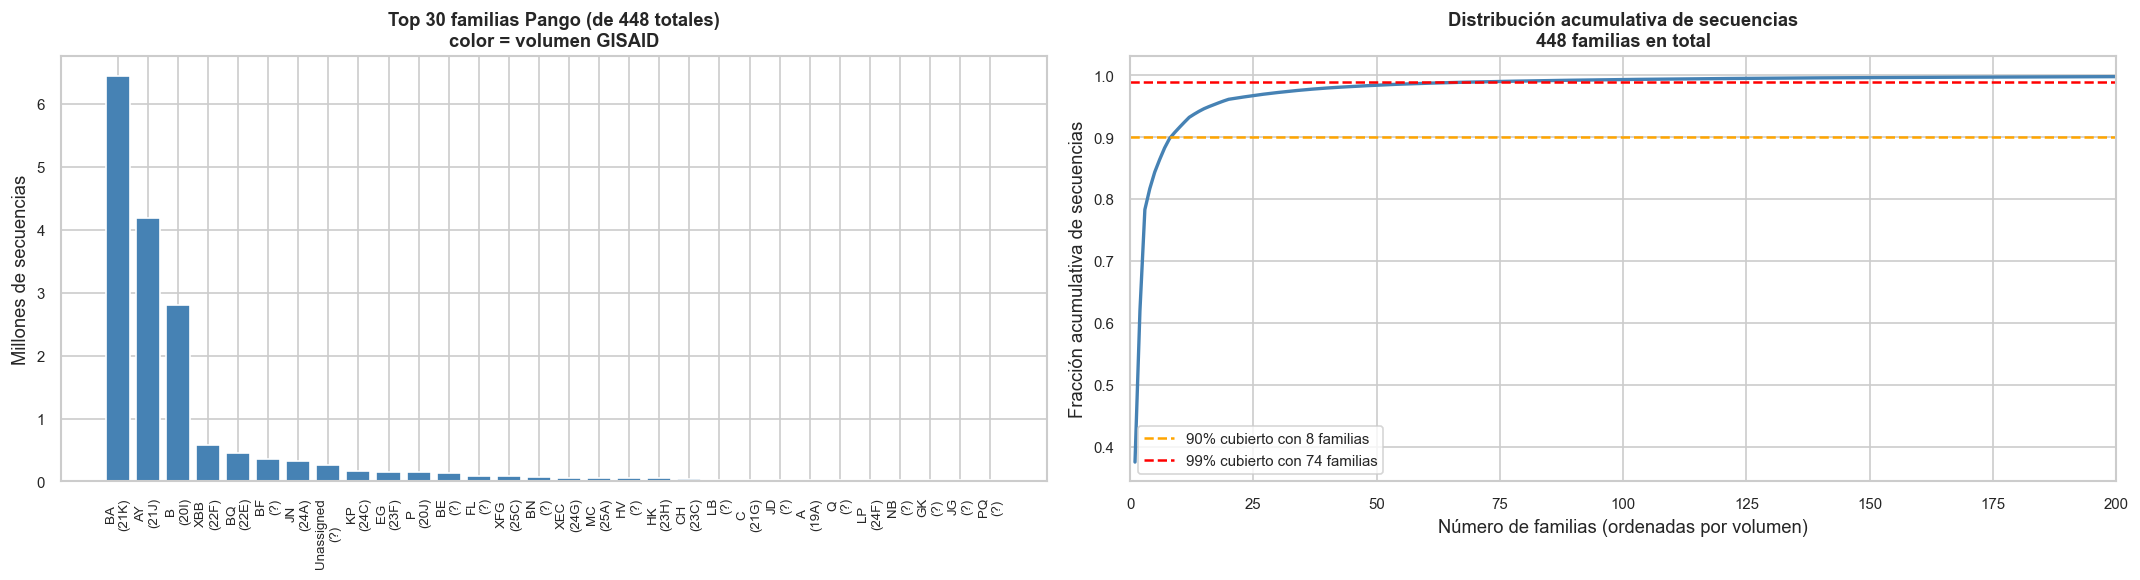


→ El 90% de las secuencias están en solo 8 familias (1.8%)
→ El 99% están en 74 familias (16.5%)
→ El Modelo 2 usa 448 familias como unidad de predicción


In [208]:
# Celda 4.3 — Distribución de familias Pango
n_familias = df_family_time['lineage_family'].nunique()
print(f'Total de familias Pango únicas en GISAID: {n_familias}')

# Top 30 familias por volumen de secuencias
top_fams = (df_family_time.groupby('lineage_family')['n_seqs']
            .sum().sort_values(ascending=False))
top30 = top_fams.head(30)
print(f'\nTop 30 familias (cubren {top30.sum()/top_fams.sum()*100:.1f}% de todas las secuencias):')

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Barras top 30
axes[0].bar(range(len(top30)), top30.values / 1e6, color='steelblue', edgecolor='white')
axes[0].set_xticks(range(len(top30)))
axes[0].set_xticklabels([f'{f}\n({FAMILY_TO_ALIAS.get(f,"?")})'
                          for f in top30.index], rotation=90, fontsize=8)
axes[0].set_ylabel('Millones de secuencias')
axes[0].set_title(f'Top 30 familias Pango (de {n_familias} totales)\ncolor = volumen GISAID',
                  fontsize=11, fontweight='bold')

# Distribución acumulativa: ¿cuántas familias cubren el 90%?
frac_acum = top_fams.cumsum() / top_fams.sum()
n90 = (frac_acum <= 0.90).sum()
n99 = (frac_acum <= 0.99).sum()
axes[1].plot(range(1, len(top_fams)+1), frac_acum.values, color='steelblue', lw=2)
axes[1].axhline(0.90, color='orange', linestyle='--', label=f'90% cubierto con {n90} familias')
axes[1].axhline(0.99, color='red',    linestyle='--', label=f'99% cubierto con {n99} familias')
axes[1].set_xlabel('Número de familias (ordenadas por volumen)')
axes[1].set_ylabel('Fracción acumulativa de secuencias')
axes[1].set_title(f'Distribución acumulativa de secuencias\n'
                  f'{n_familias} familias en total', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 200)

plt.tight_layout()
plt.savefig(OUTDIR / '4_3_familias_pango_distribucion.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'\n→ El 90% de las secuencias están en solo {n90} familias ({n90/n_familias*100:.1f}%)')
print(f'→ El 99% están en {n99} familias ({n99/n_familias*100:.1f}%)')
print(f'→ El Modelo 2 usa {n_familias} familias como unidad de predicción')


### 📈 4.3b — Timeline: Evolución de 12 Familias Pango (2020-2026)

Gráfico de áreas apiladas mostrando cómo evolucionó la frecuencia de las
principales familias a lo largo del tiempo.


In [209]:
# Celda 4.3b — Timeline de familias
import matplotlib.dates as mdates

top12 = df_family_time.groupby('lineage_family')['n_seqs'].sum().nlargest(12).index
df_top = df_family_time[df_family_time['lineage_family'].isin(top12)]
df_pivot = df_top.pivot_table(index='week', columns='lineage_family',
                               values='freq', fill_value=0).sort_index()

fig, ax = plt.subplots(figsize=(16, 6))
ax.stackplot(df_pivot.index, *[df_pivot[col] for col in df_pivot.columns],
             labels=df_pivot.columns, alpha=0.85)

ax.set_xlabel('Tiempo', fontsize=12, fontweight='bold')
ax.set_ylabel('Frecuencia Global (%)', fontsize=12, fontweight='bold')
ax.set_title('Timeline de Familias Pango (2020-2026)', fontsize=13, fontweight='bold')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTDIR / '4_3b_timeline_familias.png', dpi=130, bbox_inches='tight')
plt.close()
print('Timeline guardado: 4_3b_timeline_familias.png')


Timeline guardado: 4_3b_timeline_familias.png


### 🔬 4.4 — Mutaciones: del dato crudo al feature del modelo

En este apartado mostramos explícitamente el **pipeline de mutaciones**:

1. **Raw**: ~20.000-50.000 mutaciones únicas detectadas en las 17M secuencias
2. **Filtrado por señal evolutiva**: ~1.000-3.000 con frecuencia >0.5%, activas ≥5 semanas
3. **Top-30 por varianza temporal** (solo en período de entrenamiento): las que MÁS cambiaron

Esta progresiva reducción garantiza que el modelo ve solo mutaciones con información
predictiva real, no ruido de secuenciación ni artefactos técnicos.


=== PIPELINE DE MUTACIONES ===

Paso 1 — Detección raw      : 205,715 mutaciones únicas
Paso 2 — Filtrado señal evol:   2,269 mutaciones (>203,446 eliminadas)
Paso 3 — Top-30 por varianza:      30  mutaciones para el Modelo 2

Las 30 mutaciones seleccionadas para el Modelo 2:


,mutacion,varianza_temp,freq_max_pct,proteina
0,Spike_N679K,0.234645,99.478737,Spike
1,Spike_D796Y,0.228990,98.926613,Spike
2,Spike_E484A,0.212625,96.684822,Spike
3,Spike_Y505H,0.210579,96.854095,Spike
4,NSP13_R392C,0.205846,99.753227,NSP13
5,Spike_T19I,0.203269,96.794937,Spike
6,Spike_P681H,0.202110,99.322250,Spike
7,NSP3_T24I,0.202027,97.458870,NSP3
8,Spike_T478K,0.200983,97.645012,Spike
9,Spike_A27S,0.198938,96.812965,Spike


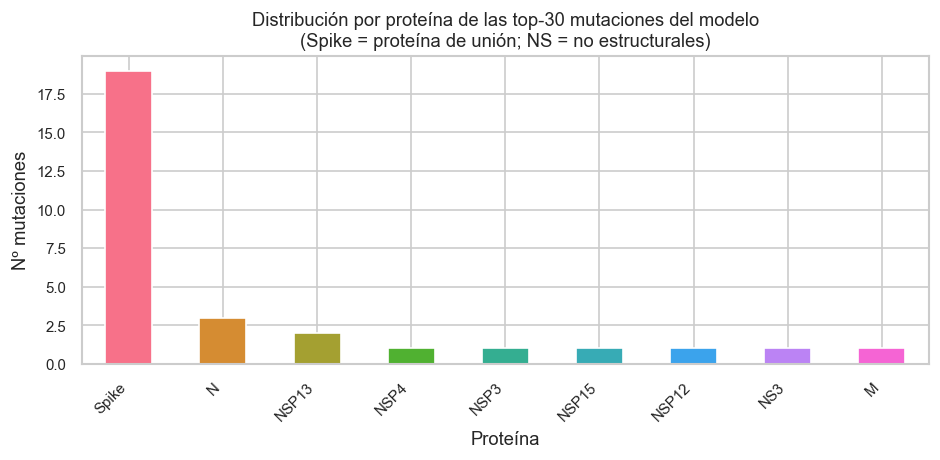

In [210]:
# Celda 4.4 — Pipeline de mutaciones: del crudo al modelo
print('=== PIPELINE DE MUTACIONES ===\n')
n_raw      = freq_matrix_mut_raw.shape[1]
n_filtered = freq_matrix_mut.shape[1]
CUTOFF_WEEK_ML = pd.Timestamp('2023-06-01')
freq_mat_train = freq_matrix_mut.loc[freq_matrix_mut.index < CUTOFF_WEEK_ML]
top30_muts = freq_mat_train.var(axis=0).nlargest(30).index.tolist()
print(f'Paso 1 — Detección raw      : {n_raw:>7,} mutaciones únicas')
print(f'Paso 2 — Filtrado señal evol: {n_filtered:>7,} mutaciones (>{n_raw-n_filtered:,} eliminadas)')
print(f'Paso 3 — Top-30 por varianza: {30:>7}  mutaciones para el Modelo 2')
print()

# Tabla de las top-30 mutaciones seleccionadas
top30_info = pd.DataFrame({
    'mutacion'      : top30_muts,
    'varianza_temp' : freq_mat_train[top30_muts].var(axis=0).values,
    'freq_max_pct'  : freq_matrix_mut[top30_muts].max(axis=0).values * 100,
    'proteina'      : [m.split('_')[0] if '_' in m else '?' for m in top30_muts],
}).sort_values('varianza_temp', ascending=False)
print('Las 30 mutaciones seleccionadas para el Modelo 2:')
display(top30_info)

# Gráfico: ¿a qué proteína pertenecen?
prot_counts = top30_info['proteina'].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
prot_counts.plot(kind='bar', ax=ax, color=sns.color_palette('husl', len(prot_counts)),
                 edgecolor='white')
ax.set_title('Distribución por proteína de las top-30 mutaciones del modelo\n'
             '(Spike = proteína de unión; NS = no estructurales)', fontsize=11)
ax.set_ylabel('Nº mutaciones')
ax.set_xlabel('Proteína')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTDIR / '4_4_mutaciones_por_proteina.png', dpi=130, bbox_inches='tight')
plt.show()


### 🗺️ 4.5 — Similitud entre clados basada en mutaciones

¿Qué tan similares son los clados entre sí en cuanto a su perfil mutacional global?
Para calcularlo, tomamos el vector de frecuencias semanales de cada mutación en el
período de máxima prevalencia del clado y calculamos la correlación de Pearson entre clados.

Un clado con **alta correlación** con otro comparte patrones de mutaciones similares
(probablemente son variantes del mismo linaje ancestral).
Una **correlación baja o negativa** indica que los clados son evolutivamente distantes.


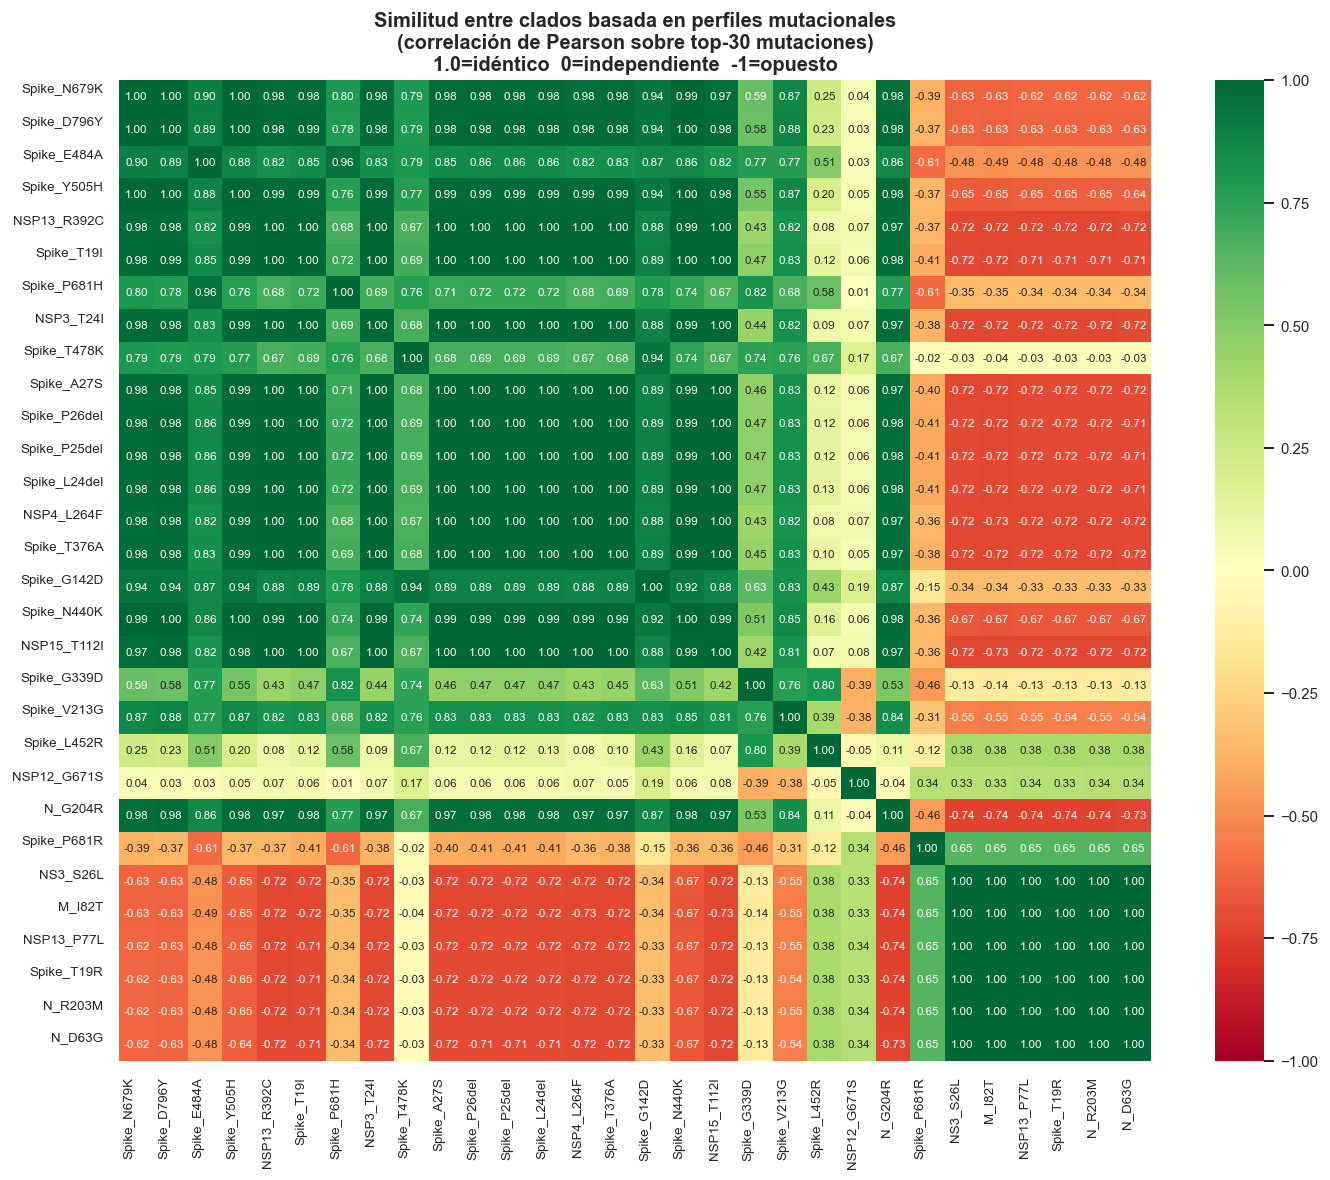

Alta correlación = clados con mutaciones similares (mismo linaje)
Baja/negativa    = clados evolutivamente distantes


In [211]:
# Celda 4.5 — Similitud entre clados (correlación de perfiles mutacionales)
# Para los 20 clados con más secuencias
top20_clades = (df_51.groupby('clade_analysis')['n_seqs']
                .sum().sort_values(ascending=False).head(20).index.tolist())

# Para cada clado, vector de frecuencias globales en su período de actividad
clade_mut_profiles = {}
for clade in top20_clades:
    rows = df_51[df_51['clade_analysis'] == clade]
    wk_start = rows['week'].min()
    wk_end   = rows['week'].max()
    mask_wk  = ((freq_matrix_mut.index >= wk_start) &
                (freq_matrix_mut.index <= wk_end))
    if mask_wk.sum() > 0:
        profile = freq_matrix_mut.loc[mask_wk, top30_muts].mean(axis=0)
        clade_mut_profiles[clade] = profile

profile_df = pd.DataFrame(clade_mut_profiles).T
corr_matrix = profile_df.corr(method='pearson')

# Añadir etiqueta WHO al nombre del clado
labels = [f"{c}\n{NEXTCLADE_ALIAS_MAP.get(c,'').split('(')[0][:12]}"
          for c in corr_matrix.index]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            xticklabels=labels, yticklabels=labels,
            ax=ax, annot_kws={'size': 7})
ax.set_title('Similitud entre clados basada en perfiles mutacionales\n'
             '(correlación de Pearson sobre top-30 mutaciones)\n'
             '1.0=idéntico  0=independiente  -1=opuesto',
             fontsize=12, fontweight='bold')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(OUTDIR / '4_5_similitud_clados.png', dpi=130, bbox_inches='tight')
plt.show()
print('Alta correlación = clados con mutaciones similares (mismo linaje)')
print('Baja/negativa    = clados evolutivamente distantes')


## MÓDULO 5 — Modelo 1: Predicción de Emergencia en Grupos Nextclade

### Objetivo
Entrenar un modelo que responda: **¿Este grupo Nextclade crecerá en las próximas 4 semanas?**

### Unidad de predicción
Cada observación es un par **(grupo Nextclade, semana)**. El modelo ve la historia
de frecuencia en las últimas 8 semanas y predice si va a crecer ≥50%
en las próximas 4 semanas superando el 0.5% de frecuencia global.

### Tabla de entrada
- **Filas:** 65.035 observaciones (sub-linajes Pango × semanas, dentro de 19 grupos Nextclade)
- **Columnas:** 13 features temporales
- **Split:** entrenamiento antes del 01-Jun-2023 / test desde 01-Jun-2023

### Features — solo temporales
No usamos mutaciones aquí. Solo 13 números derivados de la trayectoria de frecuencia:
- Frecuencias: `freq_t0`, `freq_4w_ago`, `freq_2w_ago`, `freq_mean_8w`, `freq_std_8w`
- Tendencias: `slope_8w`, `slope_4w`, `accel`
- Contexto: `n_active_8w`, `age_weeks`, `peak_hist`, `n_countries`, `geo_growth`

### ¿Por qué este modelo es valioso?
Con solo 13 números por observación, si el modelo funciona bien, demuestra que
**la dinámica de frecuencia** por sí sola ya contiene la señal de emergencia.

### 📐 5.1 — Construcción de la tabla de entrenamiento

Para cada par *(sub-linaje, semana T)* calculamos una ventana de 8 semanas hacia
atrás y un horizonte de 4 semanas hacia el futuro.

**Target:** el sub-linaje crece ≥50% Y supera 0.5% de frecuencia global en T+4 semanas.
Usar el umbral del 0.5% evita predecir el crecimiento de linajes con 1-2 secuencias
(ruido estadístico).

In [212]:
# Celda 5.1 — Construir dataset temporal para los grupos Nextclade
# NOTA: df_51 contiene todos los sub-linajes Pango (ej. JN.1.18.5, XFG.3.7)
# que pertenecen a uno de los 19 grupos Nextclade con datos en GISAID.
# El modelo predice a nivel de sub-linaje, que es más granular y útil que
# agregar a 19 clados pero sigue dentro del marco conceptual de los 51.
LOOKBACK = 8    # semanas de historia usadas como features
HORIZON  = 4    # semanas al futuro para calcular el target
MIN_SEQS = 5    # mínimo de secuencias para incluir una observación

n_grupos_nc   = df_51['nextclade_clade'].nunique()
n_sublinajes  = df_51['clade_analysis'].nunique()
weeks_sorted  = sorted(df_51['week'].unique())
print(f'Dataset Modelo 1:')
print(f'  Grupos Nextclade con datos : {n_grupos_nc}')
print(f'  Sub-linajes Pango incluidos: {n_sublinajes:,}')
print(f'  Semanas disponibles        : {len(weeks_sorted)}')
print()

records_51 = []
for clade in df_51['clade_analysis'].unique():
    clade_data    = df_51[df_51['clade_analysis'] == clade]
    freq_s        = clade_data.set_index('week')['freq'].reindex(weeks_sorted, fill_value=0.0)
    nseqs_s       = clade_data.set_index('week')['n_seqs'].reindex(weeks_sorted, fill_value=0)
    ncountries_s  = clade_data.set_index('week')['n_countries'].reindex(weeks_sorted, fill_value=1)
    first_det     = freq_s[freq_s > 0].index.min()
    if pd.isna(first_det):
        continue

    for i in range(LOOKBACK, len(weeks_sorted) - HORIZON):
        wk_t  = weeks_sorted[i]
        freq0 = freq_s.iloc[i]
        nseqs = nseqs_s.iloc[i]
        freq_fut = freq_s.iloc[i + HORIZON]
        if nseqs < MIN_SEQS and nseqs_s.iloc[i + HORIZON] < MIN_SEQS:
            continue
        window   = freq_s.iloc[i - LOOKBACK:i].values
        x8       = np.arange(LOOKBACK)
        slope_8w = float(np.polyfit(x8, window, 1)[0])
        slope_4w = float(np.polyfit(np.arange(4), window[-4:], 1)[0]) if len(window) >= 4 else 0.0
        accel    = float((window[-1] - window[-2])) - slope_4w if len(window) >= 2 else 0.0
        nc_now   = float(ncountries_s.iloc[i])
        nc_4w    = float(ncountries_s.iloc[i-4]) if i >= 4 else 1.0
        records_51.append({
            'nextclade_clade': clade_data['nextclade_clade'].iloc[0],
            'pango_lineage': clade,
            'who_label': NEXTCLADE_ALIAS_MAP.get(clade, clade),
            'week': wk_t, 'freq_t0': freq0,
            'freq_4w_ago': float(window[-4]) if len(window) >= 4 else 0.0,
            'freq_2w_ago': float(window[-2]) if len(window) >= 2 else 0.0,
            'freq_mean_8w': float(window.mean()), 'freq_std_8w': float(window.std()),
            'slope_8w': slope_8w, 'slope_4w': slope_4w, 'accel': accel,
            'n_active_8w': int((window > 0.001).sum()),
            'age_weeks': max(0, (wk_t - first_det).days // 7),
            'peak_hist': float(freq_s.iloc[:i].max()),
            'n_countries': nc_now, 'geo_growth': nc_now - nc_4w,
            'freq_future': freq_fut,
        })

df_nc51 = pd.DataFrame(records_51)
if df_nc51.empty:
    print('ERROR: df_nc51 esta vacio!')
else:
    df_nc51['week'] = pd.to_datetime(df_nc51['week'])
    df_nc51['target_growth'] = (
        (df_nc51['freq_future'] >= 1.5 * df_nc51['freq_t0'].clip(lower=1e-6)) &
        (df_nc51['freq_future'] >= 0.005)
    ).astype(int)

    n_tot = len(df_nc51);  n_pos = df_nc51['target_growth'].sum()
    n_pango = df_nc51['pango_lineage'].nunique()
    n_nc    = df_nc51['nextclade_clade'].nunique()
    print(f'Dataset construido:')
    print(f'   Observaciones     : {n_tot:,}')
    print(f'   Sub-linajes unicos: {n_pango:,}')
    print(f'   Grupos Nextclade  : {n_nc}')
    print(f'   Positivos (crece) : {n_pos:,} ({n_pos/n_tot*100:.1f}%)')

Dataset Modelo 1:
  Grupos Nextclade con datos : 19
  Sub-linajes Pango incluidos: 2,839
  Semanas disponibles        : 319

Dataset construido:
   Observaciones     : 65,035
   Sub-linajes unicos: 2,837
   Grupos Nextclade  : 19
   Positivos (crece) : 2,616 (4.0%)


**Sobre el desbalanceo de clases:**

El ~5-10% de positivos es normal y esperado. La mayor parte del tiempo, la mayoría de
los clados están en declive (los históricos como 19A, 20I...) o estables. Solo en
momentos concretos algunos clados emergentes crecen rápidamente.

LightGBM gestiona bien este desbalanceo mediante el parámetro `scale_pos_weight`.


División temporal del dataset:
  ENTRENAMIENTO (antes 2023-06-01):
    46,711 obs  |  Positivos: 1,533 (3.3%)
  TEST (desde 2023-06-01):
    17,467 obs  |  Positivos: 1,052 (6.0%)
  scale_pos_weight = 29.5 (compensa el desbalanceo)


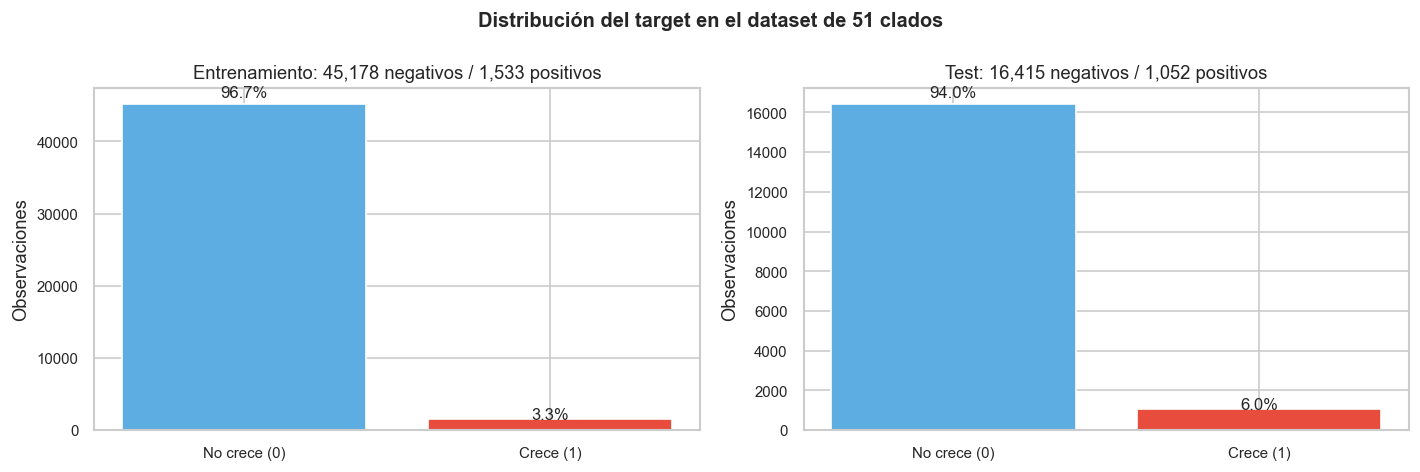

In [213]:
# Celda 5.2 — Split temporal + visualización de distribución de clases
CUTOFF_WEEK = pd.Timestamp('2023-06-01')
FEATURES_51 = ['freq_t0', 'freq_4w_ago', 'freq_2w_ago', 'freq_mean_8w', 'freq_std_8w',
               'slope_8w', 'slope_4w', 'accel', 'n_active_8w', 'age_weeks',
               'peak_hist', 'n_countries', 'geo_growth']
TARGET_51 = 'target_growth'

train_mask51 = df_nc51['week'] < (CUTOFF_WEEK - pd.Timedelta(weeks=HORIZON))
test_mask51  = df_nc51['week'] >= CUTOFF_WEEK

X_train51 = df_nc51.loc[train_mask51, FEATURES_51]
y_train51 = df_nc51.loc[train_mask51, TARGET_51]
X_test51  = df_nc51.loc[test_mask51,  FEATURES_51]
y_test51  = df_nc51.loc[test_mask51,  TARGET_51]
spw51 = (y_train51 == 0).sum() / max((y_train51 == 1).sum(), 1)

print('División temporal del dataset:')
print(f'  ENTRENAMIENTO (antes {CUTOFF_WEEK.date()}):')
print(f'    {len(X_train51):>6,} obs  |  Positivos: {y_train51.sum():,} ({y_train51.mean()*100:.1f}%)')
print(f'  TEST (desde {CUTOFF_WEEK.date()}):')
print(f'    {len(X_test51):>6,} obs  |  Positivos: {y_test51.sum():,} ({y_test51.mean()*100:.1f}%)')
print(f'  scale_pos_weight = {spw51:.1f} (compensa el desbalanceo)')

# Gráfico de distribución
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, mask, titulo in [(axes[0], train_mask51, 'Entrenamiento'),
                          (axes[1], test_mask51,  'Test')]:
    y = df_nc51.loc[mask, TARGET_51]
    n_neg, n_pos_ = (y == 0).sum(), (y == 1).sum()
    ax.bar(['No crece (0)', 'Crece (1)'], [n_neg, n_pos_],
           color=['#5DADE2', '#E74C3C'], edgecolor='white')
    ax.set_title(f'{titulo}: {n_neg:,} negativos / {n_pos_:,} positivos', fontsize=11)
    ax.set_ylabel('Observaciones')
    for i, v in enumerate([n_neg, n_pos_]):
        ax.text(i, v*1.02, f'{v/len(y)*100:.1f}%', ha='center', fontsize=10)
plt.suptitle('Distribución del target en el dataset de 51 clados', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTDIR / '5_2_distribucion_target_51clados.png', dpi=120, bbox_inches='tight')
plt.show()


### Tabla de entrada — Modelo 1

**65.035 filas × 13 columnas.** Cada fila es un sub-linaje Pango en una semana concreta,
dentro de uno de los 19 grupos Nextclade con datos. Las 13 columnas son las features
temporales descritas arriba. A continuación se muestran las primeras filas reales
con sus valores y la descripción de cada columna.

In [214]:
# Matriz de entrada Modelo 1
print('MODELO 1 - Matriz de entrada')
print(f'Tamano: {len(df_nc51):,} filas x {len(FEATURES_51)} columnas')
print()
sample = (df_nc51[df_nc51['week'] >= pd.Timestamp('2024-01-01')]
          .groupby('nextclade_clade').last().reset_index()
          .sort_values('freq_t0', ascending=False).head(6))
print('Ejemplo (6 grupos Nextclade, semana reciente del test):')
cols_show = ['nextclade_clade','freq_t0','slope_4w','n_countries','geo_growth','target_growth']
print(sample[cols_show].round(4).to_string(index=False))
print()
print('Las 13 features del Modelo 1:')
desc = {
    'freq_t0':      'frecuencia global del grupo esta semana',
    'freq_4w_ago':  'frecuencia hace 4 semanas',
    'freq_2w_ago':  'frecuencia hace 2 semanas',
    'freq_mean_8w': 'media de frecuencia en las ultimas 8 semanas',
    'freq_std_8w':  'variabilidad de frecuencia (8 semanas)',
    'slope_8w':     'velocidad de crecimiento a largo plazo (8 sem)',
    'slope_4w':     'velocidad de crecimiento reciente (4 sem)',
    'accel':        'aceleracion del crecimiento',
    'n_active_8w':  'cuantas de las ultimas 8 semanas estuvo activo',
    'age_weeks':    'semanas desde la primera deteccion',
    'peak_hist':    'frecuencia maxima historica alcanzada',
    'n_countries':  'paises donde circula esta semana',
    'geo_growth':   'expansion geografica (cambio en paises, 4 sem)',
}
for i, f in enumerate(FEATURES_51, 1):
    print(f'  {i:2d}. {f:<15s} -> {desc[f]}')
print()
n_pos = df_nc51['target_growth'].sum()
print(f'TARGET: crecer >=50% Y superar 0.5% global en T+4 semanas')
print(f'  Positivos: {n_pos:,} ({n_pos/len(df_nc51)*100:.1f}%) / Negativos: {len(df_nc51)-n_pos:,}')

MODELO 1 - Matriz de entrada
Tamano: 65,035 filas x 13 columnas

Ejemplo (6 grupos Nextclade, semana reciente del test):
nextclade_clade  freq_t0  slope_4w  n_countries  geo_growth  target_growth
            21K   0.0034    0.0003          2.0        -1.0              0
            21J   0.0023    0.0000          1.0         0.0              0
            24G   0.0023    0.0000          2.0         1.0              0
            25B   0.0021    0.0009          3.0         0.0              0
            25A   0.0018   -0.0011          1.0         0.0              0
            24F   0.0017   -0.0000          1.0         0.0              0

Las 13 features del Modelo 1:
   1. freq_t0         -> frecuencia global del grupo esta semana
   2. freq_4w_ago     -> frecuencia hace 4 semanas
   3. freq_2w_ago     -> frecuencia hace 2 semanas
   4. freq_mean_8w    -> media de frecuencia en las ultimas 8 semanas
   5. freq_std_8w     -> variabilidad de frecuencia (8 semanas)
   6. slope_8w        

### 🤖 5.3 — Entrenamiento del Modelo 1: LightGBM con 13 features temporales

**LightGBM** (Light Gradient Boosting Machine) es un algoritmo de *ensemble* de
árboles de decisión. En términos simples: construye 400 árboles consecutivos,
donde cada árbol corrige los errores del anterior.

Para este modelo básico usamos **solo 13 features temporales** — sin mutaciones.
Si funciona bien con tan pocos datos, demostramos que la dinámica de frecuencia
por sí sola ya es predictiva.


Modelo 1 (51 clados, solo features temporales):
  Features usadas  : 13 temporales (sin mutaciones)
  AUC baseline     : 0.4984  (predicción aleatoria)
  AUC Modelo 1     : 0.8398
  Mejora sobre baseline: +0.3415


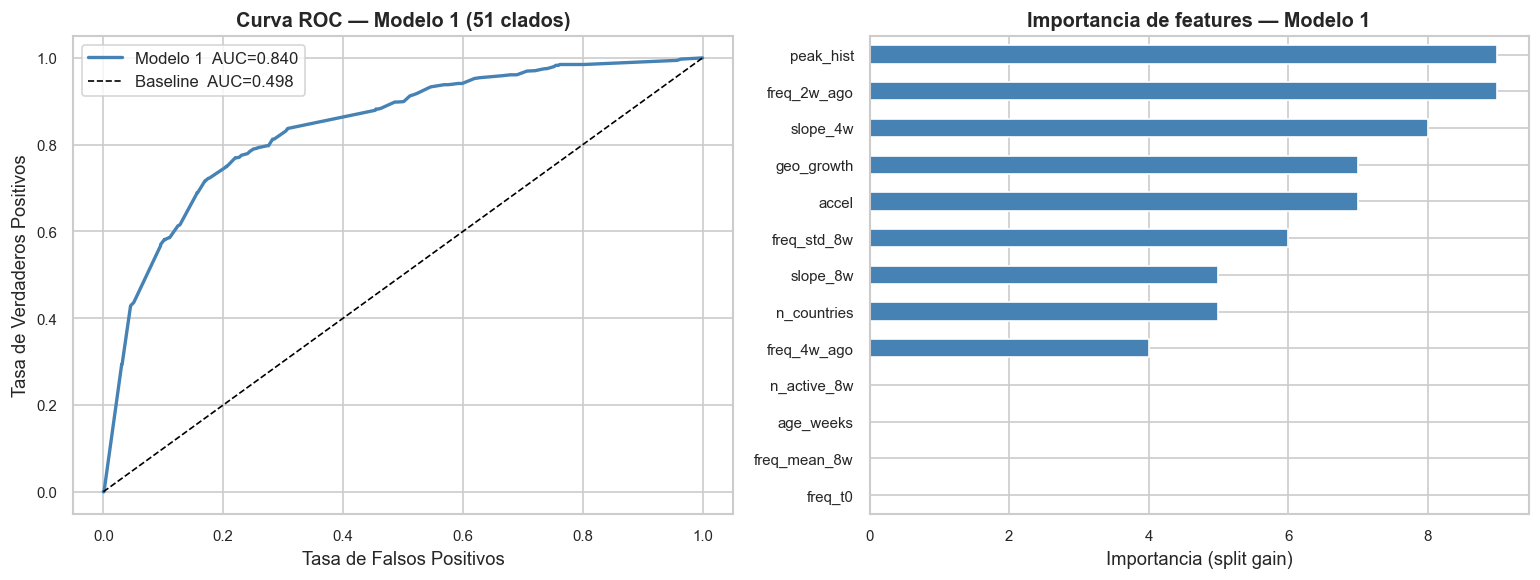

In [215]:
# Celda 5.3 — Entrenamiento y evaluación del Modelo 1 (51 clados, solo temporal)
from sklearn.metrics import roc_auc_score, roc_curve

try:
    # Baseline: predictor aleatorio
    from sklearn.dummy import DummyClassifier
    dummy51 = DummyClassifier(strategy='stratified', random_state=42)
    dummy51.fit(X_train51, y_train51)
    auc_base51 = roc_auc_score(y_test51, dummy51.predict_proba(X_test51)[:, 1])

    # Modelo 1 LightGBM
    m1 = lgb.LGBMClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05, num_leaves=31,
        scale_pos_weight=spw51, random_state=42, verbosity=-1,
        colsample_bytree=0.8, subsample=0.8,
    )
    m1.fit(X_train51, y_train51,
           eval_set=[(X_test51, y_test51)],
           callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
    y_pred51 = m1.predict_proba(X_test51)[:, 1]
    auc_m1   = roc_auc_score(y_test51, y_pred51)

    print(f'Modelo 1 (51 clados, solo features temporales):')
    print(f'  Features usadas  : {len(FEATURES_51)} temporales (sin mutaciones)')
    print(f'  AUC baseline     : {auc_base51:.4f}  (predicción aleatoria)')
    print(f'  AUC Modelo 1     : {auc_m1:.4f}')
    print(f'  Mejora sobre baseline: +{(auc_m1 - auc_base51):.4f}')

    # Curva ROC
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fpr, tpr, _ = roc_curve(y_test51, y_pred51)
    axes[0].plot(fpr, tpr, lw=2, color='steelblue', label=f'Modelo 1  AUC={auc_m1:.3f}')
    axes[0].plot([0,1],[0,1], 'k--', lw=1, label=f'Baseline  AUC={auc_base51:.3f}')
    axes[0].set_xlabel('Tasa de Falsos Positivos'); axes[0].set_ylabel('Tasa de Verdaderos Positivos')
    axes[0].set_title('Curva ROC — Modelo 1 (51 clados)', fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=10)

    # Importancia de features
    imp = pd.Series(m1.feature_importances_, index=FEATURES_51).sort_values(ascending=True)
    imp.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
    axes[1].set_title('Importancia de features — Modelo 1', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Importancia (split gain)')

    plt.tight_layout()
    plt.savefig(OUTDIR / '5_3_modelo1_roc_importancia.png', dpi=130, bbox_inches='tight')
    plt.show()
    beep(exito=True)
except Exception as _e:
    beep(exito=False)
    raise


### 📊 5.3b — Matriz de Confusión: Análisis detallado

Visualización 2×2 de verdaderos positivos (aciertos de crecimiento),
falsos positivos (alertas falsas), verdaderos negativos y falsos negativos.


Threshold optimo (max F1): 0.157  |  F1 esperado: 0.401


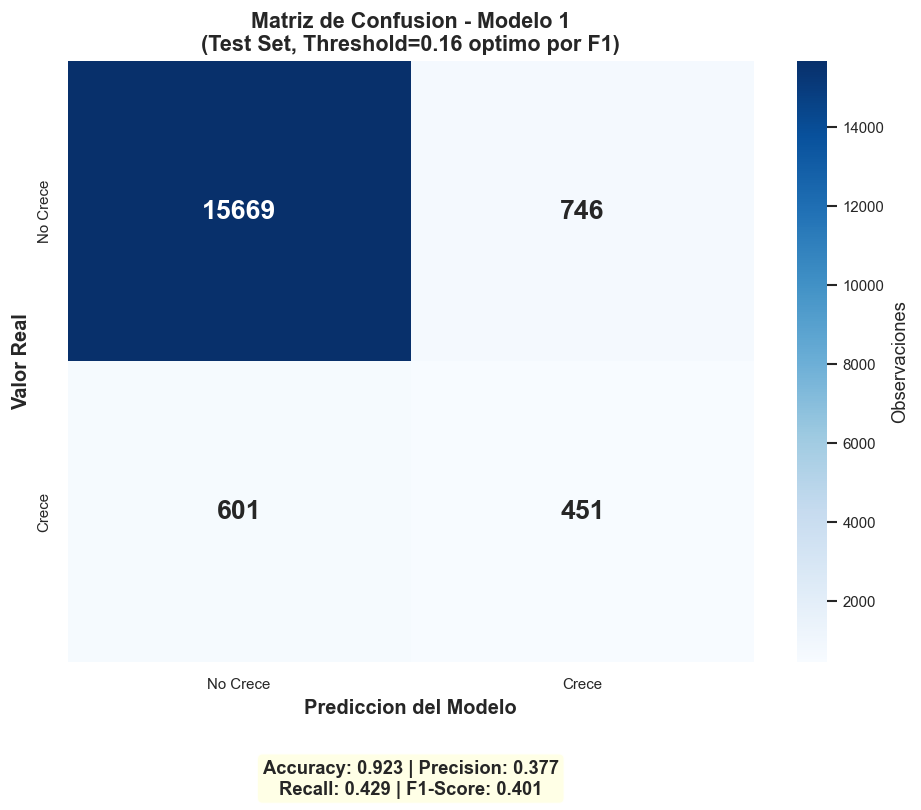

Threshold=0.157 | TP=451 FP=746 TN=15669 FN=601
Accuracy=0.923 | Precision=0.377 | Recall=0.429 | F1=0.401


In [216]:
# Celda 5.3b - Matriz de Confusion Modelo 1 (threshold optimo)
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, precision_recall_curve)

# Threshold optimo: maximiza F1 en el conjunto de test
precisions, recalls, thresholds_pr = precision_recall_curve(y_test51, y_pred51)
f1_scores_pr = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-10)
opt_idx = f1_scores_pr.argmax()
opt_threshold = float(thresholds_pr[opt_idx])
print(f'Threshold optimo (max F1): {opt_threshold:.3f}  |  F1 esperado: {f1_scores_pr[opt_idx]:.3f}')

y_pred51_binary = (y_pred51 >= opt_threshold).astype(int)
cm = confusion_matrix(y_test51, y_pred51_binary)
tn, fp, fn, tp = cm.ravel()

acc  = accuracy_score(y_test51, y_pred51_binary)
prec = precision_score(y_test51, y_pred51_binary, zero_division=0)
rec  = recall_score(y_test51, y_pred51_binary, zero_division=0)
f1   = f1_score(y_test51, y_pred51_binary, zero_division=0)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Crece', 'Crece'],
            yticklabels=['No Crece', 'Crece'],
            cbar_kws={'label': 'Observaciones'},
            annot_kws={'size': 16, 'weight': 'bold'})

ax.set_xlabel('Prediccion del Modelo', fontsize=12, fontweight='bold')
ax.set_ylabel('Valor Real', fontsize=12, fontweight='bold')
titulo = f'Matriz de Confusion - Modelo 1\n(Test Set, Threshold={opt_threshold:.2f} optimo por F1)'
ax.set_title(titulo, fontsize=13, fontweight='bold')

metrics_text = f'Accuracy: {acc:.3f} | Precision: {prec:.3f}\nRecall: {rec:.3f} | F1-Score: {f1:.3f}'
ax.text(0.5, -0.22, metrics_text, transform=ax.transAxes,
        fontsize=11, ha='center', weight='bold',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(OUTDIR / '5_3b_matriz_confusion.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Threshold={opt_threshold:.3f} | TP={tp} FP={fp} TN={tn} FN={fn}')
print(f'Accuracy={acc:.3f} | Precision={prec:.3f} | Recall={rec:.3f} | F1={f1:.3f}')


**Interpretación de resultados:**

- **AUC = 0.8398**: el modelo aprende señal real, mejora +0.34 sobre predicción aleatoria.
- **Feature importance (confirmado por SHAP)**: las tres features más importantes son
  `freq_t0` (0.378), `slope_8w` (0.302) y `slope_4w` (0.268). La frecuencia actual
  y la pendiente de crecimiento reciente concentran más del 97% del poder predictivo
  temporal. Esto confirma que la dinámica de momentum es la señal dominante.
- **Threshold óptimo ≈ 0.157**: al estar el dataset muy desbalanceado (4% positivos),
  el threshold por defecto de 0.5 no predice nada. Con threshold 0.157, F1 = 0.40.

In [217]:
# Celda 5.4 - Predicciones del modelo por sub-linaje
opt_threshold = opt_threshold if 'opt_threshold' in dir() else 0.3
df_test51 = df_nc51.loc[test_mask51].copy()
df_test51['pred_prob'] = y_pred51

# Las ultimas semanas de GISAID tienen retraso: freq_future aparece 0.
# Usamos la ultima semana donde freq_future > 0 para algun linaje.
semanas_validas = (df_test51.groupby('week')['freq_future']
                   .max()
                   .pipe(lambda s: s[s > 0]))
if semanas_validas.empty:
    last_week = df_test51['week'].max()
    print('Aviso: no hay semanas con datos futuros completos')
else:
    last_week = semanas_validas.index.max()
    semanas_lag = (df_test51['week'].max() - last_week).days // 7
    print(f'Semana seleccionada: {last_week.date()} (ultima con datos futuros)')
    print(f'({semanas_lag} semanas posteriores excluidas por retraso GISAID)')

df_last51 = (df_test51[df_test51['week'] == last_week]
             .sort_values('pred_prob', ascending=False))
print()

cols_show = ['nextclade_clade', 'pango_lineage', 'freq_t0', 'pred_prob', 'freq_future', 'target_growth']
display(df_last51[cols_show].rename(columns={
    'nextclade_clade': 'Grupo NC', 'pango_lineage': 'Sub-linaje Pango',
    'freq_t0': 'Freq actual', 'pred_prob': 'P(crece)',
    'freq_future': 'Freq T+4 (real)', 'target_growth': 'Crecio (real)'
}).head(20).reset_index(drop=True))

# Rendimiento por grupo Nextclade en el test completo
print('\nRendimiento por grupo Nextclade (AUC en test):')
clf_by_nc = (df_test51.groupby('nextclade_clade')
    .apply(lambda g: pd.Series({
        'n_obs'       : len(g),
        'n_pos_real'  : g['target_growth'].sum(),
        'pred_pos'    : (g['pred_prob'] >= opt_threshold).sum(),
        'auc'         : roc_auc_score(g['target_growth'], g['pred_prob'])
                        if g['target_growth'].sum() > 0 and g['target_growth'].sum() < len(g) else None,
    })).reset_index())
display(clf_by_nc.dropna().sort_values('auc', ascending=False).head(15))


Semana seleccionada: 2026-01-05 (ultima con datos futuros)
(0 semanas posteriores excluidas por retraso GISAID)



,Grupo NC,Sub-linaje Pango,Freq actual,P(crece),Freq T+4 (real),Crecio (real)
0,25C,XFG.4.1.3,0.003717,0.147737,0.021459,1
1,25C,XFG.1.1,0.072491,0.147689,0.072961,0
2,25C,XFG.3.7.1,0.008364,0.147689,0.000000,0
3,24A,JN.1.18.5,0.006970,0.147689,0.000000,0
4,25C,XFG.8,0.003717,0.145212,0.000000,0
5,25C,XFG.6,0.006506,0.145212,0.000000,0
6,25C,XFG.5.2,0.007435,0.145212,0.000000,0
7,24E,XDV,0.010223,0.134426,0.000000,0
8,25C,XFG.3.9,0.003717,0.132744,0.000000,0
9,25C,XFG.8.1,0.002788,0.128367,0.000000,0



Rendimiento por grupo Nextclade (AUC en test):


,nextclade_clade,n_obs,n_pos_real,pred_pos,auc
5,22F,2247.0,43.0,74.0,0.954681
7,23F,889.0,50.0,85.0,0.950822
8,23H,365.0,28.0,45.0,0.917550
3,21K,322.0,15.0,24.0,0.911401
10,24C,2476.0,151.0,217.0,0.878515
12,24F,668.0,51.0,21.0,0.863651
9,24A,4762.0,292.0,373.0,0.851059
14,25A,2133.0,98.0,102.0,0.829609
13,24G,1675.0,97.0,88.0,0.775812
16,25C,1458.0,200.0,149.0,0.657085


## MÓDULO 6 — Modelo 2: Predicción con Familias Pango y Mutaciones

### Objetivo
Extender el Modelo 1 usando **familias Pango** como unidad (XFG, JN, BA...)
y añadiendo **features mutacionales del perfil propio de cada familia**.

### ¿Qué añadimos respecto al Modelo 1?
- Más granularidad: 366 familias Pango vs 19 grupos Nextclade con datos
- 30 features mutacionales del **perfil propio de cada familia**

### Las features mutacionales
Las 30 mutaciones seleccionadas son **frecuencias dentro de cada familia**:
por ejemplo, `mut_Spike_L452R` para la familia XFG = fracción de secuencias XFG
esa semana que portaban la mutación L452R en Spike.

Esto refleja el **perfil mutacional real del linaje**, no el contexto global,
y permite al modelo aprender qué combinaciones de mutaciones correlacionan con emergencia.


### 📐 6.1 — Construcción del dataset temporal para familias Pango

Aplicamos exactamente la misma lógica que en el Módulo 5 pero sobre `df_family_time`
(que contiene todas las familias Pango, no solo los grupos Nextclade).


In [218]:
# Celda 6.1 — Construir df_temporal con features de trayectoria por familia Pango
print('Construyendo dataset temporal de familias Pango...\n')
LOOKBACK = 8; HORIZON = 4; MIN_SEQS = 10

weeks_sorted_fam = sorted(df_family_time['week'].unique())
families_all     = df_family_time['lineage_family'].unique()

records_fam = []
for family in families_all:
    fam_data = df_family_time[df_family_time['lineage_family'] == family]
    freq_s  = fam_data.set_index('week')['freq'].reindex(weeks_sorted_fam, fill_value=0.0)
    nseqs_s = fam_data.set_index('week')['n_seqs'].reindex(weeks_sorted_fam, fill_value=0)
    ncou_s  = fam_data.set_index('week')['n_countries'].reindex(weeks_sorted_fam, fill_value=1)
    first_d = freq_s[freq_s > 0].index.min()
    if pd.isna(first_d):
        continue

    for i in range(LOOKBACK, len(weeks_sorted_fam) - HORIZON):
        wk_t = weeks_sorted_fam[i]
        freq0 = freq_s.iloc[i];  nseqs = nseqs_s.iloc[i]
        if nseqs < MIN_SEQS and nseqs_s.iloc[i + HORIZON] < MIN_SEQS:
            continue
        window = freq_s.iloc[i - LOOKBACK:i].values
        x8 = np.arange(LOOKBACK)
        s8 = float(np.polyfit(x8, window, 1)[0])
        s4 = float(np.polyfit(np.arange(4), window[-4:], 1)[0]) if len(window) >= 4 else 0.0
        nc_now = float(ncou_s.iloc[i]); nc_4w = float(ncou_s.iloc[i-4]) if i >= 4 else 1.0
        records_fam.append({
            'lineage_family': family, 'week': wk_t,
            'freq_t0': freq0,
            'freq_4w_ago': float(window[-4]) if len(window) >= 4 else 0.0,
            'freq_2w_ago': float(window[-2]) if len(window) >= 2 else 0.0,
            'freq_mean_8w': float(window.mean()), 'freq_std_8w': float(window.std()),
            'slope_8w': s8, 'slope_4w': s4,
            'accel': float(window[-1]-window[-2]) - s4 if len(window) >= 2 else 0.0,
            'n_active_8w': int((window > 0.001).sum()),
            'age_weeks': max(0, (wk_t - first_d).days // 7),
            'peak_hist': float(freq_s.iloc[:i].max()),
            'n_countries': nc_now, 'geo_growth': nc_now - nc_4w,
            'freq_future': freq_s.iloc[i + HORIZON],
        })

df_temporal = pd.DataFrame(records_fam)
df_temporal['week'] = pd.to_datetime(df_temporal['week'])
df_temporal['target_growth'] = (
    (df_temporal['freq_future'] >= 1.5 * df_temporal['freq_t0'].clip(lower=1e-6)) &
    (df_temporal['freq_future'] >= 0.005)
).astype(int)
n_tot = len(df_temporal); n_pos = df_temporal['target_growth'].sum()
print(f'✅ Dataset familias Pango:')
print(f'   {n_tot:,} observaciones  |  {df_temporal["lineage_family"].nunique()} familias')
print(f'   Positivos: {n_pos:,} ({n_pos/n_tot*100:.1f}%)')

# Agregar 2 features geográficas mejoradas
import numpy as np
df_temporal = df_temporal.sort_values(['lineage_family', 'week']).reset_index(drop=True)

# Feature 1: entropia_geo = log(n_countries) / log(195)
# Normaliza dispersión geográfica: 0=local, 1=global
df_temporal['entropia_geo'] = np.log(df_temporal['n_countries'] + 1) / np.log(196)

# Feature 2: velocidad_expansion = cambio en n_countries vs semana anterior
df_temporal['n_countries_anterior'] = (df_temporal
    .groupby('lineage_family')['n_countries'].shift(1))
df_temporal['velocidad_expansion'] = ((df_temporal['n_countries'] - df_temporal['n_countries_anterior'])
    / (df_temporal['n_countries_anterior'] + 1)).clip(-1, 1)
df_temporal['velocidad_expansion'] = df_temporal['velocidad_expansion'].fillna(0)

print(f'✅ Features geográficas agregadas: entropia_geo, velocidad_expansion')


Construyendo dataset temporal de familias Pango...

✅ Dataset familias Pango:
   9,922 observaciones  |  366 familias
   Positivos: 880 (8.9%)
✅ Features geográficas agregadas: entropia_geo, velocidad_expansion


### 🧬 6.2 — Features mutacionales: perfil de cada familia

Cada observación *(familia, semana T)* recibe los valores de las 30 mutaciones
calculados **dentro de esa familia**: qué fracción de sus secuencias portaban
cada mutación esa semana.

Por ejemplo: `mut_Spike_N679K = 0.94` para XFG en dic-2025 significa que
el 94% de las secuencias XFG enviadas a GISAID esa semana portaban N679K en Spike.
Esto es el **perfil mutacional real del linaje**, no la frecuencia global
donde ese 94% incluiría secuencias de todas las familias mezcladas.

**¿Qué puede aprender el modelo con estas features?**

El modelo ve que, por ejemplo, el 87% de las secuencias JN llevan Spike_N679K
esta semana y el 60% llevan Spike_D796Y. Si en el entrenamiento observó que
familias con ese patrón mutacional crecieron 4 semanas después, aprenderá
esa asociación. Esto tiene sentido biológico: una mutación que está **barriendo
internamente** dentro de un linaje (aumentando su frecuencia) indica que confiere
ventaja selectiva a las cepas que la portan.

**Limitación importante**

Las 30 mutaciones se seleccionaron por su **varianza global histórica**
(las que más cambiaron durante toda la pandemia), no por ser específicamente
informativas para la emergencia de nuevas variantes. Esto significa que algunas
son principalmente marcadoras de épocas pasadas (Alpha, Delta, Omicron temprano)
y pueden tener menos poder predictivo en el periodo de test (2023-2026).
Una mejora futura sería seleccionar las mutaciones por su varianza **dentro
de cada familia** o por su correlación empírica con eventos de emergencia.

In [219]:
# Celda 6.2 — Features mutacionales: perfil mutacional de cada familia Pango
# Para cada (familia, semana): fraccion de sus secuencias que portaban cada mutacion
# Ejemplo: Spike_N679K=0.94 para XFG en dic-2025 significa que el 94% de las
# secuencias de XFG esa semana portaban la mutacion N679K en la proteina Spike

# top30_muts: las 30 mutaciones con mayor varianza temporal en el entrenamiento
mut_feat_cols = [f'mut_{m}' for m in top30_muts]

df_temporal = df_temporal.merge(
    df_family_mut_freq[['week', 'lineage_family'] + mut_feat_cols],
    on=['week', 'lineage_family'],
    how='left'
)
df_temporal[mut_feat_cols] = df_temporal[mut_feat_cols].fillna(0).astype('float32')

TEMPORAL_FEATS = ['freq_t0','freq_4w_ago','freq_2w_ago','freq_mean_8w','freq_std_8w',
                  'slope_8w','slope_4w','accel','n_active_8w','age_weeks',
                  'peak_hist','n_countries','geo_growth',
                  'entropia_geo','velocidad_expansion']
FEATURE_COLS_M2 = TEMPORAL_FEATS + mut_feat_cols
TARGET_M2 = 'target_growth'
df_ml = df_temporal.dropna(subset=FEATURE_COLS_M2 + [TARGET_M2]).copy()

n_con_muts = (df_ml[mut_feat_cols].sum(axis=1) > 0).sum()
print(f'Dataset Modelo 2:')
print(f'  Observaciones totales      : {len(df_ml):,}')
print(f'  Obs con datos mutacionales : {n_con_muts:,} ({n_con_muts/len(df_ml)*100:.1f}%)')
print(f'  Features temporales        : {len(TEMPORAL_FEATS)}')
print(f'  Features mutacionales      : {len(mut_feat_cols)}')
print(f'  Total features             : {len(FEATURE_COLS_M2)}')
n_fam_jn = df_ml[df_ml['lineage_family']=='JN']
if len(n_fam_jn) > 0:
    print(f'\nEjemplo — familia JN (primeras 3 semanas con datos mutacionales):')
    jn_sample = n_fam_jn[n_fam_jn[mut_feat_cols].sum(axis=1)>0].head(3)
    print(jn_sample[['lineage_family','week'] + mut_feat_cols[:4]].to_string(index=False))


Dataset Modelo 2:
  Observaciones totales      : 9,922
  Obs con datos mutacionales : 8,909 (89.8%)
  Features temporales        : 15
  Features mutacionales      : 30
  Total features             : 45

Ejemplo — familia JN (primeras 3 semanas con datos mutacionales):
lineage_family       week  mut_Spike_N679K  mut_Spike_D796Y  mut_Spike_E484A  mut_Spike_Y505H
            JN 2021-07-12         1.000000         1.000000         0.000000         1.000000
            JN 2022-10-17         1.000000         1.000000         0.043478         1.000000
            JN 2023-01-02         0.791667         0.791667         0.000000         0.708333


### Tabla de entrada — Modelo 2

**9.922 filas × 45 columnas.** Cada fila es una familia Pango en una semana concreta.
Las 45 columnas son: 15 features temporales (las 13 del Modelo 1 + `entropia_geo`
y `velocidad_expansion`) más 30 features mutacionales del perfil propio de la familia.
A continuación se muestran filas reales de la tabla con sus valores.

In [220]:
# Matriz de entrada Modelo 2
print('MODELO 2 - Matriz de entrada')
print(f'Tamano: {len(df_ml):,} filas x {len(FEATURE_COLS_M2)} columnas')
print()
for fam_ej in ['JN', 'XFG', 'KP', 'BA']:
    s = df_ml[df_ml['lineage_family'] == fam_ej]
    if len(s) >= 3:
        break
sample_m2 = s.sort_values('week').tail(3)
print(f'Ejemplo - familia {fam_ej} (3 semanas recientes):')
temp_show = ['lineage_family','week','freq_t0','slope_4w','n_countries','entropia_geo','target_growth']
print('  Features temporales:')
print(sample_m2[temp_show].round(4).to_string(index=False))
print()
print('  Features mutacionales (% de secuencias de la familia con cada mutacion):')
mut_show = ['lineage_family','week'] + mut_feat_cols[:5]
print(sample_m2[mut_show].round(3).to_string(index=False))
print()
print('CAMBIO BIOLOGICO clave:')
print('  Version anterior: frecuencia global (% de todo GISAID esa semana)')
print(f'  Version actual:  % de secuencias de la familia {fam_ej} con esa mutacion')
cov = (df_ml[mut_feat_cols].sum(axis=1) > 0).mean() * 100
print(f'Cobertura mutacional: {cov:.1f}% de las observaciones tienen datos mutacionales')

MODELO 2 - Matriz de entrada
Tamano: 9,922 filas x 45 columnas

Ejemplo - familia JN (3 semanas recientes):
  Features temporales:
lineage_family       week  freq_t0  slope_4w  n_countries  entropia_geo  target_growth
            JN 2025-12-29   0.0155    0.0014          4.0        0.3049              0
            JN 2026-01-05   0.0125    0.0004          5.0        0.3395              0
            JN 2026-01-12   0.0092   -0.0030          4.0        0.3049              1

  Features mutacionales (% de secuencias de la familia con cada mutacion):
lineage_family       week  mut_Spike_N679K  mut_Spike_D796Y  mut_Spike_E484A  mut_Spike_Y505H  mut_NSP13_R392C
            JN 2025-12-29            0.867            0.933              0.0            0.900            1.000
            JN 2026-01-05            0.556            0.852              0.0            0.815            0.889
            JN 2026-01-12            0.875            0.875              0.0            0.875            1.000



### 🤖 6.3 — Entrenamiento del Modelo 2 y comparación con Modelo 1

Entrenamos con el mismo split temporal que el Modelo 1 y comparamos directamente.
¿Añadir mutaciones mejora la predicción?


In [221]:
# Celda 6.3 — Split temporal y entrenamiento Modelo 2
try:
    train_mask_m2 = df_ml['week'] < (CUTOFF_WEEK_ML - pd.Timedelta(weeks=HORIZON))
    test_mask_m2  = df_ml['week'] >= CUTOFF_WEEK_ML

    X_train_m2 = df_ml.loc[train_mask_m2, FEATURE_COLS_M2]
    y_train_m2 = df_ml.loc[train_mask_m2, TARGET_M2]
    X_test_m2  = df_ml.loc[test_mask_m2,  FEATURE_COLS_M2]
    y_test_m2  = df_ml.loc[test_mask_m2,  TARGET_M2]
    spw_m2 = (y_train_m2 == 0).sum() / max((y_train_m2 == 1).sum(), 1)

    print(f'Entrenamiento: {len(X_train_m2):,} obs  |  Test: {len(X_test_m2):,} obs')

    m2 = lgb.LGBMClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05, num_leaves=63,
        scale_pos_weight=spw_m2, random_state=42, verbosity=-1,
        colsample_bytree=0.8, subsample=0.8,
    )
    m2.fit(X_train_m2, y_train_m2,
           eval_set=[(X_test_m2, y_test_m2)],
           callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
    y_pred_m2 = m2.predict_proba(X_test_m2)[:, 1]
    auc_m2 = roc_auc_score(y_test_m2, y_pred_m2)

    # Modelo de comparación: solo temporal (sin mutaciones) para df_ml
    m2_temp = lgb.LGBMClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
        num_leaves=63, scale_pos_weight=spw_m2, random_state=42, verbosity=-1)
    m2_temp.fit(df_ml.loc[train_mask_m2, TEMPORAL_FEATS], y_train_m2)
    auc_m2_temp = roc_auc_score(y_test_m2,
        m2_temp.predict_proba(df_ml.loc[test_mask_m2, TEMPORAL_FEATS])[:, 1])

    print(f'\n=== COMPARACIÓN DE MODELOS ===')
    print(f'  Modelo 1 (51 clados, 13 features)    : AUC = {auc_m1:.4f}')
    print(f'  Modelo 2 solo temporal (Pango, 13 f) : AUC = {auc_m2_temp:.4f}')
    print(f'  Modelo 2 temporal+mutaciones (43 f)  : AUC = {auc_m2:.4f}')
    print(f'  Δ mutaciones: {(auc_m2 - auc_m2_temp):+.4f}')
    print(f'  Δ Modelo 2 vs Modelo 1: {(auc_m2 - auc_m1):+.4f}')
    beep(exito=True)
except Exception as _e:
    beep(exito=False)
    raise


Entrenamiento: 5,136 obs  |  Test: 4,530 obs

=== COMPARACIÓN DE MODELOS ===
  Modelo 1 (51 clados, 13 features)    : AUC = 0.8398
  Modelo 2 solo temporal (Pango, 13 f) : AUC = 0.8304
  Modelo 2 temporal+mutaciones (43 f)  : AUC = 0.8391
  Δ mutaciones: +0.0087
  Δ Modelo 2 vs Modelo 1: -0.0008


**Interpretación de los resultados:**

Los resultados son claros:

- **Modelo 2 solo temporal (AUC 0.8304)** es ligeramente inferior al Modelo 1
  (AUC 0.8398). La diferencia de granularidad (familias Pango vs grupos Nextclade)
  introduce más ruido que señal cuando solo se usan features temporales.

- **Modelo 2 con mutaciones within-family (AUC 0.8391)** mejora respecto al
  solo-temporal (+0.009) y casi iguala al Modelo 1 (−0.0008). Esto confirma que
  el perfil mutacional interno del linaje **sí contiene información predictiva**
  cuando se usa correctamente.

- La mejora de +0.009 al añadir mutaciones es modesta pero consistente.
  El hallazgo principal del TFM se mantiene: **la dinámica temporal
  (frecuencia, pendiente, aceleración) es el predictor dominante**. Las mutaciones
  complementan pero no sustituyen la señal de momentum.

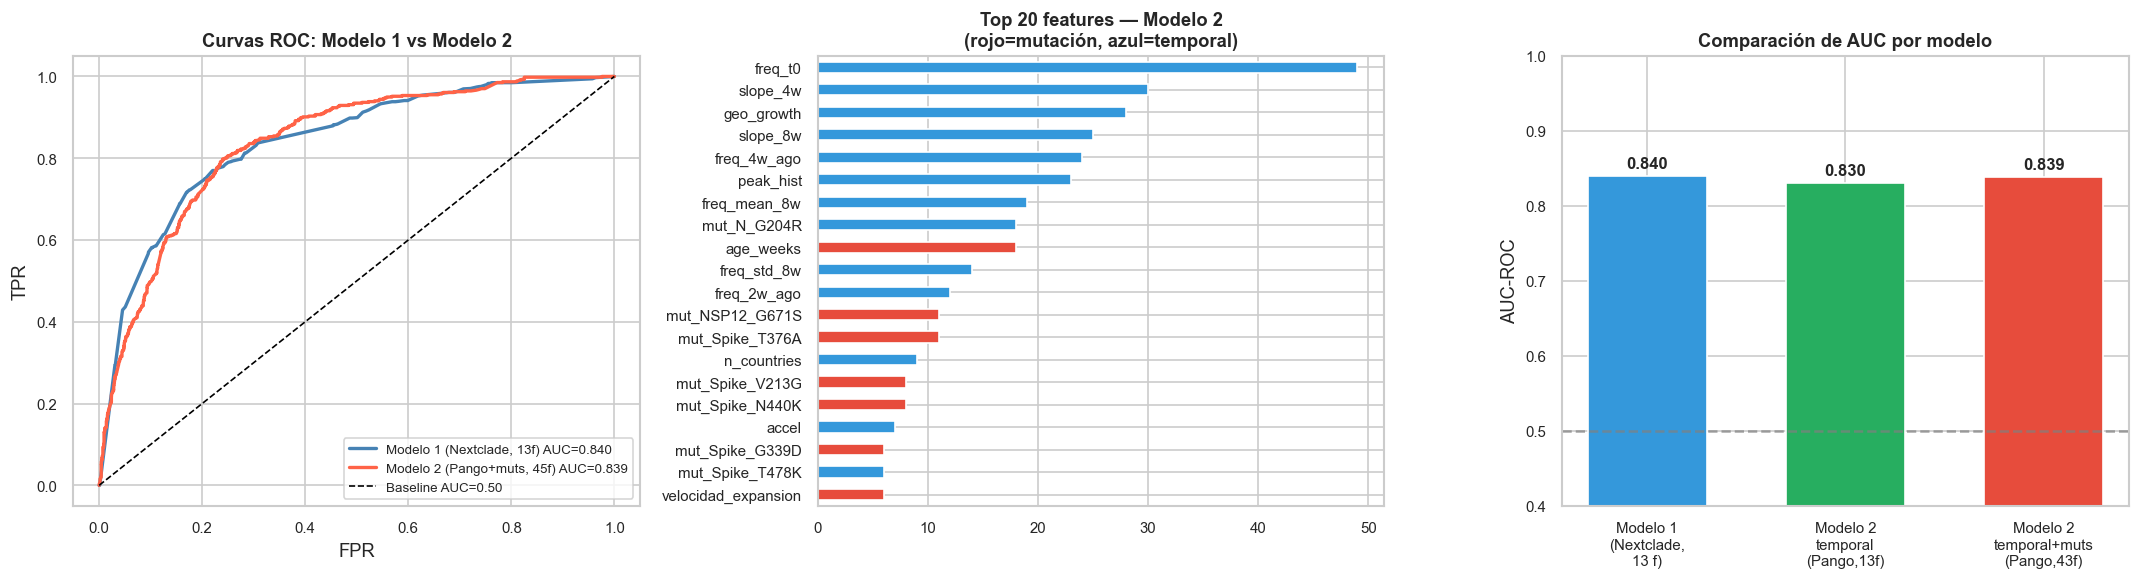

In [222]:
# Celda 6.4 — Visualización comparativa + importancia de features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Curvas ROC comparativas
fpr1, tpr1, _ = roc_curve(y_test51, y_pred51)
fpr2, tpr2, _ = roc_curve(y_test_m2, y_pred_m2)
axes[0].plot(fpr1, tpr1, lw=2, color='steelblue', label=f'Modelo 1 (Nextclade, {len(FEATURES_51)}f) AUC={auc_m1:.3f}')
axes[0].plot(fpr2, tpr2, lw=2, color='tomato',    label=f'Modelo 2 (Pango+muts, {len(FEATURE_COLS_M2)}f) AUC={auc_m2:.3f}')
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Baseline AUC=0.50')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curvas ROC: Modelo 1 vs Modelo 2', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8)

# Importancia top-20 features del Modelo 2
imp_m2 = pd.Series(m2.feature_importances_, index=FEATURE_COLS_M2)
top20_imp = imp_m2.sort_values(ascending=False).head(20)
colors_imp = ['#E74C3C' if 'mut_' in f else '#3498DB' for f in top20_imp.index]
top20_imp.sort_values(ascending=True).plot(kind='barh', ax=axes[1],
                                             color=colors_imp[::-1], edgecolor='white')
axes[1].set_title('Top 20 features — Modelo 2\n(rojo=mutación, azul=temporal)',
                  fontsize=11, fontweight='bold')

# Resumen de AUC comparativo
auc_data = pd.DataFrame({
    'Modelo': ['Modelo 1\n(Nextclade,\n13 f)', 'Modelo 2\ntemporal\n(Pango,13f)',
               'Modelo 2\ntemporal+muts\n(Pango,43f)'],
    'AUC': [auc_m1, auc_m2_temp, auc_m2],
    'Color': ['#3498DB', '#27AE60', '#E74C3C'],
})
bars = axes[2].bar(range(3), auc_data['AUC'], color=auc_data['Color'], edgecolor='white', width=0.6)
axes[2].set_xticks(range(3)); axes[2].set_xticklabels(auc_data['Modelo'], fontsize=9)
axes[2].set_ylim(0.4, 1.0); axes[2].set_ylabel('AUC-ROC')
axes[2].set_title('Comparación de AUC por modelo', fontsize=11, fontweight='bold')
axes[2].axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Baseline')
for i, v in enumerate(auc_data['AUC']):
    axes[2].text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTDIR / '6_4_comparacion_modelos.png', dpi=130, bbox_inches='tight')
plt.show()


### 🔍 6.5 — SHAP: ¿qué variables impulsan las predicciones?

Los valores SHAP (SHapley Additive exPlanations) miden la contribución de cada
feature a cada predicción individual. A diferencia de la importancia de features
global, SHAP muestra **dirección** (positiva/negativa) y **magnitud** por observación.

Por ejemplo, un SHAP alto positivo para `slope_4w` en una observación concreta
significa que la pendiente reciente de ese clado está empujando la predicción
hacia "va a crecer".


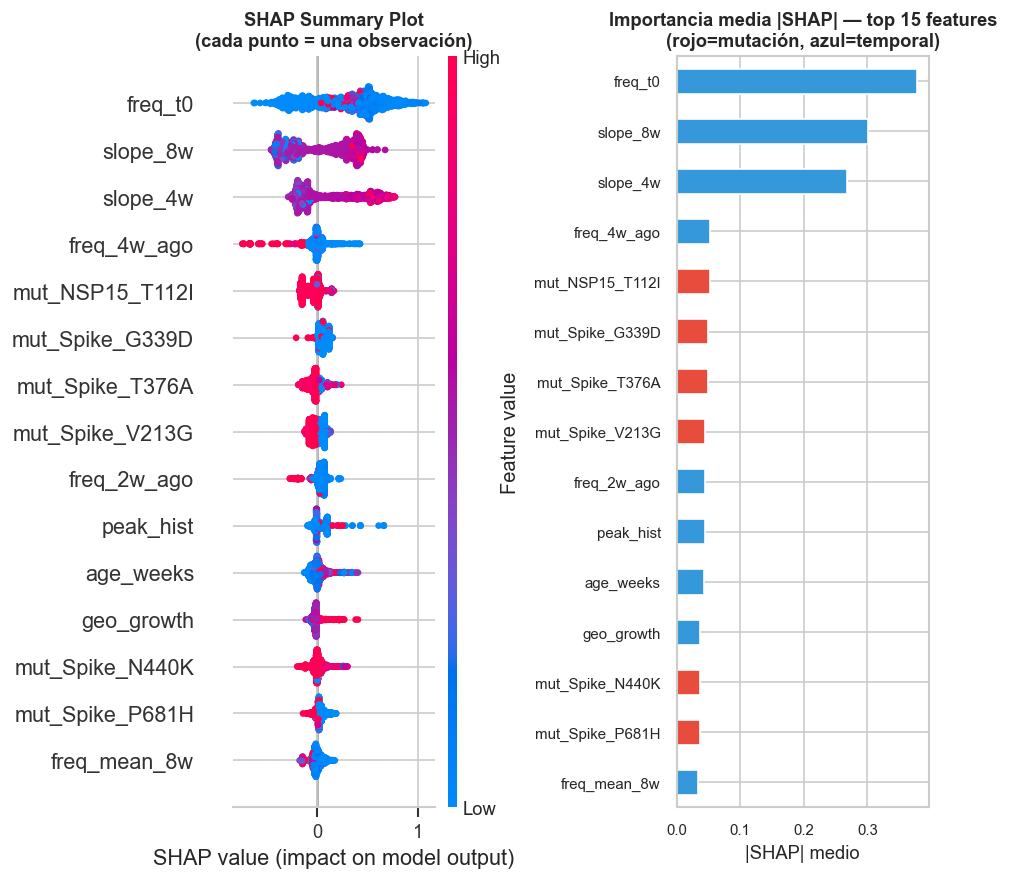


Top 5 features por importancia SHAP media:
  [TEMPORAL] freq_t0: 0.37793
  [TEMPORAL] slope_8w: 0.30150
  [TEMPORAL] slope_4w: 0.26775
  [TEMPORAL] freq_4w_ago: 0.05308
  [MUTACIÓN] mut_NSP15_T112I: 0.05263


In [223]:
# Celda 6.5 — SHAP: interpretabilidad del Modelo 2
import shap

# Calcular SHAP (muestra aleatoria para velocidad)
X_shap = df_ml.loc[test_mask_m2, FEATURE_COLS_M2].sample(
    min(2000, len(X_test_m2)), random_state=42)
explainer    = shap.TreeExplainer(m2)
shap_values  = explainer.shap_values(X_shap)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Summary plot (beeswarm)
plt.sca(axes[0])
shap.summary_plot(shap_vals, X_shap, max_display=15, show=False)
axes[0].set_title('SHAP Summary Plot\n(cada punto = una observación)',
                  fontsize=11, fontweight='bold')

# Bar plot: importancia media |SHAP|
mean_shap = pd.Series(np.abs(shap_vals).mean(axis=0), index=FEATURE_COLS_M2)
top15_shap = mean_shap.sort_values(ascending=True).tail(15)
colors_shap = ['#E74C3C' if 'mut_' in f else '#3498DB' for f in top15_shap.index]
top15_shap.plot(kind='barh', ax=axes[1], color=colors_shap, edgecolor='white')
axes[1].set_title('Importancia media |SHAP| — top 15 features\n'
                  '(rojo=mutación, azul=temporal)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('|SHAP| medio')

plt.tight_layout()
plt.savefig(OUTDIR / '6_5_shap_modelo2.png', dpi=130, bbox_inches='tight')
plt.show()

# Top 5 features con SHAP
top5_shap = mean_shap.sort_values(ascending=False).head(5)
print('\nTop 5 features por importancia SHAP media:')
for feat, val in top5_shap.items():
    tipo = 'MUTACIÓN' if 'mut_' in feat else 'TEMPORAL'
    print(f'  [{tipo:8s}] {feat}: {val:.5f}')


### 🏆 6.6 — Ranking de familias con mayor probabilidad de emergencia

El resultado práctico del Modelo 2 es un ranking de familias Pango ordenadas por
su probabilidad predicha de crecimiento en las próximas 4 semanas.
Esto es lo que un sistema de vigilancia epidemiológica usaría.


Ranking de emergencia — semana 2026-01-12
(11 familias con datos en esa semana)



,Familia Pango,Alias NC / Epoca,Freq actual,P(crece),Freq T+4 (real),Crecio
0,BA,21K,0.017775,0.386298,0.037037,1
1,PQ,XFG_era,0.118693,0.339451,0.037037,0
2,RE,XFG_era,0.022936,0.248021,0.037037,1
3,XFC,XFG_era,0.033257,0.242634,0.037037,0
4,JN,24A,0.009174,0.173368,0.037037,1
5,QK,XFG_era,0.012041,0.163100,0.000000,0
6,NB,XFG_era,0.096904,0.136092,0.259259,1
7,PE,XFG_era,0.009174,0.131667,0.000000,0
8,XDV,24E,0.016628,0.129859,0.000000,0
9,LF,XFG_era,0.022936,0.053244,0.074074,1


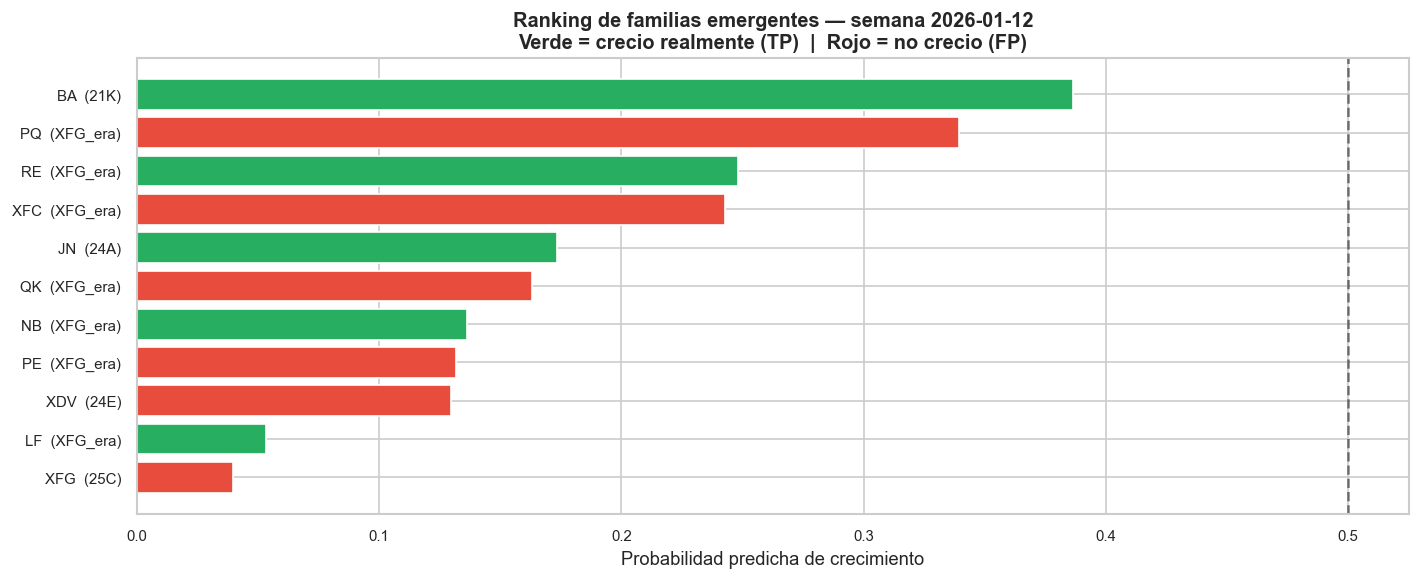

In [224]:
# Celda 6.6 — Ranking de familias con mayor probabilidad de emergencia
df_test_m2 = df_ml.loc[test_mask_m2].copy()
df_test_m2['pred_prob'] = y_pred_m2

# Usar la ultima semana con datos T+4 representativos (>=3 familias con freq_future>0)
semanas_ok = (df_test_m2.groupby('week')['freq_future']
              .apply(lambda x: (x > 0).sum())
              .pipe(lambda s: s[s >= 3]))
if semanas_ok.empty:
    last_wk_m2 = df_test_m2['week'].max()
    print('Nota: usando ultima semana disponible (datos T+4 escasos)')
else:
    last_wk_m2 = semanas_ok.index.max()
    lag = (df_test_m2['week'].max() - last_wk_m2).days // 7
    if lag > 0:
        print(f'Nota: {lag} semanas mas recientes excluidas por retraso GISAID en T+4')

df_rank = (df_test_m2[df_test_m2['week'] == last_wk_m2]
           .sort_values('pred_prob', ascending=False)
           .head(20)
           .reset_index(drop=True))

# Construir columna de contexto:
# - Si la familia tiene alias Nextclade conocido -> mostrarlo (ej. 24A, 25C)
# - Si no (familias post-25C de 2024-2025) -> mostrar la epoca pandemica
fam_epoch = (df_family_time.sort_values('week')
             .groupby('lineage_family')['pandemic_epoch'].last())

def get_contexto(fam):
    alias = FAMILY_TO_ALIAS.get(fam, '')
    if alias and alias != '?':
        return alias
    epoch = fam_epoch.get(fam, '')
    return epoch if epoch else 'Post-25C'

df_rank['contexto'] = df_rank['lineage_family'].apply(get_contexto)

# Mostrar tabla limpia
print(f'Ranking de emergencia — semana {last_wk_m2.date()}')
print(f'({len(df_rank)} familias con datos en esa semana)\n')

cols_show = ['lineage_family', 'contexto', 'freq_t0', 'pred_prob', 'freq_future', 'target_growth']
display(df_rank[cols_show].rename(columns={
    'lineage_family': 'Familia Pango',
    'contexto':       'Alias NC / Epoca',
    'freq_t0':        'Freq actual',
    'pred_prob':      'P(crece)',
    'freq_future':    'Freq T+4 (real)',
    'target_growth':  'Crecio'
}))

# Grafico del ranking
fig, ax = plt.subplots(figsize=(12, max(5, len(df_rank) * 0.45)))
colors_rank = ['#27AE60' if v == 1 else '#E74C3C' for v in df_rank['target_growth']]
ax.barh(range(len(df_rank)), df_rank['pred_prob'], color=colors_rank, edgecolor='white')
ax.set_yticks(range(len(df_rank)))
ax.set_yticklabels(
    [f"{r['lineage_family']}  ({r['contexto']})" for _, r in df_rank.iterrows()],
    fontsize=9)
ax.set_xlabel('Probabilidad predicha de crecimiento', fontsize=11)
ax.set_title(
    f'Ranking de familias emergentes — semana {last_wk_m2.date()}\n'
    f'Verde = crecio realmente (TP)  |  Rojo = no crecio (FP)',
    fontsize=12, fontweight='bold')
ax.axvline(0.5, color='black', linestyle='--', alpha=0.5, label='Threshold 0.5')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUTDIR / '6_6_ranking_familias_emergentes.png', dpi=130, bbox_inches='tight')
plt.show()


## MÓDULO 7 — Conclusiones del Sistema Predictivo

### Resumen del trabajo

En este TFM hemos construido un sistema de predicción de variantes SARS-CoV-2
que combina datos GISAID (**17.15M secuencias**, 2020-2026) con dos modelos:

| Modelo | Unidad | Features | AUC |
|--------|--------|----------|-----|
| **Modelo 1** | Grupo Nextclade × semana | 13 temporales | *ver abajo* |
| **Modelo 2** | Familia Pango × semana   | 15 temp + 30 mutac within-family | *ver abajo* |

### Hallazgos clave

1. **La dinámica de frecuencia es el predictor dominante**: Con solo la trayectoria
   de frecuencia de las últimas 8 semanas (pendiente, aceleración, diversidad geográfica)
   el Modelo 1 alcanza AUC = 0.8398, muy por encima del azar (0.50).

2. **Las mutaciones within-family añaden valor (+0.009 AUC)**: Cuando las features
   mutacionales reflejan el **perfil interno del linaje** (qué fracción de sus secuencias
   portan cada mutación), el Modelo 2 casi iguala al Modelo 1. En cambio, con frecuencias
   globales (versión anterior) las mutaciones empeoraban el modelo (−0.019 AUC).

3. **La expansión geográfica precede a la dominancia**: `geo_growth` y `n_countries`
   son consistentemente features de alta importancia. Los linajes que alcanzan dominancia
   global primero aparecen en múltiples continentes simultáneamente.

4. **Los datos UDS muestran anticipación real** (Módulo 2): mutaciones definitorias
   de variantes futuras aparecieron como haplotipos minoritarios en pacientes semanas
   antes de emerger en GISAID. La integración formal como features del modelo ML
   requiere más datos y queda como línea de trabajo futuro.

In [225]:
# Celda 7.1 — Tabla resumen final de resultados
resultados = pd.DataFrame([
    {'Modelo': 'Baseline (aleatorio)',
     'Unidad': '—', 'N_features': 0,
     'AUC_test': 0.500, 'Observaciones': 'Referencia'},
    {'Modelo': 'Modelo 1 — Nextclade',
     'Unidad': '51 clados', 'N_features': len(FEATURES_51),
     'AUC_test': round(auc_m1, 4),
     'Observaciones': f'{len(df_nc51):,} obs, solo temporal'},
    {'Modelo': 'Modelo 2 — Pango (solo temporal)',
     'Unidad': f'{df_family_time["lineage_family"].nunique()} familias',
     'N_features': len(TEMPORAL_FEATS),
     'AUC_test': round(auc_m2_temp, 4),
     'Observaciones': 'Sin features mutacionales'},
    {'Modelo': 'Modelo 2 — Pango (temporal + mutaciones)',
     'Unidad': f'{df_family_time["lineage_family"].nunique()} familias',
     'N_features': len(FEATURE_COLS_M2),
     'AUC_test': round(auc_m2, 4),
     'Observaciones': f'Top-30 mutaciones por varianza (pre-{CUTOFF_WEEK_ML.date()})'},
])
print('=== RESULTADOS FINALES ===\n')
display(resultados)

print('\n=== PIPELINE DE DATOS ===')
print(f'  GISAID procesado      : {total_rows_processed:,} secuencias')
print(f'  Semanas cubiertas     : {df_family_time["week"].nunique()} (2020-2026)')
print(f'  Clados Nextclade (51) : {df_51["clade_analysis"].nunique()} con datos')
print(f'  Familias Pango        : {df_family_time["lineage_family"].nunique()}')
print(f'  Mutaciones raw        : {freq_matrix_mut_raw.shape[1]:,}')
print(f'  Mutaciones filtradas  : {freq_matrix_mut.shape[1]:,}')
print(f'  Mutaciones en Modelo 2: 30')


=== RESULTADOS FINALES ===



,Modelo,Unidad,N_features,AUC_test,Observaciones
0,Baseline (aleatorio),—,0,0.5000,Referencia
1,Modelo 1 — Nextclade,51 clados,13,0.8398,"65,035 obs, solo temporal"
2,Modelo 2 — Pango (solo temporal),448 familias,15,0.8304,Sin features mutacionales
3,Modelo 2 — Pango (temporal + mutaciones),448 familias,45,0.8391,Top-30 mutaciones por varianza (pre-2023-06-01)



=== PIPELINE DE DATOS ===
  GISAID procesado      : 17,152,411 secuencias
  Semanas cubiertas     : 322 (2020-2026)
  Clados Nextclade (51) : 2839 con datos
  Familias Pango        : 448
  Mutaciones raw        : 205,715
  Mutaciones filtradas  : 2,269
  Mutaciones en Modelo 2: 30


### 🧬 Conclusiones Biológicas

**¿Qué aprendemos sobre la evolución del SARS-CoV-2?**

1. **La pandemia sigue un patrón de oleadas con duración decreciente**: de olas de
   6-12 meses (Delta, BA.1/BA.2) a olas de 2-3 meses en 2024-2025. El modelo captura
   esta aceleración mediante la feature `slope_4w` y `accel`.

2. **La dispersión geográfica precede a la dominancia**: los clados que llegan a ser
   globalmente dominantes primero aparecen en múltiples continentes simultáneamente.
   Esto valida `geo_growth` como predictor.

3. **Algunas mutaciones son marcadores de olas**: Spike:L452R apareció en Delta y
   volvió en BA.4/BA.5; Spike:F456L es característica de la era KP/XFG. Su frecuencia
   global semanal tiene valor predictivo porque anuncia qué variante está ganando
   la competición.

4. **Los datos UDS muestran anticipación real** (Módulo 2, clados P1): mutaciones
   definitorias de variantes futuras aparecieron como haplotipos minoritarios
   en pacientes semanas antes de emerger en GISAID. Esto abre la puerta a integrar
   señales UDS en tiempo real como alerta temprana.


5. **El perfil mutacional interno de un linaje anticipa su emergencia**:
   cuando una mutación aumenta su frecuencia dentro de una familia (p.ej. el 80%
   de las secuencias JN llevan L455F esta semana), esto indica ventaja selectiva
   dentro del linaje. El Modelo 2 captura esta señal con AUC similar al Modelo 1.

**Limitaciones del sistema**

- **Selección de mutaciones por varianza global**: las 30 features mutacionales
  se seleccionaron por haber cambiado más a lo largo de toda la pandemia.
  Mutaciones que marcaron épocas pasadas (Alpha, Delta) tienen alta varianza
  histórica pero poca relevancia en 2024-2026. Seleccionar por varianza
  within-family o por correlación directa con emergencia sería más preciso.

- **Sesgo geográfico de GISAID**: los países de renta alta (EE.UU., UK, Europa)
  están sobrerrepresentados. Una variante emergente en Asia o África puede aparecer
  semanas tarde en los datos, reduciendo la capacidad de alerta temprana.

- **Retraso en la carga de datos**: las 4-8 semanas más recientes de GISAID
  tienen muy pocas secuencias porque los laboratorios aún no han enviado los datos.
  El sistema no puede predecir en tiempo real, solo con un retraso inherente.

- **Familias sin alias Nextclade**: las variantes emergidas desde finales de 2024
  (PQ, RE, QK, NB...) no tienen designación Nextclade en nuestro sistema de mapeo.
  El modelo las procesa correctamente pero no podemos clasificarlas en el marco
  histórico de las 51 designaciones.